<a href="https://colab.research.google.com/github/TomazDrumond/MYREPO/blob/main/LoanTape_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Valor - Contexto e dados

## Breve resumo

**O que é uma Loan Tape?**

Uma loan tape é um dataset estruturado com informações detalhadas de cada empréstimo de um portfólio. Os dados são organizados em categorias que cobrem informações do tomador, histórico de pagamentos e garantias — com uma linha por operação.
Os campos se dividem em dois tipos: características do recebível (ID do cliente, datas de início e fim do pagamento, saldo devedor, prazo restante) e características do tomador (cohort, localização geográfica, score de crédito, setor de atuação, limite de crédito). Na prática, é o "raio-X" da carteira — o documento central de qualquer processo de análise, captação de dívida ou monitoramento de investimento em crédito.

**Para que serve e quem usa?**

A tape permite que underwriters, agências de rating, trustees e firmas de diligência analisem o colateral para determinar níveis de risco, pricing adequado e estrutura do deal.
Depois que o deal fecha, o uso muda:
A tape é atualizada mensalmente ou trimestralmente para dar transparência contínua aos investidores sobre performance da carteira ao longo do tempo, à medida que os empréstimos são pagos, entram em default ou têm outros eventos.

**Como se estrutura? (campos principais)**

Não existe um formato padrão, mas as tapes geralmente contêm um conjunto mínimo de dados por empréstimo, extraídos de múltiplos sistemas internos: o LOS (sistema de originação), o sistema de administração de crédito, sistemas de risco e o ledger contábil.
Os campos típicos são:

1. Originação: data, valor principal, taxa de juros, prazo
2. Status atual: saldo devedor, dias em atraso (DPD), status de adimplência
3. Tomador: score de crédito, localização, setor, renda/financeiros
4. Garantia (quando aplicável): tipo, valor, LTV
5. Perdas: para empréstimos liquidados — data de default, valor da perda, recuperações


**O coração da análise: Vintage Analysis**

Essa é a ferramenta analítica central para quem quer entender a qualidade do underwriting e a performance da carteira ao longo do tempo.
O termo "vintage" refere-se ao mês ou trimestre em que a conta foi aberta. A vintage analysis mede a performance de um portfólio em diferentes períodos após a concessão do crédito — cumulative charge-off rate, proporção de clientes com 30/60/90 DPD, utilization ratio, saldo médio, entre outros.
As vintage curves têm o eixo X representando a idade do empréstimo (geralmente em meses desde a originação) e o eixo Y uma métrica de performance. Cada linha representa um vintage diferente — o que permite comparar como cada cohort se comporta à medida que envelhece.
Por que isso é poderoso:
Métricas gerais de portfólio podem ser enganosas porque não distinguem entre o efeito de seasoning de ativos antigos e a trajetória de ativos novos, potencialmente mais arriscados. A vintage analysis trata cada cohort como uma entidade de risco distinta.
Um vintage que inicialmente mostrava yield forte mas depois sofreu queda significativa pode indicar alto prepagamento ou defaults corroendo a rentabilidade — o que só fica visível quando você segmenta por período de originação.

**Roll Rate: o indicador de alerta precoce**

Roll rate analysis examina a probabilidade de que uma conta se mova de um bucket de inadimplência para o próximo em um período de tempo — tipicamente mensal. Para cada bucket (Current, 1–30 DPD, 31–60 DPD, 61–90 DPD, 90+ DPD), calcula-se a proporção de contas que avança, cura ou permanece estável.
Um vintage com roll rate consistente de 40% de 60 DPD para 90 DPD vai registrar perdas cumulativas maiores do que um vintage com apenas 25% — e esse sinal aparece semanas antes das perdas se materializarem nos demonstrativos.
A lógica prática: vintage analysis é o motor para previsão de longo prazo (lifetime PD), enquanto roll rate é o motor para previsão de curto prazo e detecção de deterioração imediata.

**Monitoramento contínuo — o que os fundos fazem na prática**

Uma vez que o deal fecha, é preciso monitorar duas dimensões: a performance operacional da empresa e a performance subjacente da carteira. Mensalmente, os fundos recebem a loan tape e fazem análise de cohort (como cohorts individuais performam por mês de originação) e static pool analysis (visão geral — total de recebíveis, % delinquente, etc.).
Além da análise quantitativa, é boa prática fazer spot-checks: cada tape recebida, reconciliar os adiantamentos com extratos bancários para confirmar que o que está na planilha realmente aconteceu.

**O risco operacional das Fintechs**

Processamento diário de loan tapes é a fundação do gerenciamento contínuo de portfólio em crédito privado. Quando a operação escala, gerenciar dados em nível de loan e cohort fica exponencialmente mais complexo, frequentemente gerando discrepâncias difíceis de reconciliar.
Fintechs precisam produzir tapes regularmente — geralmente diariamente — para draw requests e reportes de compliance para os provedores de capital. Isso exige pipelines de dados bem estruturados desde o início, com engenharia envolvida.

**O risco real:** se a carteira cresce mais rápido do que a infraestrutura de dados, os covenants não são monitorados adequadamente, o provedor de capital perde visibilidade e o custo de funding sobe — ou o capital seca.



## Análise exploratporia dos dados

### Biblioteca necessária

In [1]:
# Baixando pacotes

!apt-get install git-lfs
!git lfs install

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 2s (2,182 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.


In [64]:
# Pacotes necessários para a tarefa

# 1. Utilitários do Sistema e Avisos
import os
import warnings

# 2. Manipulação de Dados e Datas
from datetime import date
import pandas as pd

# 3. Computação Numérica e Álgebra Linear
import numpy as np
from numpy.linalg import matrix_power

# 4. Estatística e Matemática
from scipy import stats
from scipy.stats import poisson

# 5. Machine Learning (Scikit-Learn)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 6. Visualização de Dados (Matplotlib)
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [65]:
# ============================================================
# Case Valor 2.0 — Shared Chart Style
# Palette extracted from modelo.pdf (Valor Capital Group deck identity)
# Calibrated with credit committee: no gridlines, black axes, navy/blue palette
# ============================================================
from matplotlib.colors import LinearSegmentedColormap

PALETTE = {
    "navy_dark":  "#0F2941",   # primary series / titles
    "navy_mid":   "#364973",   # secondary series / subtitles
    "blue_light": "#8DA0CA",   # tertiary series
    "axis_black": "#000000",   # axis lines, ticks, tick labels
    "alert_red":  "#C0504D",   # negative / critical
    "warn_amber": "#EF9F27",   # caution / median markers
    "good_green": "#1D9E75",   # positive / favorable
    "muted_grey": "#888780",   # de-emphasized background series
}

# Sequential navy colormap for heatmaps/gradients (replaces plasma/RdYlGn)
HOUSE_CMAP = LinearSegmentedColormap.from_list(
    "house_navy", ["#FFFFFF", PALETTE["blue_light"], PALETTE["navy_dark"]]
)

def apply_house_style():
    """Call once per session to set global fonts/background."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri", "Segoe UI", "Arial", "DejaVu Sans"],
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })

def style_axes(ax):
    """House axis treatment: no gridlines, black ticks/spines, open top/right."""
    ax.grid(False)
    ax.tick_params(axis='both', colors=PALETTE["axis_black"], labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(PALETTE["axis_black"])
    ax.spines['bottom'].set_color(PALETTE["axis_black"])

def add_title_block(ax, title, subtitle=None, fontsize_title=13, pad=30):
    """Single-panel title: bold navy title + italic navy-mid subtitle."""
    ax.set_title(title, fontsize=fontsize_title, fontweight='bold',
                 color=PALETTE["navy_dark"], pad=pad, loc='left')
    if subtitle:
        ax.text(0.0, 1.05, subtitle, transform=ax.transAxes, fontsize=9.5,
                 style='italic', color=PALETTE["navy_mid"], ha='left')

def add_fig_title_block(fig, title, subtitle=None, fontsize_title=14):
    """Multi-panel figure title: bold navy suptitle + italic navy-mid subtitle."""
    fig.suptitle(title, fontsize=fontsize_title, fontweight='bold',
                  color=PALETTE["navy_dark"], y=0.99, x=0.01, ha='left', va='top')
    if subtitle:
        fig.text(0.01, 0.99 - (fontsize_title * 0.0016), subtitle, fontsize=10,
                  style='italic', color=PALETTE["navy_mid"], ha='left', va='top')

apply_house_style()


### Configuração do coolab para o GitHub Lts

In [4]:
# Clona o seu repositório

!git clone https://github.com/TomazDrumond/Case-Valor.git

# Entra na pasta e garante que o arquivo pesado foi baixado

%cd Case-Valor
!git lfs pull

Cloning into 'Case-Valor'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 1), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 10.60 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Case-Valor


### Importação dos dados

In [5]:
# Verifica se o arquivo está lá e o tamanho dele

tamanho = os.path.getsize('Downloads/LT.csv') / (1024 * 1024)
print(f"Arquivo carregado! Tamanho: {tamanho:.2f} MB")

# Lendo o arquivo

dados_brutos = pd.read_csv('Downloads/LT.csv', sep=',', header=0, encoding='latin1')
display(dados_brutos.head(10))

Arquivo carregado! Tamanho: 402.24 MB


,data_originacao,id_cliente,id_contrato,valor_financiado,prazo,parcela,id_parcela,vencimento,valor_parcela,valor_pago,data_pagamento,juros,id_pos
0,2024-08-21,1,1,212.647686,6,5,1,2025-01-21,53.922314,60.11,2025-02-09,0.13,1
1,2024-10-15,2,2,206.051948,4,1,2,2024-11-15,68.268509,60.79,2024-10-15,0.12,2
2,2024-10-15,2,2,206.051948,4,3,3,2025-01-15,68.268509,70.50,2025-01-17,0.12,2
3,2024-10-04,3,3,144.021210,4,4,4,2025-02-04,48.912928,NaN,NaN,0.13,3
4,2024-10-07,4,4,28.272925,4,3,5,2025-01-07,9.602138,NaN,NaN,0.13,4
5,2024-09-17,5,5,1728.890738,10,9,6,2025-06-17,269.277344,NaN,NaN,0.09,5
6,2024-10-03,6,6,65.626722,4,3,7,2025-01-03,21.743247,NaN,NaN,0.12,6
7,2024-09-27,7,7,44.442043,4,3,8,2024-12-27,14.447367,12.02,2024-11-05,0.11,7
8,2024-09-17,8,8,332.869180,3,1,9,2024-10-17,139.304757,135.06,2024-10-07,0.12,2
9,2024-09-17,8,8,332.869180,3,3,10,2024-12-17,139.304757,121.20,2024-11-10,0.12,2


### Análise dos dados

In [6]:
# Trattamos algumas particularidades antes de seguir para a análise principal
# Observamos quais são os tipos das colunas e definimo-as conforme sua natureza (ex. coluna de da como date)

dados = dados_brutos.copy()
dados.dtypes

,0
data_originacao,object
id_cliente,int64
id_contrato,int64
valor_financiado,float64
prazo,int64
parcela,int64
id_parcela,int64
vencimento,object
valor_parcela,float64
valor_pago,float64


In [7]:
# Iteramos sobre a lista de colunas para converter cada uma individualmente

for col in ['data_originacao', 'data_pagamento', 'vencimento']:
    dados[col] = pd.to_datetime(dados[col])

# Verifique os tipos de dados após a conversão

print(dados[['data_originacao', 'data_pagamento', 'vencimento']].dtypes)

data_originacao    datetime64[ns]
data_pagamento     datetime64[ns]
vencimento         datetime64[ns]
dtype: object


In [8]:
# Arrendodamos as colunas referente aos valores transacionados para 3 casas decimais, para facilitar a visualização

dados['valor_financiado'] = dados['valor_financiado'].round(3)
dados['valor_pago'] = dados['valor_pago'].round(3)
dados['valor_parcela'] = dados['valor_parcela'].round(3)

# Além disso, como os id's (clientes, parcelas, pos e contrato), apesar de numéricas, são valores qualitativos. Assim, sua natureza como "string" é mais factível

dados['id_cliente'] = dados['id_cliente'].astype(str)
dados['id_parcela'] = dados['id_parcela'].astype(str)
dados['id_contrato'] = dados['id_contrato'].astype(str)
dados['id_pos'] = dados['id_pos'].astype(str)

# Por fim, dado a orientação do Pedro Bustamante, removemos todas as linhas que contiverem juros igual a 0

dados = dados[dados['juros'] != 0]

In [9]:
# Analisamos as estatísticas descritivas, a primeiro momento, para entender como os dados se comportam

# ── 1. Separa colunas por tipo ──────────────────────────────────────────────
colunas_numericas = dados.select_dtypes(include='number').columns.tolist()
colunas_datas     = dados.select_dtypes(include='datetime').columns.tolist()

# ── 2. Estatísticas descritivas das colunas numéricas ───────────────────────
desc = dados[colunas_numericas].describe().T  # .T deixa as colunas como linhas

# Adiciona informações extras úteis
desc['missing']       = dados[colunas_numericas].isnull().sum()
desc['missing_%']     = (desc['missing'] / len(dados) * 100).round(3)
desc['zeros']         = (dados[colunas_numericas] == 0).sum()

# Renomeia para português e formata
desc = desc.rename(columns={
    'count'  : 'Qtd. Registros',
    'mean'   : 'Média',
    'std'    : 'Desvio Padrão',
    'min'    : 'Mínimo',
    '25%'    : '1º Quartil (25%)',
    '50%'    : 'Mediana (50%)',
    '75%'    : '3º Quartil (75%)',
    'max'    : 'Máximo',
    'missing': 'Valores Nulos',
    'missing_%': 'Nulos (%)',
    'zeros'  : 'Zeros',
})

# ── 3. Formata números (remove notação científica) ───────────────────────────
desc_formatada = desc.style \
    .format({
        'Qtd. Registros'   : '{:,.0f}',
        'Média'            : '{:,.3f}',
        'Desvio Padrão'    : '{:,.3f}',
        'Mínimo'           : '{:,.3f}',
        '1º Quartil (25%)' : '{:,.3f}',
        'Mediana (50%)'    : '{:,.3f}',
        '3º Quartil (75%)' : '{:,.3f}',
        'Máximo'           : '{:,.3f}',
        'NaN'              : '{:,.0f}',
        'Nan (%)'          : '{:.3f}%',
        'Zeros'            : '{:,.0f}',
    }) \
    .background_gradient(subset=['Nulos (%)'], cmap='Reds') \
    .background_gradient(subset=['Média'],     cmap='Blues') \
    .set_caption("Estatísticas Descritivas — Loan Tapes") \
    .set_table_styles([{
        'selector': 'caption',
        'props'   : [('font-size', '16px'), ('font-weight', 'bold')]
    }])

display(desc_formatada)

# ── 4. Resumo rápido das colunas de data ─────────────────────────────────────
if colunas_datas:
    print("\n📅 Colunas de Data:")
    for col in colunas_datas:
        print(f"  {col}: {dados[col].min()} → {dados[col].max()}")

# ── 5. Resumo geral do DataFrame ─────────────────────────────────────────────
print(f"\n📋 Resumo Geral:")
print(f"  Linhas      : {len(dados):,}")
print(f"  Colunas     : {dados.shape[1]}")
print(f"  Período     : verifique colunas de data acima")
print(f"  Memória     : {dados.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

,Qtd. Registros,Média,Desvio Padrão,Mínimo,1º Quartil (25%),Mediana (50%),3º Quartil (75%),Máximo,Valores Nulos,Nulos (%),Zeros
valor_financiado,"4,084,937",310.812,400.850,10.044,90.786,173.059,354.047,"14,124.157",0,0.000000,0
prazo,"4,084,937",4.425,1.863,1.000,3.000,4.000,4.000,15.000,0,0.000000,0
parcela,"4,084,937",2.713,1.645,1.000,1.000,2.000,3.000,15.000,0,0.000000,0
valor_parcela,"4,084,937",85.708,90.535,1.127,30.153,57.778,108.784,"10,284.270",0,0.000000,0
valor_pago,"2,963,324",84.497,89.321,-606.527,29.320,56.890,107.480,"10,223.650",1121613,27.457000,0
juros,"4,084,937",0.103,0.021,0.020,0.090,0.090,0.130,0.260,0,0.000000,0



📅 Colunas de Data:
  data_originacao: 2023-01-01 00:00:00 → 2025-02-20 00:00:00
  vencimento: 2023-02-01 00:00:00 → 2026-04-19 00:00:00
  data_pagamento: 2023-01-02 00:00:00 → 2025-02-20 00:00:00

📋 Resumo Geral:
  Linhas      : 4,084,937
  Colunas     : 13
  Período     : verifique colunas de data acima
  Memória     : 1156.7 MB


# Case Valor - Análise da Loan Tape

As variáveis utilizadas neste *case* são: <br>
<br>

*   **data_originacao:** Quando o crédito foi concedido.
Base para análise de safra (vintage).
*   **id_cliente:** Chave do tomador do crédito.
Um cliente pode ter vários contratos.
*   **id_contrato:** Chave única do contrato de crédito.
Nível de análise de risco individual.
*   **valor_financiado (BRL):** Valor total emprestado ao cliente.
Base para cálculo de exposição (EAD).
*   **prazo:** Número total de parcelas do contrato.
Varia de 4 a 10 nos dados visíveis.
*   **parcela:** Qual prestação esta linha representa
dentro do prazo total do contrato.
*   **juros:** Taxa de juros mensal do contrato.
Varia de 0,09 a 0,13 (9% a 13% a.m.).
Típico de crédito pessoal no Brasil.
*   **id_parcela:** Identificador único de cada parcela.
Chave primária do dataset no nível linha.
*   **vencimento:** Identificador único de cada parcela.
Chave primária do dataset no nível linha.
*   **valor_parcelado (BRL):** Valor da prestação segundo o contrato.
Calculado pela tabela Price ou SAC.
*   **valor_pago (BRL):** Quanto o cliente efetivamente pagou.
NaN = não pago (inadimplente ou não vencido).
Diferença vs. valor_parcela revela mora.
*   **data_pagamento:** Quando o pagamento foi registrado.
NaN = não pago. Subtração com vencimento
gera o DPD (days past due).
<br>

Ademais, alguns detalhes da natureza das metodologias de parcelamento da empresa:<br>
<br>

*   **Método de cálculo do financiamento:** Varia entre Price (mais comum) e SAC.
*   **Método de pagamento em caso de inadimplência:** valor geralmente renegociado. Uso de média implícita para ajustar os casos.

## Etapa 0 - *Sanity check*

Validar integridade dos dados antes de qualquer análise:
- `parcela <= prazo` em todos os registros
- Ausência de `id_parcela` duplicados
- `data_pagamento` não anterior ao `vencimento` de forma absurda
- `valor_pago <= valor_parcela * 2` (detectar pagamentos anômalos)

In [10]:
# Dado o banco de dados, é necessário que antes de avançar na análise da loan tape, algumas métricas e testes que validem o comportamento das
# variáveis

# ID de parcelas duplicados

dupl = dados[dados.duplicated('id_parcela', keep=False)]
print(f"Duplicatas: {len(dupl)} linhas")
print(dupl.sort_values('id_parcela').head(20))

Duplicatas: 0 linhas
Empty DataFrame
Columns: [data_originacao, id_cliente, id_contrato, valor_financiado, prazo, parcela, id_parcela, vencimento, valor_parcela, valor_pago, data_pagamento, juros, id_pos]
Index: []


In [11]:
# Parcela maior que o prazo

erro_prazo = dados[dados['parcela'] > dados['prazo']]
print(f"Parcela > prazo: {len(erro_prazo)} registros")
print(erro_prazo[['id_contrato','prazo','parcela']].head())

Parcela > prazo: 0 registros
Empty DataFrame
Columns: [id_contrato, prazo, parcela]
Index: []


In [12]:
# Datas inconsistentes

erro_datas = dados[dados['vencimento'] < dados['data_originacao']]
print(f"Vencimento antes da originação: {len(erro_datas)}")

pago_antecipado = dados.dropna(subset=['data_pagamento'])
pago_antecipado = pago_antecipado[
    (pago_antecipado['data_pagamento'] < pago_antecipado['vencimento'])
]
print(f"Pagamentos antes do vencimento: {len(pago_antecipado)}")

# Checar pagamento muito antes (possível erro de data)

muito_cedo = pago_antecipado[
    (pago_antecipado['vencimento'] - pago_antecipado['data_pagamento']).dt.days > 30
]
print(f"Pagamentos 30+ dias antes do vencimento: {len(muito_cedo)}")

Vencimento antes da originação: 0
Pagamentos antes do vencimento: 1897337
Pagamentos 30+ dias antes do vencimento: 272268


In [13]:
# Valores negativos ou zerados

cols_valor = ['valor_financiado', 'valor_parcela', 'valor_pago', 'juros']
for col in cols_valor:
    negativos = dados[dados[col] < 0]
    zerados   = dados[dados[col] == 0]
    print(f"{col}: {len(negativos)} negativos | {len(zerados)} zerados")

valor_financiado: 0 negativos | 0 zerados
valor_parcela: 0 negativos | 0 zerados
valor_pago: 8 negativos | 0 zerados
juros: 0 negativos | 0 zerados


In [14]:
# Dados os valores negativos anteriormente observados, temos que analisar sua natureza para definir do
# porquê de serem negativos

negativos_pago = dados[dados['valor_pago'] < 0].copy()

# Ver se há data_pagamento associada (sugere que é estorno, não erro)

print(negativos_pago['data_pagamento'].isna().sum())

# Ver o volume financeiro envolvido

print(f"Exposição total: R$ {negativos_pago['valor_pago'].sum():,.2f}")

# Tratar conservadoramente: considerar como não pago

dados.loc[dados['valor_pago'] < 0, 'valor_pago'] = None
dados.loc[dados['data_pagamento'].isin(negativos_pago['data_pagamento']), 'data_pagamento'] = None

0
Exposição total: R$ -1,316.26


In [15]:
# Valor pago muito acima da parcela

pagos = dados.dropna(subset=['valor_pago'])
pagos['ratio_pago'] = pagos['valor_pago'] / pagos['valor_parcela']

acima_2x = pagos[pagos['ratio_pago'] > 2.0]
print(f"Pagamentos > 2x o valor da parcela: {len(acima_2x)}")
print(acima_2x[['id_contrato','valor_parcela','valor_pago','ratio_pago']].head())

# Distribuição dos ratios para entender o padrão geral

print(pagos['ratio_pago'].describe())

Pagamentos > 2x o valor da parcela: 1453
     id_contrato  valor_parcela  valor_pago  ratio_pago
2250        1948         31.717      108.49    3.420563
3162        2877         10.632       21.49    2.021257
6559        6872         21.587       44.04    2.040117
6718        7008         20.975       46.46    2.215018
9387       10117         12.686       25.78    2.032161
count    2.963316e+06
mean     9.911559e-01
std      1.116483e-01
min      1.213233e-04
25%      9.672234e-01
50%      9.962397e-01
75%      1.026260e+00
max      3.655564e+01
Name: ratio_pago, dtype: float64


/tmp/ipykernel_2169/327556211.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pagos['ratio_pago'] = pagos['valor_pago'] / pagos['valor_parcela']


In [16]:
# Consistência do valor financiado x parcelas

contrato_check = dados.groupby('id_contrato').agg(
    valor_financiado = ('valor_financiado', 'first'),
    prazo            = ('prazo', 'first'),
    n_parcelas_na_base = ('parcela', 'count'),
    soma_parcelas    = ('valor_parcela', 'sum')
).reset_index()

# Contratos com parcelas faltando na base

contrato_check['parcelas_faltando'] = (
    contrato_check['prazo'] - contrato_check['n_parcelas_na_base']
)
faltando = contrato_check[contrato_check['parcelas_faltando'] != 0]
print(f"Contratos com parcelas ausentes na base: {len(faltando)}")
print(faltando.head())

Contratos com parcelas ausentes na base: 0
Empty DataFrame
Columns: [id_contrato, valor_financiado, prazo, n_parcelas_na_base, soma_parcelas, parcelas_faltando]
Index: []


In [17]:
# Estatísticas descritivas do dataframe

dados.describe()

,data_originacao,valor_financiado,prazo,parcela,vencimento,valor_parcela,valor_pago,data_pagamento,juros
count,4084937,4.084937e+06,4.084937e+06,4.084937e+06,4084937,4.084937e+06,2.963316e+06,2915937,4.084937e+06
mean,2024-04-25 12:21:00.497090560,3.108122e+02,4.425237e+00,2.712618e+00,2024-07-16 23:36:05.991689216,8.570785e+01,8.449782e+01,2024-05-11 01:15:56.987342592,1.032595e-01
min,2023-01-01 00:00:00,1.004400e+01,1.000000e+00,1.000000e+00,2023-02-01 00:00:00,1.127000e+00,1.000000e-02,2023-01-02 00:00:00,2.000000e-02
25%,2023-11-24 00:00:00,9.078600e+01,3.000000e+00,1.000000e+00,2024-02-06 00:00:00,3.015300e+01,2.932000e+01,2023-12-22 00:00:00,9.000000e-02
50%,2024-05-25 00:00:00,1.730590e+02,4.000000e+00,2.000000e+00,2024-08-13 00:00:00,5.777800e+01,5.689000e+01,2024-06-03 00:00:00,9.000000e-02
75%,2024-10-28 00:00:00,3.540470e+02,4.000000e+00,3.000000e+00,2025-01-17 00:00:00,1.087840e+02,1.074800e+02,2024-10-22 00:00:00,1.300000e-01
max,2025-02-20 00:00:00,1.412416e+04,1.500000e+01,1.500000e+01,2026-04-19 00:00:00,1.028427e+04,1.022365e+04,2025-02-20 00:00:00,2.600000e-01
std,NaN,4.008496e+02,1.862609e+00,1.644688e+00,NaN,9.053471e+01,8.932007e+01,NaN,2.087660e-02


In [18]:
# Taxas de juros fora do range esperado

print("\nDistribuição:")
print(dados['juros'].value_counts().sort_index())

# Checar possíveis erros de escala (taxa em % ao invés de decimal)

acima_limite = dados[dados['juros'] > 0.30]  # acima de 30% a.m. é improvável
print(f"\nTaxas acima de 30% a.m.: {len(acima_limite)}")

abaixo_limite = dados[dados['juros'] < 0.01]  # abaixo de 1% a.m. é suspeito
print(f"Taxas abaixo de 1% a.m.: {len(abaixo_limite)}")


Distribuição:
juros
0.02        372
0.03          1
0.04      24434
0.05       2700
0.06      11576
0.07     162497
0.08     361161
0.09    1613931
0.10     281072
0.11      92419
0.12     470408
0.13     929944
0.14     133867
0.16         50
0.18        270
0.20          3
0.25        128
0.26        104
Name: count, dtype: int64

Taxas acima de 30% a.m.: 0
Taxas abaixo de 1% a.m.: 0


/tmp/ipykernel_2169/127823538.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


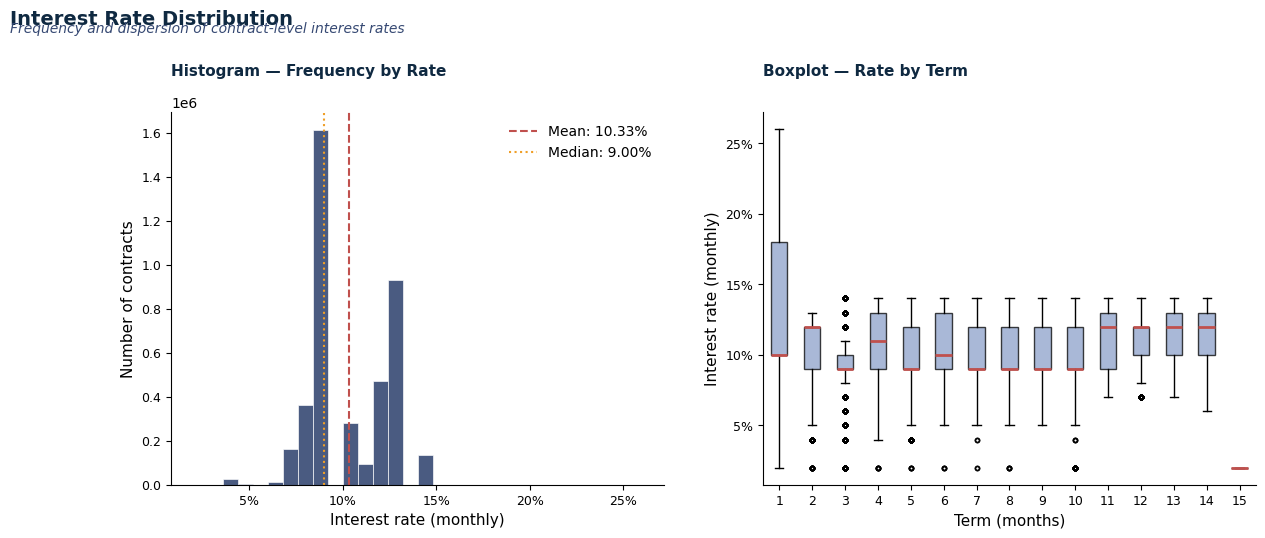

=== Descriptive statistics — interest rate (monthly) ===
count    408493700.00%
mean            10.33%
std              2.09%
min              2.00%
25%              9.00%
50%              9.00%
75%             13.00%
max             26.00%
Name: juros, dtype: object

Mode: 9.00%


In [19]:
# Interest Rate Distribution — Credit Portfolio

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
add_fig_title_block(fig, 'Interest Rate Distribution',
                     'Frequency and dispersion of contract-level interest rates')

# --- Main histogram ---
ax1 = axes[0]
ax1.hist(
    dados['juros'], bins=30,
    color=PALETTE["navy_mid"], edgecolor='white', linewidth=0.5, alpha=0.9
)

media   = dados['juros'].mean()
mediana = dados['juros'].median()
ax1.axvline(media,   color=PALETTE["alert_red"],  linewidth=1.5, linestyle='--', label=f'Mean: {media:.2%}')
ax1.axvline(mediana, color=PALETTE["warn_amber"], linewidth=1.5, linestyle=':',  label=f'Median: {mediana:.2%}')

ax1.set_xlabel('Interest rate (monthly)', fontsize=11)
ax1.set_ylabel('Number of contracts', fontsize=11)
add_title_block(ax1, 'Histogram — Frequency by Rate', fontsize_title=11, pad=26)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.legend(fontsize=10, frameon=False)
style_axes(ax1)

# --- Boxplot by term band ---
ax2 = axes[1]
prazos = sorted(dados['prazo'].unique())
data_box = [dados[dados['prazo'] == p]['juros'].dropna().values for p in prazos]

bp = ax2.boxplot(
    data_box, labels=prazos, patch_artist=True,
    medianprops=dict(color=PALETTE["alert_red"], linewidth=2),
    whiskerprops=dict(linewidth=1, color=PALETTE["axis_black"]),
    capprops=dict(linewidth=1, color=PALETTE["axis_black"]),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color=PALETTE["muted_grey"])
)
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE["blue_light"])
    patch.set_alpha(0.75)

ax2.set_xlabel('Term (months)', fontsize=11)
ax2.set_ylabel('Interest rate (monthly)', fontsize=11)
add_title_block(ax2, 'Boxplot — Rate by Term', fontsize_title=11, pad=26)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
style_axes(ax2)

plt.subplots_adjust(top=0.80)
plt.show()

# --- Descriptive statistics (console) ---
print("=== Descriptive statistics — interest rate (monthly) ===")
print(dados['juros'].describe().apply(lambda x: f"{x:.2%}"))
print(f"\nMode: {dados['juros'].mode().values[0]:.2%}")


In [20]:
# Resumo da Etapa 0

DATA_REF =pd.Timestamp('2025-02-20')

checks = {
    'Duplicatas de id_parcela'     : dados.duplicated('id_parcela').sum(),
    'Parcela > prazo'              : (dados['parcela'] > dados['prazo']).sum(),
    'Vencimento < originação'      : (dados['vencimento'] < dados['data_originacao']).sum(),
    'Valores financiados negativos': (dados['valor_financiado'] <= 0).sum(),
    'Taxas fora de [1%, 30%] a.m.' : ((dados['juros'] < 0.01) | (dados['juros'] > 0.30)).sum(),
    'NaN em valor_pago'            : dados['valor_pago'].isna().sum(),
    'NaN em data_pagamento'        : dados['data_pagamento'].isna().sum(),
}

for check, valor in checks.items():
    status = "OK" if valor == 0 or 'NaN' in check else "ERRO"
    print(f"[{status}] {check}: {valor}")

print(f"Exposição total de valores pagos negativos: R$ {negativos_pago['valor_pago'].sum():,.2f}")

[OK] Duplicatas de id_parcela: 0
[OK] Parcela > prazo: 0
[OK] Vencimento < originação: 0
[OK] Valores financiados negativos: 0
[OK] Taxas fora de [1%, 30%] a.m.: 0
[OK] NaN em valor_pago: 1121621
[OK] NaN em data_pagamento: 1169000
Exposição total de valores pagos negativos: R$ -1,316.26


## Etapa 1 - Construção das Métricas Bases


- status_parcela: paga / em aberto / vencida sem pagamento
- dias_atraso: data_pagamento - vencimento(pagas) ou data_ref - vencimento (não pagas)
- tempo_ate_default: meses entre originação e entrada em 90+ DPD
- flag_atraso: booleano por faixa de DPD
- fpd_flag: 1ª parcela não paga em dia → risco latente de fraude
- recovery_rate:  % recuperado sobre saldo devedor do contrato defaultado

In [21]:
# Definimos o status da parcela entre "paga", "em aberto" e "vencida sem pagamento"
# Três estados possíveis e mutuamente exclusivos. A lógica verifica primeiro se existe pagamento,
# depois se a parcela ainda está no futuro. Qualquer coisa que reste é inadimplência real.

def classifica_status(row):
    if pd.notna(row['valor_pago']) and row['valor_pago'] > 0:
        return 'paga'
    elif row['vencimento'] > DATA_REF:
        return 'em aberto'  # ainda não venceu
    else:
        return 'vencida sem pagamento'  # venceu e não pagou → inadimplente

dados['status_parcela'] = dados.apply(classifica_status, axis=1)

print(dados['status_parcela'].value_counts())
print (f'----------------')
print(dados['status_parcela'].value_counts(normalize=True).map('{:.1%}'.format))

status_parcela
paga                     2963316
em aberto                 672492
vencida sem pagamento     449129
Name: count, dtype: int64
----------------
status_parcela
paga                     72.5%
em aberto                16.5%
vencida sem pagamento    11.0%
Name: proportion, dtype: object


In [22]:
# Para definirmos os dias de atraso temos que definir as parcelas pagas e quantos dias depois do vencimento o pagamento entrou

dados['dias_atraso_pago'] = (
    dados['data_pagamento'] - dados['vencimento']
).dt.days

# Para parcelas não pagas e já vencidas: dias corridos desde o vencimento

dados['dias_atraso_aberto'] = (
    DATA_REF - dados['vencimento']
).dt.days.clip(lower=0)  # clip evita negativos para parcelas futuras


# Combina as duas em uma coluna só

dados['dias_atraso'] = np.where(
    dados['status_parcela'] == 'paga',
    dados['dias_atraso_pago'],
    np.where(
        dados['status_parcela'] == 'vencida sem pagamento',
        dados['dias_atraso_aberto'],
        0  # em aberto → ainda não há atraso
    )
)

# Negativos em pagas = pagamento antecipado → zera

dados['dias_atraso'] = dados['dias_atraso'].clip(lower=0)

# Excluimos as duas colunas intermediarias utilizadas para chegar no dias_atraso

dados = dados.drop(columns=['dias_atraso_pago', 'dias_atraso_aberto'])

dados.head(10)

,data_originacao,id_cliente,id_contrato,valor_financiado,prazo,parcela,id_parcela,vencimento,valor_parcela,valor_pago,data_pagamento,juros,id_pos,status_parcela,dias_atraso
0,2024-08-21,1,1,212.648,6,5,1,2025-01-21,53.922,60.11,NaT,0.13,1,paga,NaN
1,2024-10-15,2,2,206.052,4,1,2,2024-11-15,68.269,60.79,2024-10-15,0.12,2,paga,0.0
2,2024-10-15,2,2,206.052,4,3,3,2025-01-15,68.269,70.50,2025-01-17,0.12,2,paga,2.0
3,2024-10-04,3,3,144.021,4,4,4,2025-02-04,48.913,NaN,NaT,0.13,3,vencida sem pagamento,16.0
4,2024-10-07,4,4,28.273,4,3,5,2025-01-07,9.602,NaN,NaT,0.13,4,vencida sem pagamento,44.0
5,2024-09-17,5,5,1728.891,10,9,6,2025-06-17,269.277,NaN,NaT,0.09,5,em aberto,0.0
6,2024-10-03,6,6,65.627,4,3,7,2025-01-03,21.743,NaN,NaT,0.12,6,vencida sem pagamento,48.0
7,2024-09-27,7,7,44.442,4,3,8,2024-12-27,14.447,12.02,2024-11-05,0.11,7,paga,0.0
8,2024-09-17,8,8,332.869,3,1,9,2024-10-17,139.305,135.06,2024-10-07,0.12,2,paga,0.0
9,2024-09-17,8,8,332.869,3,3,10,2024-12-17,139.305,121.20,2024-11-10,0.12,2,paga,0.0


In [23]:
# Função para criar os buckets de DPD

def classifica_dpd(dias):
    if pd.isna(dias) or dias == 0:
        return 'em dia'
    elif dias <= 30:
        return '1-30 DPD'
    elif dias <= 60:
        return '31-60 DPD'
    elif dias <= 90:
        return '61-90 DPD'
    else:
        return '90+ DPD'  # default formal na maioria dos modelos

dados['flag_atraso'] = dados['dias_atraso'].apply(classifica_dpd)

print(dados['flag_atraso'].value_counts())

flag_atraso
em dia       2784608
1-30 DPD      783374
90+ DPD       374619
31-60 DPD      88603
61-90 DPD      53733
Name: count, dtype: int64


In [24]:
# Criamos a medida do tempo ate default
# Identifica parcelas em default (90+ DPD) por contrato

defaults = dados[dados['flag_atraso'] == '90+ DPD'].copy()

# Pega a data do primeiro vencimento que entrou em 90+ por contrato

primeiro_default = defaults.groupby('id_contrato')['vencimento'].min().reset_index()
primeiro_default.columns = ['id_contrato', 'data_primeiro_default']

primeiro_default.head(10)

,id_contrato,data_primeiro_default
0,1000003,2024-04-21
1,1000006,2024-03-02
2,1000010,2024-01-05
3,1000011,2023-11-24
4,1000012,2023-12-25
5,1000015,2024-01-18
6,1000018,2023-11-21
7,1000025,2023-12-08
8,100003,2024-09-30
9,1000031,2023-11-30


In [25]:
# Puxa a data de originação de cada contrato

originacao = dados.groupby('id_contrato')['data_originacao'].first().reset_index()

# Junta e calcula meses até o default

tempo_default = originacao.merge(primeiro_default, on='id_contrato', how='left')
tempo_default['tempo_ate_default_meses'] = (
    (tempo_default['data_primeiro_default'] - tempo_default['data_originacao'])
    .dt.days / 30).round(1)


# Incorpora a nova coluna no dataframe principal

dados = dados.merge(
    tempo_default[['id_contrato', 'tempo_ate_default_meses']],
    on='id_contrato', how='left'
)

dados.head(10)

,data_originacao,id_cliente,id_contrato,valor_financiado,prazo,parcela,id_parcela,vencimento,valor_parcela,valor_pago,data_pagamento,juros,id_pos,status_parcela,dias_atraso,flag_atraso,tempo_ate_default_meses
0,2024-08-21,1,1,212.648,6,5,1,2025-01-21,53.922,60.11,NaT,0.13,1,paga,NaN,em dia,NaN
1,2024-10-15,2,2,206.052,4,1,2,2024-11-15,68.269,60.79,2024-10-15,0.12,2,paga,0.0,em dia,NaN
2,2024-10-15,2,2,206.052,4,3,3,2025-01-15,68.269,70.50,2025-01-17,0.12,2,paga,2.0,1-30 DPD,NaN
3,2024-10-04,3,3,144.021,4,4,4,2025-02-04,48.913,NaN,NaT,0.13,3,vencida sem pagamento,16.0,1-30 DPD,NaN
4,2024-10-07,4,4,28.273,4,3,5,2025-01-07,9.602,NaN,NaT,0.13,4,vencida sem pagamento,44.0,31-60 DPD,NaN
5,2024-09-17,5,5,1728.891,10,9,6,2025-06-17,269.277,NaN,NaT,0.09,5,em aberto,0.0,em dia,NaN
6,2024-10-03,6,6,65.627,4,3,7,2025-01-03,21.743,NaN,NaT,0.12,6,vencida sem pagamento,48.0,31-60 DPD,NaN
7,2024-09-27,7,7,44.442,4,3,8,2024-12-27,14.447,12.02,2024-11-05,0.11,7,paga,0.0,em dia,NaN
8,2024-09-17,8,8,332.869,3,1,9,2024-10-17,139.305,135.06,2024-10-07,0.12,2,paga,0.0,em dia,NaN
9,2024-09-17,8,8,332.869,3,3,10,2024-12-17,139.305,121.20,2024-11-10,0.12,2,paga,0.0,em dia,NaN


In [26]:
# First Payment Default (FPD) é um dos indicadores mais sensíveis de qualidade de originação.
# Identifica a primeira parcela de cada contrato (parcela == 1)

primeira_parcela = dados[dados['parcela'] == 1].copy()

# FPD: parcela 1 não foi paga até a DATA_REF

primeira_parcela['fpd_flag'] = (
    (primeira_parcela['status_parcela'] == 'vencida sem pagamento') |
    (
        (primeira_parcela['status_parcela'] == 'paga') &
        (primeira_parcela['dias_atraso'] > 30)  # tolerância de 30 dias - padrão comercial
    )
)

# Incorpora a coluna no dataframe principal

fpd = primeira_parcela[['id_contrato', 'fpd_flag']]
dados = dados.merge(fpd, on='id_contrato', how='left')
dados['fpd_flag'] = dados['fpd_flag'].fillna(False)

print(f"Contratos com FPD: {dados.groupby('id_contrato')['fpd_flag'].first().sum()}")
print(f"Taxa de FPD: {dados.groupby('id_contrato')['fpd_flag'].first().mean():.1%}")


Contratos com FPD: 93679
Taxa de FPD: 9.1%


In [27]:
# O recovery_rate entra diretamente no cálculo de LGD (Loss Given Default)
# Soma do que foi efetivamente pago por contrato

pago_por_contrato = dados.groupby('id_contrato').agg(
    total_pago        = ('valor_pago', 'sum'),
    total_devido      = ('valor_parcela', 'sum'),
    valor_financiado  = ('valor_financiado', 'first'),
    em_default        = ('flag_atraso', lambda x: (x == '90+ DPD').any())
).reset_index()

# Recovery só faz sentido para contratos em default

defaults_contrato = pago_por_contrato[pago_por_contrato['em_default'] == True].copy()

defaults_contrato['recovery_rate'] = (
    defaults_contrato['total_pago'] / defaults_contrato['total_devido']
).clip(upper=1.0)  # cap em 100% — não existe recuperação acima do principal

print(f"\nRecovery médio: {defaults_contrato['recovery_rate'].mean():.1%}")
print(f"Contratos com 0% de recovery: {(defaults_contrato['recovery_rate'] == 0).sum()}")

# Incorpora no dataframe principal

dados = dados.merge(
    defaults_contrato[['id_contrato', 'recovery_rate']],
    on='id_contrato', how='left')

dados.head(10)


Recovery médio: 40.8%
Contratos com 0% de recovery: 47180


,data_originacao,id_cliente,id_contrato,valor_financiado,prazo,parcela,id_parcela,vencimento,valor_parcela,valor_pago,data_pagamento,juros,id_pos,status_parcela,dias_atraso,flag_atraso,tempo_ate_default_meses,fpd_flag,recovery_rate
0,2024-08-21,1,1,212.648,6,5,1,2025-01-21,53.922,60.11,NaT,0.13,1,paga,NaN,em dia,NaN,False,NaN
1,2024-10-15,2,2,206.052,4,1,2,2024-11-15,68.269,60.79,2024-10-15,0.12,2,paga,0.0,em dia,NaN,False,NaN
2,2024-10-15,2,2,206.052,4,3,3,2025-01-15,68.269,70.50,2025-01-17,0.12,2,paga,2.0,1-30 DPD,NaN,False,NaN
3,2024-10-04,3,3,144.021,4,4,4,2025-02-04,48.913,NaN,NaT,0.13,3,vencida sem pagamento,16.0,1-30 DPD,NaN,False,NaN
4,2024-10-07,4,4,28.273,4,3,5,2025-01-07,9.602,NaN,NaT,0.13,4,vencida sem pagamento,44.0,31-60 DPD,NaN,False,NaN
5,2024-09-17,5,5,1728.891,10,9,6,2025-06-17,269.277,NaN,NaT,0.09,5,em aberto,0.0,em dia,NaN,False,NaN
6,2024-10-03,6,6,65.627,4,3,7,2025-01-03,21.743,NaN,NaT,0.12,6,vencida sem pagamento,48.0,31-60 DPD,NaN,False,NaN
7,2024-09-27,7,7,44.442,4,3,8,2024-12-27,14.447,12.02,2024-11-05,0.11,7,paga,0.0,em dia,NaN,False,NaN
8,2024-09-17,8,8,332.869,3,1,9,2024-10-17,139.305,135.06,2024-10-07,0.12,2,paga,0.0,em dia,NaN,False,NaN
9,2024-09-17,8,8,332.869,3,3,10,2024-12-17,139.305,121.20,2024-11-10,0.12,2,paga,0.0,em dia,NaN,False,NaN


In [28]:
# Ao fim fazemos um resumo da Etapa 1 para definir as métricas criadas

print("=== Métricas-base construídas ===\n")
print(f"Data de referência       : {DATA_REF.date()}")
print(f"Total de parcelas        : {len(dados):,}")
print(f"Total de contratos       : {dados['id_contrato'].nunique():,}")

print("\n--- Status das parcelas ---")
print(dados['status_parcela'].value_counts().to_string())

print("\n--- Distribuição de DPD ---")
ordem = ['em dia', '1-30 DPD', '31-60 DPD', '61-90 DPD', '90+ DPD']
print(dados['flag_atraso'].value_counts().reindex(ordem).to_string())

print(f"\n--- Inadimplência 90+ DPD ---")
inad = (dados['flag_atraso'] == '90+ DPD').mean()
print(f"Por parcela: {inad:.1%}")

print(f"\n--- FPD ---")
fpd_rate = dados.groupby('id_contrato')['fpd_flag'].first().mean()
print(f"Taxa de FPD: {fpd_rate:.1%}")

print(f"\n--- Recovery (contratos em default) ---")
if 'recovery_rate' in dados.columns:
    print(dados['recovery_rate'].dropna().describe().map('{:.1%}'.format))

=== Métricas-base construídas ===

Data de referência       : 2025-02-20
Total de parcelas        : 4,084,937
Total de contratos       : 1,032,932

--- Status das parcelas ---
status_parcela
paga                     2963316
em aberto                 672492
vencida sem pagamento     449129

--- Distribuição de DPD ---
flag_atraso
em dia       2784608
1-30 DPD      783374
31-60 DPD      88603
61-90 DPD      53733
90+ DPD       374619

--- Inadimplência 90+ DPD ---
Por parcela: 9.2%

--- FPD ---
Taxa de FPD: 9.1%

--- Recovery (contratos em default) ---
count    59594600.0%
mean           39.4%
std            36.6%
min             0.0%
25%             0.0%
50%            32.3%
75%            70.6%
max           100.0%
Name: recovery_rate, dtype: object


## Etapa 2 - Qualidade estática



- **NPL 90+:** saldo devedor e quantidade de contratos em 90+ DPD
- **NPL Ratio:** `saldo 90+ DPD / EAD total` — atenção à *ilusão do denominador* quando a originação cresce rápido
- **NPL Creation:** fluxo de novos contratos degradando para 90+ DPD (write-offs − curas)
- **Distribuição DPD:** faixas 1–30 / 31–60 / 61–90 / 90+ dias

In [29]:
# EAD — EXPOSURE AT DEFAULT (Exposição ao Risco)

# Mapeamento de Risco (Transforma texto em número para o MAX funcionar)

de_para_risco = {
    'em dia'    : 0,
    '1-30 DPD'  : 1,
    '31-60 DPD' : 2,
    '61-90 DPD' : 3,
    '90+ DPD'   : 4
}

dados['flag_atraso_num'] = dados['flag_atraso'].map(de_para_risco).fillna(0).astype(int)

# Agrupamento e Cálculo por Contrato, somando APENAS as parcelas não pagas → saldo remanescente real

ead_por_contrato = (
    dados[dados['status_parcela'] != 'paga']
    .groupby('id_contrato', sort=False)
    .agg(
        ead                = ('valor_parcela', 'sum'),
        parcelas_em_aberto = ('valor_parcela', 'count'),
        pior_bucket_num    = ('flag_atraso_num', 'max')
    )
    .reset_index()
)

# Recuperação de Contratos Quitados (left join para preservar todos)

contratos_total  = dados[['id_contrato']].drop_duplicates()
ead_por_contrato = contratos_total.merge(ead_por_contrato, on='id_contrato', how='left')

# Tratamento de Valores Nulos,contratos quitados ficam com ead=0 e pior_bucket='paga'

ead_por_contrato[['ead', 'parcelas_em_aberto']] = (
    ead_por_contrato[['ead', 'parcelas_em_aberto']].fillna(0)
)

ead_por_contrato['pior_bucket_num'] = (
    ead_por_contrato['pior_bucket_num'].fillna(0).astype(int)
)

de_para_reverso = {v: k for k, v in de_para_risco.items()}
ead_por_contrato['pior_bucket'] = (
    ead_por_contrato['pior_bucket_num'].map(de_para_reverso).fillna('paga')
)

# Consolidação Financeira

EAD_TOTAL = dados.drop_duplicates('id_contrato')['valor_financiado'].sum()
n_contratos_total = dados['id_contrato'].nunique()
n_contratos_ativos = (ead_por_contrato['ead'] > 0).sum()
n_contratos_quit   = (ead_por_contrato['ead'] == 0).sum()

# Output de Performance

print("═" * 52)
print("  EAD — Exposição Total da Carteira")
print("═" * 52)
print(f"  Contratos únicos               : {n_contratos_total:,}")
print(f"  EAD Total (saldo remanescente) : R$ {EAD_TOTAL:,.2f}")
print(f"  EAD médio por contrato         : R$ {EAD_TOTAL / n_contratos_ativos:,.2f}")
print(f"  Ticket médio (valor financiado): R$ {dados.drop_duplicates('id_contrato')['valor_financiado'].mean():,.2f}")
print(f"  Contratos 100% quitados        : {n_contratos_quit:,}")
print(f"  Contratos com EAD > 0          : {n_contratos_ativos:,}")
print("═" * 52)

════════════════════════════════════════════════════
  EAD — Exposição Total da Carteira
════════════════════════════════════════════════════
  Contratos únicos               : 1,032,932
  EAD Total (saldo remanescente) : R$ 267,523,005.40
  EAD médio por contrato         : R$ 718.29
  Ticket médio (valor financiado): R$ 258.99
  Contratos 100% quitados        : 660,489
  Contratos com EAD > 0          : 372,443
════════════════════════════════════════════════════


In [30]:
# NPL 90+ DPD (Ajustado para Carteira Ativa e NPL Financeiro)

# Define o universo NPL: contratos com ao menos uma parcela em 90+ DPD que ainda não foi paga (contaminação total — convenção BACEN/BIS)

npl_ids = set(
    dados[
        (dados['flag_atraso']    == '90+ DPD') &
        (dados['status_parcela'] != 'paga')
    ]['id_contrato'].unique()
)

# Restringe o denominador à carteira ATIVA (EAD > 0)

ativos = set(ead_por_contrato.loc[ead_por_contrato['ead'] > 0, 'id_contrato'])
contratos_npl = npl_ids.intersection(ativos)

qtd_npl    = len(contratos_npl)
qtd_ativos = len(ativos)

# Saldo NPL: soma das parcelas efetivamente em 90+ DPD e não pagas

saldo_npl = ead_por_contrato[ead_por_contrato['id_contrato'].isin(contratos_npl)]['ead'].sum()

# Cálculo dos Indicadores de Performance

npl_ratio_qtd = (qtd_npl    / qtd_ativos) if qtd_ativos > 0 else 0  # visão de cobrança
npl_ratio_fin = (saldo_npl  / EAD_TOTAL)  if EAD_TOTAL  > 0 else 0  # visão regulatória de perda

# Output

print("═" * 58)
print("  Métricas NPL 90+ DPD (Performance de Crédito)")
print("═" * 58)
print(f"  Saldo Devedor NPL- 90+ (R$)  : R$ {saldo_npl:>14,.2f}")
print(f"  NPL Financeiro (%)      : {npl_ratio_fin:>14.2%}  (sobre EAD remanescente)")
print(f"  Contratos NPL (Qtd)      : {qtd_npl:>8,} de {qtd_ativos:,} ativos ({npl_ratio_qtd:.1%})")
print("═" * 58)

══════════════════════════════════════════════════════════
  Métricas NPL 90+ DPD (Performance de Crédito)
══════════════════════════════════════════════════════════
  Saldo Devedor NPL- 90+ (R$)  : R$  30,532,655.04
  NPL Financeiro (%)      :         11.41%  (sobre EAD remanescente)
  Contratos NPL (Qtd)      :  118,424 de 372,443 ativos (31.8%)
══════════════════════════════════════════════════════════


In [31]:
# NPL CREATION HISTÓRICO — FLUXO DE NOVOS DEFAULTS vs. CURAS

# Convenção adotada:
#   Entrada em 90+  → vencimento da parcela + 90 dias
#   Cura            → contrato que entrou em 90+ mas não possui mais nenhuma
#                     parcela com status 'vencida sem pagamento'

DATA_INICIO = dados['data_originacao'].min()

# Parcelas que estão ou estiveram em 90+ DPD

parcelas_90 = dados[dados['flag_atraso'] == '90+ DPD'].copy()
parcelas_90['data_entrada_90'] = parcelas_90['vencimento']

# Primeira entrada em 90+ por contrato + saldo envolvido

primeiro_default = (
    parcelas_90
    .sort_values('data_entrada_90')
    .groupby('id_contrato', sort=False)
    .agg(
        data_entrada_npl = ('data_entrada_90', 'min'),
        saldo_default    = ('valor_parcela',   'sum'),
    )
    .reset_index()
)

# Série mensal de ENTRADAS (novos defaults)

entradas_mensais = (
    primeiro_default[
        primeiro_default['data_entrada_npl'].between(DATA_INICIO, DATA_REF)
    ]
    .set_index('data_entrada_npl')
    .resample('ME')
    .agg(
        novos_defaults     = ('id_contrato',  'count'),
        volume_defaults_rs = ('saldo_default', 'sum'),
    )
)

# Identificação dos contratos curados [Curado = tocou 90+ em algum momento, mas hoje não tem parcela vencida sem pagar]

ainda_em_npl = set(
    dados[
        (dados['flag_atraso'] == '90+ DPD') &
        (dados['status_parcela'] == 'vencida sem pagamento')
    ]['id_contrato'].unique()
)

ids_curados = set(primeiro_default['id_contrato'].unique()) - ainda_em_npl

# Data e volume da cura (último pagamento após o default)

curas_mensais = (
    dados[
        dados['id_contrato'].isin(ids_curados) &
        (dados['status_parcela'] == 'paga')
    ]
    .merge(
        primeiro_default[['id_contrato', 'data_entrada_npl']],
        on='id_contrato'
    )
    .query('data_pagamento >= data_entrada_npl')   # apenas pagamentos pós-default
    .groupby('id_contrato', sort=False)
    .agg(
        data_cura     = ('data_pagamento', 'max'),
        volume_curado = ('valor_pago',     'sum'),
    )
    .reset_index()
    .set_index('data_cura')
    .resample('ME')
    .agg(
        curas           = ('id_contrato',  'count'),
        volume_curas_rs = ('volume_curado', 'sum'),
    )
)

# Consolida e calcula fluxos líquidos e estoques acumulados

npl_creation = (
    pd.concat([entradas_mensais, curas_mensais], axis=1)
    .fillna(0)
    .assign(
        novos_defaults         = lambda df: df['novos_defaults'].astype(int),
        curas                  = lambda df: df['curas'].astype(int),
        npl_liquido_qtd        = lambda df: df['novos_defaults']     - df['curas'],
        npl_liquido_rs         = lambda df: df['volume_defaults_rs'] - df['volume_curas_rs'],
        estoque_acumulado_qtd  = lambda df: (df['novos_defaults'] - df['curas']).cumsum(),
        estoque_acumulado_rs   = lambda df: (df['volume_defaults_rs'] - df['volume_curas_rs']).cumsum(),
    )
)

# Output

_tot_def = npl_creation['novos_defaults'].sum()
_tot_cur = npl_creation['curas'].sum()
_tot_liq = npl_creation['npl_liquido_qtd'].sum()
_vol_def = npl_creation['volume_defaults_rs'].sum()
_vol_cur = npl_creation['volume_curas_rs'].sum()
_vol_liq = npl_creation['npl_liquido_rs'].sum()

print(f"\n── NPL Creation Histórico  |  {DATA_INICIO.date()} → {DATA_REF.date()} ──")
print(f"  {'Métrica':<30} {'Qtd. Contratos':>15}  {'Volume (R$)':>18}")
print(f"  {'─'*65}")
print(f"  {'Entradas em 90+':<30} {_tot_def:>15,}  R$ {_vol_def:>14,.2f}")
print(f"  {'Curas':<30} {_tot_cur:>15,}  R$ {_vol_cur:>14,.2f}")
print(f"  {'Líquido (Entradas − Curas)':<30} {_tot_liq:>+15,}  R$ {_vol_liq:>+14,.2f}")


── NPL Creation Histórico  |  2023-01-01 → 2025-02-20 ──
  Métrica                         Qtd. Contratos         Volume (R$)
  ─────────────────────────────────────────────────────────────────
  Entradas em 90+                        143,391  R$  31,047,728.40
  Curas                                   24,967  R$   5,964,208.68
  Líquido (Entradas − Curas)            +118,424  R$ +25,083,519.73


In [32]:
# Tabela histórica mensal

display(
    npl_creation
    .rename(columns={
        'novos_defaults'       : 'Entradas (Qtd)',
        'volume_defaults_rs'   : 'Entradas (R$)',
        'curas'                : 'Curas (Qtd)',
        'volume_curas_rs'      : 'Curas (R$)',
        'npl_liquido_qtd'      : 'Líquido (Qtd)',
        'npl_liquido_rs'       : 'Líquido (R$)',
        'estoque_acumulado_qtd': 'Estoque Acum. (Qtd)',
        'estoque_acumulado_rs' : 'Estoque Acum. (R$)',
    })
    .style
    .format({
        'Entradas (Qtd)'      : '{:,}',
        'Entradas (R$)'       : 'R$ {:,.2f}',
        'Curas (Qtd)'         : '{:,}',
        'Curas (R$)'          : 'R$ {:,.2f}',
        'Líquido (Qtd)'       : '{:+,}',
        'Líquido (R$)'        : 'R$ {:+,.2f}',
        'Estoque Acum. (Qtd)' : '{:,}',
        'Estoque Acum. (R$)'  : 'R$ {:,.2f}',
    })
    .bar(subset=['Entradas (R$)'], color='#C00000', vmin=0)
    .bar(subset=['Curas (R$)'],    color='#70AD47', vmin=0)
    .background_gradient(subset=['Estoque Acum. (R$)'], cmap='RdYlGn_r')
    .set_caption(f"NPL Creation Histórico — {DATA_INICIO.date()} → {DATA_REF.date()}")
)


,Entradas (Qtd),Entradas (R$),Curas (Qtd),Curas (R$),Líquido (Qtd),Líquido (R$),Estoque Acum. (Qtd),Estoque Acum. (R$)
2023-02-28 00:00:00,"1,318","R$ 473,244.47",0,R$ 0.00,"+1,318","R$ +473,244.47","1,318","R$ 473,244.47"
2023-03-31 00:00:00,"2,221","R$ 647,507.29",0,R$ 0.00,"+2,221","R$ +647,507.29","3,539","R$ 1,120,751.75"
2023-04-30 00:00:00,"2,980","R$ 775,244.44",0,R$ 0.00,"+2,980","R$ +775,244.44","6,519","R$ 1,895,996.20"
2023-05-31 00:00:00,"3,104","R$ 815,583.43",5,"R$ 1,237.56","+3,099","R$ +814,345.87","9,618","R$ 2,710,342.07"
2023-06-30 00:00:00,"3,519","R$ 969,623.64",20,"R$ 8,469.00","+3,499","R$ +961,154.64","13,117","R$ 3,671,496.71"
2023-07-31 00:00:00,"3,794","R$ 1,066,190.02",127,"R$ 27,400.46","+3,667","R$ +1,038,789.56","16,784","R$ 4,710,286.27"
2023-08-31 00:00:00,"4,257","R$ 1,114,961.80",268,"R$ 59,292.48","+3,989","R$ +1,055,669.32","20,773","R$ 5,765,955.58"
2023-09-30 00:00:00,"5,041","R$ 1,267,590.72",312,"R$ 65,295.61","+4,729","R$ +1,202,295.10","25,502","R$ 6,968,250.69"
2023-10-31 00:00:00,"5,185","R$ 1,353,844.33",469,"R$ 98,308.43","+4,716","R$ +1,255,535.90","30,218","R$ 8,223,786.59"
2023-11-30 00:00:00,"6,183","R$ 1,526,583.61",641,"R$ 146,309.88","+5,542","R$ +1,380,273.73","35,760","R$ 9,604,060.32"


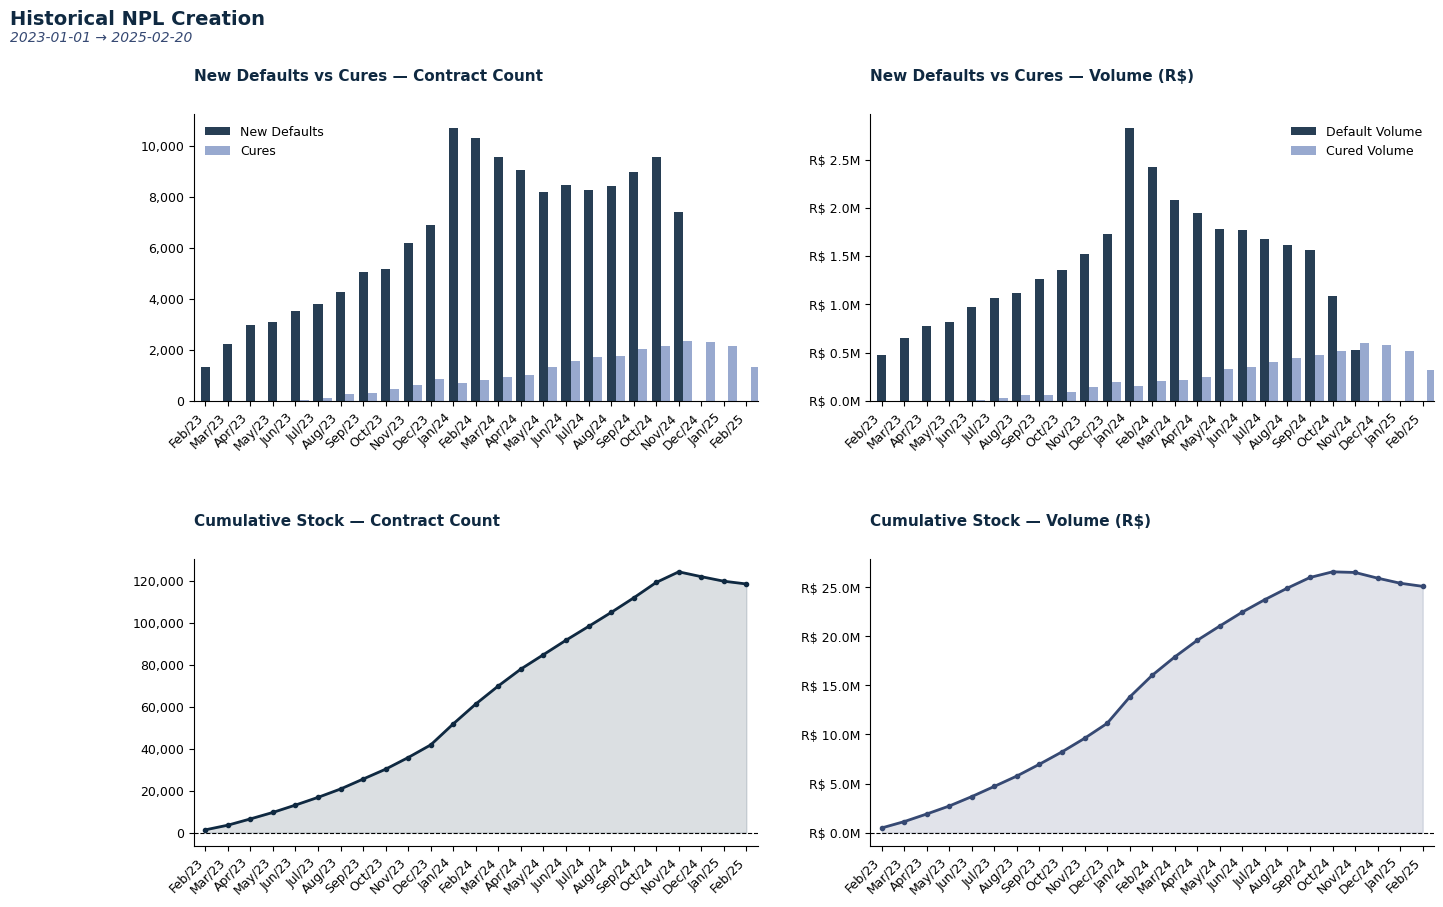

In [33]:
# Historical NPL Creation — 4-panel view (monthly flow + cumulative stock)

fig, axes = plt.subplots(2, 2, figsize=(16, 9.5))
add_fig_title_block(fig, 'Historical NPL Creation',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

x     = range(len(npl_creation))
meses = pd.to_datetime(npl_creation.index).strftime('%b/%y')

# Panel 1 - New Defaults vs Cures (count)
axes[0, 0].bar(x, npl_creation['novos_defaults'],
               label='New Defaults', color=PALETTE["navy_dark"], alpha=0.9, width=0.4)
axes[0, 0].bar([i + 0.4 for i in x], npl_creation['curas'],
               label='Cures', color=PALETTE["blue_light"], alpha=0.9, width=0.4)
add_title_block(axes[0, 0], 'New Defaults vs Cures \u2014 Contract Count', fontsize_title=11, pad=24)
axes[0, 0].legend(fontsize=9, frameon=False)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Panel 2 - New Defaults vs Cures (R$)
axes[0, 1].bar(x, npl_creation['volume_defaults_rs'],
               label='Default Volume', color=PALETTE["navy_dark"], alpha=0.9, width=0.4)
axes[0, 1].bar([i + 0.4 for i in x], npl_creation['volume_curas_rs'],
               label='Cured Volume', color=PALETTE["blue_light"], alpha=0.9, width=0.4)
add_title_block(axes[0, 1], 'New Defaults vs Cures \u2014 Volume (R$)', fontsize_title=11, pad=24)
axes[0, 1].legend(fontsize=9, frameon=False)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f}M'))

# Panel 3 - Cumulative stock (count)
axes[1, 0].plot(x, npl_creation['estoque_acumulado_qtd'],
                color=PALETTE["navy_dark"], linewidth=2, marker='o', markersize=3)
axes[1, 0].fill_between(x, npl_creation['estoque_acumulado_qtd'], alpha=0.15, color=PALETTE["navy_dark"])
axes[1, 0].axhline(0, color=PALETTE["axis_black"], linewidth=0.8, linestyle='--')
add_title_block(axes[1, 0], 'Cumulative Stock \u2014 Contract Count', fontsize_title=11, pad=24)
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Panel 4 - Cumulative stock (R$)
axes[1, 1].plot(x, npl_creation['estoque_acumulado_rs'],
                color=PALETTE["navy_mid"], linewidth=2, marker='o', markersize=3)
axes[1, 1].fill_between(x, npl_creation['estoque_acumulado_rs'], alpha=0.15, color=PALETTE["navy_mid"])
axes[1, 1].axhline(0, color=PALETTE["axis_black"], linewidth=0.8, linestyle='--')
add_title_block(axes[1, 1], 'Cumulative Stock \u2014 Volume (R$)', fontsize_title=11, pad=24)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f}M'))

# Shared x-axis (limits only) + house style — labels forced visible on every panel
for ax in axes.flat:
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
    ax.tick_params(axis='x', labelbottom=True)
    ax.tick_params(axis='y', labelsize=8)
    style_axes(ax)

plt.subplots_adjust(top=0.88, hspace=0.55)
plt.show()

In [34]:
# DISTRIBUIÇÃO DPD — AGING DA CARTEIRA

# O aging decompõe o portfólio em cinco buckets mutuamente exclusivos e revela
# a "pirâmide de risco" da carteira. Buckets mais pesados à direita (61-90, 90+)
# são o sinal de alerta: esses créditos têm baixíssima probabilidade de retorno
# sem alguma ação de cobrança ou reestruturação.

ORDEM_BUCKET = ['em dia', '1-30 DPD', '31-60 DPD', '61-90 DPD', '90+ DPD']

# Visão por PARCELA

aging_parcelas = (
    dados
    .groupby('flag_atraso', observed=True)
    .agg(
        qtd_parcelas  = ('id_parcela',    'count'),
        volume_parcela= ('valor_parcela', 'sum'),
    )
    .reindex(ORDEM_BUCKET)          # garante a ordem correta dos buckets
    .reset_index()
)

aging_parcelas['part_qtd_%']    = aging_parcelas['qtd_parcelas']   / aging_parcelas['qtd_parcelas'].sum()
aging_parcelas['part_volume_%'] = aging_parcelas['volume_parcela'] / aging_parcelas['volume_parcela'].sum()

def _ead_pct(bucket):
    v = ead_pct_dict.get(bucket)
    return f'{v:.1%}' if v is not None else '—'

def _qtd_pct(bucket):
    v = qtd_pct_dict.get(bucket)
    return f'{v:.1%}' if v is not None else '—'

# Visão por CONTRATO (usando o pior bucket do contrato)
# Um contrato assume o bucket do seu pior atraso — convenção padrão de carteiras

aging_contratos = (
    ead_por_contrato[ead_por_contrato['ead'] > 0]   # foco em exposição viva
    .groupby('pior_bucket', observed=True)
    .agg(
        qtd_contratos = ('id_contrato', 'count'),
        ead_bucket    = ('ead',         'sum'),
    )
    .reindex(ORDEM_BUCKET)
    .reset_index()
)

aging_contratos['part_qtd_%'] = (
    aging_contratos['qtd_contratos'] / aging_contratos['qtd_contratos'].sum()
)
aging_contratos['part_ead_%'] = (
    aging_contratos['ead_bucket'] / aging_contratos['ead_bucket'].sum()
)

# Output

print("\n── Aging por Parcela ───────────────────────────────────────────────────")
display(aging_parcelas.style
    .format({
        'qtd_parcelas'   : '{:,.0f}',
        'volume_parcela' : 'R$ {:,.2f}',
        'part_qtd_%'     : '{:.1%}',
        'part_volume_%'  : '{:.1%}',
    })
)

print("\n── Aging por Contrato (EAD) ────────────────────────────────────────────")
display(aging_contratos.style
    .format({
        'qtd_contratos': '{:,.0f}',
        'ead_bucket'   : 'R$ {:,.2f}',
        'part_qtd_%'   : '{:.1%}',
        'part_ead_%'   : '{:.1%}',
    })
)


── Aging por Parcela ───────────────────────────────────────────────────


,flag_atraso,qtd_parcelas,volume_parcela,part_qtd_%,part_volume_%
0,em dia,"2,784,608","R$ 241,147,552.02",68.2%,68.9%
1,1-30 DPD,"783,374","R$ 66,662,849.23",19.2%,19.0%
2,31-60 DPD,"88,603","R$ 7,040,273.35",2.2%,2.0%
3,61-90 DPD,"53,733","R$ 4,212,759.02",1.3%,1.2%
4,90+ DPD,"374,619","R$ 31,047,728.40",9.2%,8.9%



── Aging por Contrato (EAD) ────────────────────────────────────────────


,pior_bucket,qtd_contratos,ead_bucket,part_qtd_%,part_ead_%
0,em dia,"193,978","R$ 51,687,810.57",52.1%,52.7%
1,1-30 DPD,"32,290","R$ 8,298,395.15",8.7%,8.5%
2,31-60 DPD,"16,544","R$ 4,486,786.78",4.4%,4.6%
3,61-90 DPD,"11,207","R$ 2,984,990.29",3.0%,3.0%
4,90+ DPD,"118,424","R$ 30,532,655.04",31.8%,31.2%


In [35]:
# SCORECARD DE FOTOGRAFIA DA CARTEIRA — TABELA CONSOLIDADA
# Entregável central da Etapa 2: concentra em uma única view os números que um
# comitê de crédito ou investidor institucional pede antes de qualquer conversa
# de due diligence. Construído 100% a partir das variáveis já calculadas.

# Helpers para leitura segura do aging

ead_pct_dict = aging_contratos.set_index('pior_bucket')['part_ead_%'].to_dict()
qtd_pct_dict = aging_contratos.set_index('pior_bucket')['part_qtd_%'].to_dict()

# FPD

fpd_rate = dados.groupby('id_contrato')['fpd_flag'].first().mean()

# Recovery (opcional — presente se Etapa 1 foi executada)

if 'recovery_rate' in dados.columns:
    _recovery = dados.groupby('id_contrato')['recovery_rate'].first().dropna()
    recovery_str = f"{_recovery.mean():.1%}" if not _recovery.empty else '—'
else:
    recovery_str = '—'

# Montagem do scorecard

scorecard = pd.DataFrame([

    # TAMANHO

    ('Tamanho', 'EAD Total da Carteira',
     f"R$ {EAD_TOTAL:,.2f}",
     'Exposição total em parcelas não pagas (IFRS 9)'),

    ('Tamanho', 'Total de Contratos',
     f"{n_contratos_total:,}",
     'Universo completo de contratos na tape'),

    ('Tamanho', 'Contratos com EAD > 0',
     f"{(ead_por_contrato['ead'] > 0).sum():,}",
     'Contratos com ao menos uma parcela em aberto ou vencida'),

    ('Tamanho', 'Contratos 100% Quitados',
     f"{(ead_por_contrato['ead'] == 0).sum():,}",
     'Contratos encerrados sem exposição residual'),

    # NPL STOCK

    ('NPL Stock', 'Saldo NPL 90+ (R$)',
     f"R$ {saldo_npl:,.2f}",
     'Parcelas vencidas há > 90 dias e não pagas'),

    ('NPL Stock', 'Contratos NPL 90+',
     f"{qtd_npl:,}  ({qtd_npl / qtd_ativos:.1%} do total)",
     'Contratos com ao menos uma parcela em 90+ DPD'),

    ('NPL Stock', 'NPL Ratio',
     f"{npl_ratio_fin:.2%}",
     'Saldo 90+ / EAD Total — referência BR: < 8% saudável'),

    # NPL FLOW

    ('NPL Flow', 'Total Entradas em 90+ (histórico)',
     f"{_tot_def:,}  contratos  |  R$ {_vol_def:,.2f}",
     f'Período: {DATA_INICIO.date()} → {DATA_REF.date()}'),

    ('NPL Flow', 'Total Curas (histórico)',
     f"{_tot_cur:,}  contratos  |  R$ {_vol_cur:,.2f}",
     'Contratos que regularizaram todas as parcelas vencidas'),

    ('NPL Flow', 'NPL Creation Líquido',
     f"{_tot_liq:+,}  contratos  |  R$ {_vol_liq:+,.2f}",
     'Entradas − Curas ao longo de todo o período'),

    # AGING

    ('Aging (% EAD)', 'Em Dia',
     _ead_pct('em dia'),
     f"Qtd: {_qtd_pct('em dia')}"),

    ('Aging (% EAD)', '1–30 DPD',
     _ead_pct('1-30 DPD'),
     f"Qtd: {_qtd_pct('1-30 DPD')}"),

    ('Aging (% EAD)', '31–60 DPD',
     _ead_pct('31-60 DPD'),
     f"Qtd: {_qtd_pct('31-60 DPD')}"),

    ('Aging (% EAD)', '61–90 DPD',
     _ead_pct('61-90 DPD'),
     f"Qtd: {_qtd_pct('61-90 DPD')}"),

    ('Aging (% EAD)', '90+ DPD',
     _ead_pct('90+ DPD'),
     f"Qtd: {_qtd_pct('90+ DPD')}"),

    # QUALIDADE DE ORIGINAÇÃO

    ('Originação', 'Taxa de FPD',
     f"{fpd_rate:.1%}",
     'First Payment Default — parcela 1 não paga (sinal de adverse selection)'),

    ('Originação', 'Recovery Médio (contratos em default)',
     recovery_str,
     'Valor recuperado / principal originado — proxy de LGD'),

], columns=['Categoria', 'Indicador', 'Valor', 'Observação'])


# Formatação visual (Dark Mode Zebra Striping)

display(
    scorecard.style
    .set_properties(**{
        'text-align' : 'left',
        'font-size'  : '13px',
        'font-family': 'sans-serif',
        'padding'    : '8px 15px',
        'border'     : 'none',            # Sem bordas nas células
        'color'      : '#E0E0E0'          # Texto claro
    })
    .set_table_styles([
        {'selector': 'table',
         'props'   : [('background-color', '#212121'), ('border-collapse', 'collapse')]},

        {'selector': 'thead th',
         'props'   : [('background-color', '#212121'),
                      ('color', '#FFFFFF'),
                      ('font-weight', 'bold'),
                      ('font-size', '13px'),
                      ('text-align', 'left'),
                      ('border-bottom', '1px solid #555555'), # Linha sutil abaixo do cabeçalho
                      ('padding', '10px 15px')]},

        # Linhas ímpares (mais claras)

        {'selector': 'tbody tr:nth-child(odd)',
         'props'   : [('background-color', '#333333')]},

        # Linhas pares (mais escuras)

        {'selector': 'tbody tr:nth-child(even)',
         'props'   : [('background-color', '#212121')]},

        # Título da tabela

        {'selector': 'caption',
         'props'   : [('font-size', '15px'),
                      ('font-weight', 'bold'),
                      ('color', '#FFFFFF'),
                      ('text-align', 'left'),
                      ('padding-bottom', '10px')]},

        # Opcional: destaque leve ao passar o mouse

        {'selector': 'tbody tr:hover',
         'props'   : [('background-color', '#444444')]}
    ])
    .set_caption(f"Scorecard — Fotografia da Carteira  |  DATA_REF: {DATA_REF.date()}")
    .hide(axis='index')
)



Categoria,Indicador,Valor,Observação
Tamanho,EAD Total da Carteira,"R$ 267,523,005.40",Exposição total em parcelas não pagas (IFRS 9)
Tamanho,Total de Contratos,"1,032,932",Universo completo de contratos na tape
Tamanho,Contratos com EAD > 0,"372,443",Contratos com ao menos uma parcela em aberto ou vencida
Tamanho,Contratos 100% Quitados,"660,489",Contratos encerrados sem exposição residual
NPL Stock,Saldo NPL 90+ (R$),"R$ 30,532,655.04",Parcelas vencidas há > 90 dias e não pagas
NPL Stock,Contratos NPL 90+,"118,424 (31.8% do total)",Contratos com ao menos uma parcela em 90+ DPD
NPL Stock,NPL Ratio,11.41%,Saldo 90+ / EAD Total — referência BR: < 8% saudável
NPL Flow,Total Entradas em 90+ (histórico),"143,391 contratos | R$ 31,047,728.40",Período: 2023-01-01 → 2025-02-20
NPL Flow,Total Curas (histórico),"24,967 contratos | R$ 5,964,208.68",Contratos que regularizaram todas as parcelas vencidas
NPL Flow,NPL Creation Líquido,"+118,424 contratos | R$ +25,083,519.73",Entradas − Curas ao longo de todo o período


In [36]:
# Rodapé executivo

print("\n" + "═" * 65)
print("  ETAPA 2 — QUALIDADE ESTÁTICA: CONCLUÍDA")
print("═" * 65)
print(f"  DATA_REF               : {DATA_REF.date()}")
print(f"  EAD Total              : R$ {EAD_TOTAL:,.2f}")
print(f"  NPL Ratio              : {npl_ratio_fin:.2%}")
print(f"  NPL Creation Líquido   : {_tot_liq:+,} contratos  |  R$ {_vol_liq:+,.2f}")
_bucket_maior = aging_contratos.loc[aging_contratos['part_ead_%'].idxmax(), 'pior_bucket']
_bucket_pct   = aging_contratos['part_ead_%'].max()
print(f"  Bucket dominante (EAD) : {_bucket_maior} ({_bucket_pct:.1%})")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  ETAPA 2 — QUALIDADE ESTÁTICA: CONCLUÍDA
═════════════════════════════════════════════════════════════════
  DATA_REF               : 2025-02-20
  EAD Total              : R$ 267,523,005.40
  NPL Ratio              : 11.41%
  NPL Creation Líquido   : +118,424 contratos  |  R$ +25,083,519.73
  Bucket dominante (EAD) : em dia (52.7%)
═════════════════════════════════════════════════════════════════


## Etapa 3 — Vintage curve analysis

- Matriz de Default Cumulativo e age_at_default
- Análise Vintage curve
- Perfil do produto
- Concentração e Dispersão — Gini, Curva de Lorenz e Curva ABC


In [37]:
"""
------------------------------------------------------------------------------
A Matriz de Default Cumulativo por Cohort acompanha a "idade" de cada safra (mês de originação) para entender
como a inadimplência evolui ao longo do tempo.

Correção Aplicada: Um contrato leva, por definição matemática, 90 dias após o
vencimento de uma parcela para cruzar a linha de "90+ DPD". A idade de quebra
(age_at_default) agora reflete o mês exato em que o contrato entrou nesse balde
físico de tempo, e não a "idade da parcela" original, limpando o ruído inicial.
"""
# Define padrão para gráficos

plt.style.use('seaborn-v0_8-whitegrid')

# Configuração inicial

df_vint = dados.copy()

# Criação do 'cohort' (mês de originação)

df_vint['cohort'] = df_vint.groupby('id_contrato')['data_originacao'].transform('min').dt.to_period('M')

# Conferência da cobertura da carteira atualizada

print("── Cobertura da Carteira — Etapa 3 ──────────────────────")
print(f"  Cohort inicial  : {df_vint['cohort'].min()}")
print(f"  Cohort final    : {df_vint['cohort'].max()}")
print(f"  Vencimento mín  : {df_vint['vencimento'].min().date()}")
print(f"  Vencimento máx  : {df_vint['vencimento'].max().date()}")
print(f"  Total de safras : {df_vint['cohort'].nunique()}")
print("─" * 55)



── Cobertura da Carteira — Etapa 3 ──────────────────────
  Cohort inicial  : 2023-01
  Cohort final    : 2025-02
  Vencimento mín  : 2023-02-01
  Vencimento máx  : 2026-04-19
  Total de safras : 26
───────────────────────────────────────────────────────


In [38]:
# Para o Cálculo Real da Idade de Default (age_at_default), isolamos a princípio as parcelas que entraram em default

parcelas_default = df_vint[df_vint['flag_atraso'] == '90+ DPD'].copy()

# A data real da quebra é o vencimento da parcela + 90 dias

parcelas_default['data_quebra_real'] = parcelas_default['vencimento'] + pd.Timedelta(days=90)

# Encontramos a primeira quebra cronológica de cada contrato

first_default = (
    parcelas_default
    .groupby('id_contrato')['data_quebra_real']
    .min()
    .reset_index()
)

# Transforma a data real de quebra em período mensal

first_default['mes_quebra'] = first_default['data_quebra_real'].dt.to_period('M')

# Recupera o cohort do contrato para calcular a idade exata

first_default = first_default.merge(
    df_vint[['id_contrato', 'cohort']].drop_duplicates(),
    on='id_contrato'
)

# Calcula o age_at_default matemático real (Mês de Quebra - Mês de Originação)

first_default['age_at_default'] = (first_default['mes_quebra'] - first_default['cohort']).apply(lambda x: x.n)



In [39]:
# A Construção da Matriz de Vintage, começamos com o cálculo do tamanho original de cada safra (denominador)

cohort_size = df_vint.groupby('cohort')['id_contrato'].nunique().rename('total_contracts')

# Conta novos defaults por safra e por idade

vintage_agg = (
    first_default.groupby(['cohort', 'age_at_default'])['id_contrato']
    .count()
    .rename('new_defaults')
    .reset_index()
)

# Junta com o tamanho da safra e calcula a taxa cumulativa

vintage_agg = vintage_agg.merge(cohort_size, on='cohort')
vintage_agg['cum_default_rate'] = (
    vintage_agg.groupby('cohort')['new_defaults'].cumsum() / vintage_agg['total_contracts']
)

# Pivota para a estrutura de matriz

vintage_matrix = vintage_agg.pivot(
    index='cohort',
    columns='age_at_default',
    values='cum_default_rate'
)

# Garante que as colunas comecem cronologicamente a partir do age=0

max_age = vintage_matrix.columns.max() if not vintage_matrix.empty else 12
all_ages = range(0, int(max_age) + 1)
vintage_matrix = vintage_matrix.reindex(columns=all_ages)

# Preenche as idades onde a taxa não subiu (ffill) e zera as idades iniciais sem quebra

vintage_matrix = vintage_matrix.ffill(axis=1).fillna(0)

print("\n=== Matriz de Vintage Corrigida (Default Cumulativo 90+ DPD) ===")
display(
    vintage_matrix.style
    .format('{:.1%}', na_rep='—')
    .background_gradient(cmap='YlOrRd', axis=None)
)




=== Matriz de Vintage Corrigida (Default Cumulativo 90+ DPD) ===


age_at_default,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort,,,,,,,,,,,,,,,,,,
2023-01,0.0%,0.0%,0.0%,0.0%,8.5%,14.3%,19.2%,20.5%,21.0%,21.3%,21.4%,21.4%,21.4%,21.4%,21.5%,21.5%,21.5%,21.5%
2023-02,0.0%,0.0%,0.0%,0.8%,8.5%,14.6%,19.0%,20.2%,20.7%,20.9%,20.9%,21.0%,21.0%,21.0%,21.1%,21.1%,21.1%,21.1%
2023-03,0.0%,0.0%,0.0%,0.2%,7.8%,12.9%,16.7%,18.1%,18.5%,18.8%,18.9%,19.0%,19.0%,19.0%,19.0%,19.1%,19.1%,19.1%
2023-04,0.0%,0.0%,0.0%,0.5%,6.9%,11.4%,15.5%,17.1%,17.5%,17.7%,17.8%,17.9%,17.9%,18.0%,18.0%,18.0%,18.0%,18.0%
2023-05,0.0%,0.0%,0.0%,0.3%,7.2%,11.8%,15.5%,17.3%,17.7%,17.9%,18.0%,18.0%,18.1%,18.1%,18.1%,18.1%,18.1%,18.1%
2023-06,0.0%,0.0%,0.0%,0.4%,6.5%,11.2%,15.7%,17.2%,17.6%,17.8%,17.9%,18.0%,18.0%,18.0%,18.0%,18.0%,18.0%,18.0%
2023-07,0.0%,0.0%,0.0%,0.4%,6.8%,11.9%,15.7%,16.9%,17.4%,17.6%,17.8%,17.8%,17.8%,17.9%,17.9%,17.9%,17.9%,17.9%
2023-08,0.0%,0.0%,0.0%,0.2%,7.1%,12.1%,16.2%,17.9%,18.4%,18.7%,18.8%,18.9%,19.0%,19.0%,19.0%,19.0%,19.0%,19.0%
2023-09,0.0%,0.0%,0.0%,0.5%,6.8%,11.6%,16.1%,18.0%,18.6%,18.8%,18.9%,18.9%,19.0%,19.0%,19.0%,19.0%,19.0%,19.0%


In [40]:
# VERIFICAÇÃO DE VOLUMETRIA POR SAFRA (DENOMINADOR)

# Agrupa pela safra (cohort) e conta os IDs únicos de contrato

volumetria_safras = df_vint.groupby('cohort')['id_contrato'].nunique().reset_index()
volumetria_safras.columns = ['Safra (Cohort)', 'Qtd_Contratos']

# Adiciona o % de representatividade de cada safra no total da carteira

total_contratos_geral = volumetria_safras['Qtd_Contratos'].sum()
volumetria_safras['% do Total'] = volumetria_safras['Qtd_Contratos'] / total_contratos_geral

# Formatação visual para facilitar a leitura

display(
    volumetria_safras.style
    .format({
        'Qtd_Contratos': '{:,}',
        '% do Total': '{:.2%}'
    })
    .background_gradient(subset=['Qtd_Contratos'], cmap='Blues')
)

print(f"Último vencimento na base: {dados['vencimento'].max().date()}")
print(f"Último pagamento registrado: {dados['data_pagamento'].dropna().max().date()}")

,Safra (Cohort),Qtd_Contratos,% do Total
0,2023-01,"15,703",1.52%
1,2023-02,"15,570",1.51%
2,2023-03,"17,444",1.69%
3,2023-04,"19,046",1.84%
4,2023-05,"24,195",2.34%
5,2023-06,"23,999",2.32%
6,2023-07,"25,651",2.48%
7,2023-08,"30,548",2.96%
8,2023-09,"32,329",3.13%
9,2023-10,"37,622",3.64%


Último vencimento na base: 2026-04-19
Último pagamento registrado: 2025-02-20


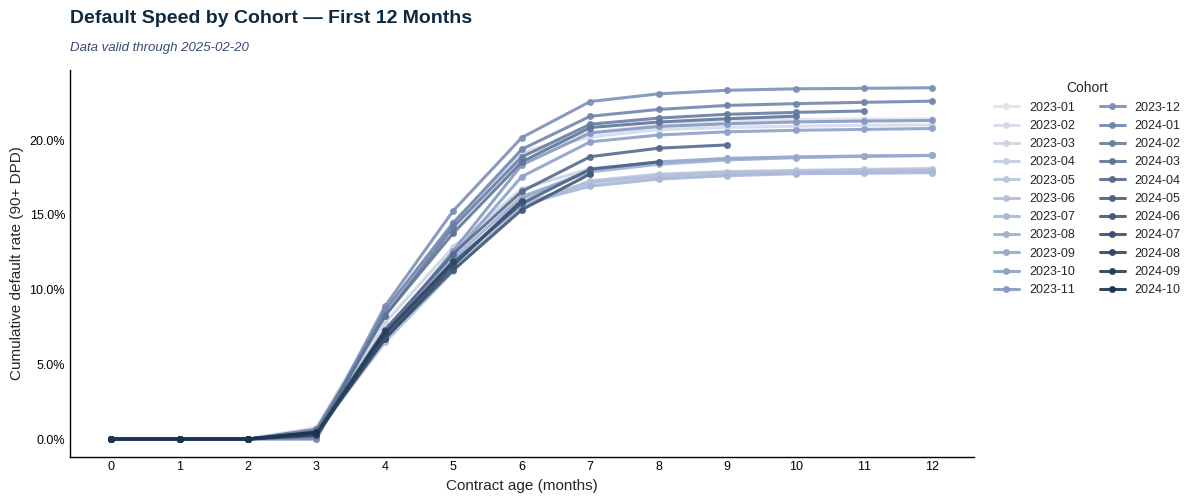

In [41]:
# Default Speed - Early Deterioration by Cohort (payment-cutoff safeguarded)

"""
The chart below zooms into the first 12 months of each cohort's life.
Cutoff correction: the base has a payment-data cutoff at 2025-02-20.
To avoid the "false default" created by future installments with no charge-off,
the matrix is truncated to ignore any break event after Jan/2025.
"""

# Matrix safeguard (filtering false defaults after the payment cutoff)

DATA_CORTE_PAGAMENTOS = DATA_REF
MES_CORTE = DATA_CORTE_PAGAMENTOS.to_period('M')

vintage_matrix_segura = vintage_matrix.copy()

for cohort in vintage_matrix_segura.index:
    for age in vintage_matrix_segura.columns:
        mes_calendario = cohort + age
        if mes_calendario >= MES_CORTE:
            vintage_matrix_segura.loc[cohort, age] = np.nan

# Chart configuration

JANELA_EARLY = 12   # months of life considered "early phase"

fig, ax = plt.subplots(figsize=(13, 5.6))

n_cohorts = len(vintage_matrix_segura.index)
cores     = HOUSE_CMAP(np.linspace(0.15, 0.95, n_cohorts))   # navy -> light-blue gradient (house palette)

for i, cohort in enumerate(vintage_matrix_segura.index):
    serie = vintage_matrix_segura.loc[cohort, :JANELA_EARLY].dropna()
    if len(serie) < 2:      # skip very recent cohorts with under 2 months of maturation
        continue
    ax.plot(serie.index, serie.values, label=str(cohort), color=cores[i],
            alpha=0.9, lw=2.2, marker='o', markersize=4)

add_title_block(
    ax, f'Default Speed by Cohort \u2014 First {JANELA_EARLY} Months',
    f'Data valid through {DATA_CORTE_PAGAMENTOS.date()}', fontsize_title=14, pad=34
)
ax.set_xlabel('Contract age (months)', fontsize=11)
ax.set_ylabel('Cumulative default rate (90+ DPD)', fontsize=11)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, ncol=2, frameon=False)
style_axes(ax)

plt.subplots_adjust(top=0.80, right=0.82)
plt.show()


/tmp/ipykernel_2169/2174995543.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


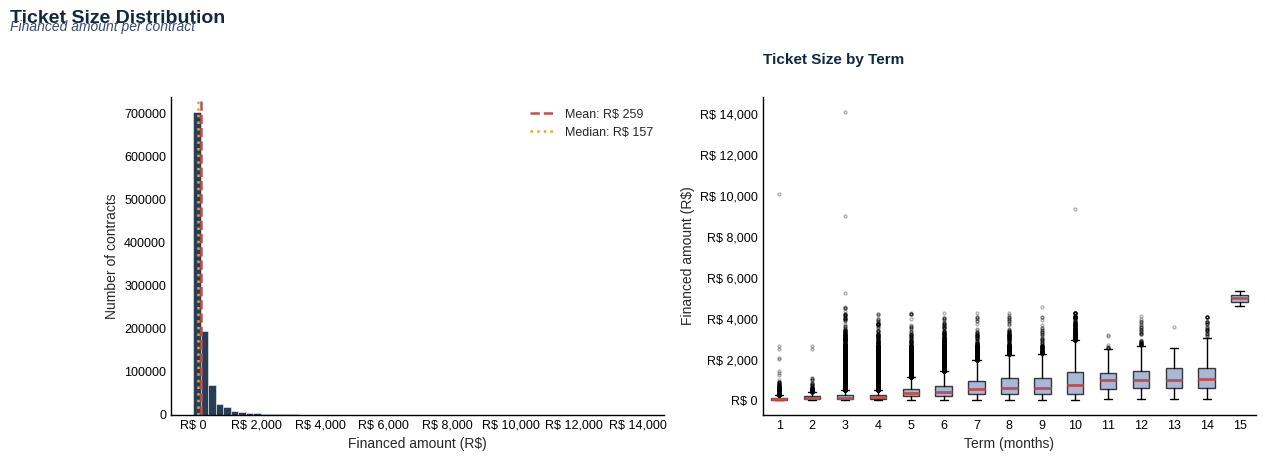

Mean ticket    : R$ 258.99
Median ticket  : R$ 157.38
Min / max      : R$ 10.04 / R$ 14,124.16
Std. deviation : R$ 326.80


In [42]:
# Product Profile - Ticket Size Distribution Histogram

"""
The distribution of ticket size (amount financed per contract) reveals the product profile:
portfolios concentrated in low values tend to have greater risk pulverization but lower
margin per operation. Bimodal distributions signal two product segments with distinct
risk profiles - requiring separate analysis by ticket band.

The boxplot by term lets us cross ticket size and term: if longer contracts have
significantly larger tickets, duration risk increases proportionally.

*Technical note: static origination data. Immune to the payment-data cutoff.
"""

# Reduce the base to 1 row per contract so long contracts (more installments) don't double-count

df_contratos = dados.groupby('id_contrato').agg(
    valor_financiado=('valor_financiado', 'first'),
    prazo=('prazo', 'first')
).reset_index()

ticket = df_contratos['valor_financiado']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
add_fig_title_block(fig, 'Ticket Size Distribution', 'Financed amount per contract')

# Histogram
ax1 = axes[0]
ax1.hist(ticket, bins=60, color=PALETTE["navy_dark"], alpha=0.9, edgecolor='white', linewidth=0.4)
ax1.axvline(ticket.mean(),   color=PALETTE["alert_red"],  lw=1.8, ls='--', label=f'Mean: R$ {ticket.mean():,.0f}')
ax1.axvline(ticket.median(), color=PALETTE["warn_amber"], lw=1.8, ls=':',  label=f'Median: R$ {ticket.median():,.0f}')
ax1.set_xlabel('Financed amount (R$)', fontsize=10)
ax1.set_ylabel('Number of contracts', fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'))
ax1.legend(fontsize=9, frameon=False)
style_axes(ax1)

# Boxplot by term
ax2 = axes[1]
prazos   = sorted(df_contratos['prazo'].unique())
data_box = [df_contratos[df_contratos['prazo'] == p]['valor_financiado'].dropna().values for p in prazos]

bp = ax2.boxplot(
    data_box, labels=prazos, patch_artist=True,
    medianprops=dict(color=PALETTE["alert_red"], linewidth=2),
    whiskerprops=dict(color=PALETTE["axis_black"]),
    capprops=dict(color=PALETTE["axis_black"]),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color=PALETTE["muted_grey"])
)
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE["blue_light"])
    patch.set_alpha(0.75)

ax2.set_xlabel('Term (months)', fontsize=10)
ax2.set_ylabel('Financed amount (R$)', fontsize=10)
add_title_block(ax2, 'Ticket Size by Term', fontsize_title=11, pad=24)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'))
style_axes(ax2)

plt.subplots_adjust(top=0.80)
plt.show()

# Ticket descriptive statistics
print(f"Mean ticket    : R$ {ticket.mean():,.2f}")
print(f"Median ticket  : R$ {ticket.median():,.2f}")
print(f"Min / max      : R$ {ticket.min():,.2f} / R$ {ticket.max():,.2f}")
print(f"Std. deviation : R$ {ticket.std():,.2f}")


/tmp/ipykernel_2169/4166684321.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini_index = 1 - 2 * np.trapz(y_cum, x_values)


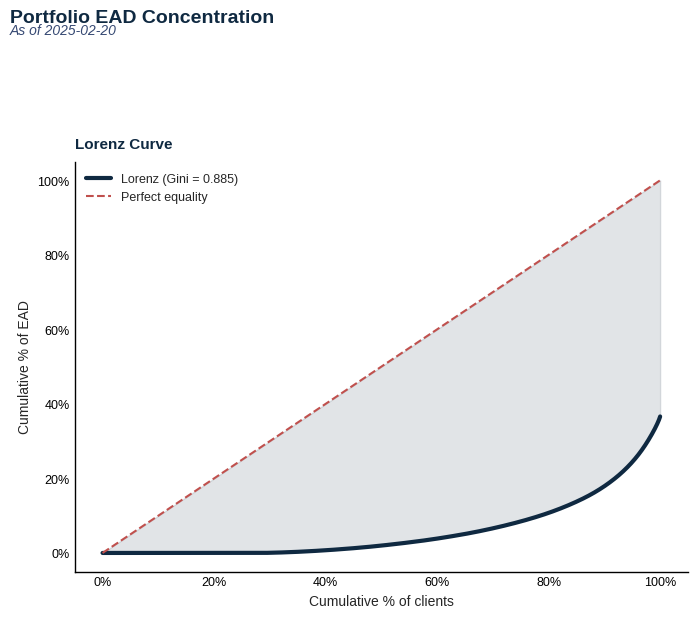

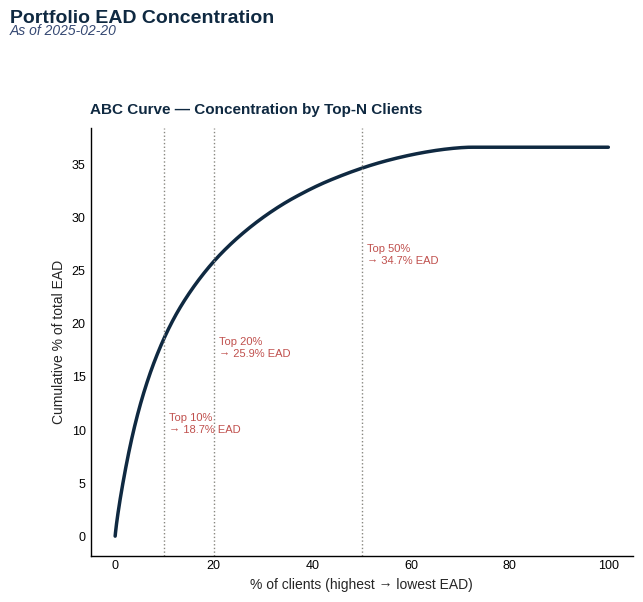

Gini index       : 0.885  (high concentration)
Total clients    : 210,696


In [43]:
# Concentration & Dispersion - Gini, Lorenz Curve, and ABC Curve
# (agora em duas figuras independentes)

"""
The Gini index measures the degree of EAD concentration in the portfolio.
A Gini near 1 -> few clients concentrate most of the risk.
A Gini near 0 -> risk is well distributed across all borrowers.

The Lorenz Curve is the visual representation of the Gini.
The ABC Curve complements it: it shows what % of total EAD the most exposed clients represent.

Since this analysis is a static snapshot of Exposure (EAD), it is immune to the
payment-data timing gap (Feb/2025 cutoff). Outstanding balance remains the sum
of installments open, whether overdue or not.
"""

# Aggregate EAD by client - a client can have multiple contracts
risco_cliente = (
    ead_por_contrato
    .merge(dados[['id_contrato', 'id_cliente']].drop_duplicates(), on='id_contrato', how='left')
    .groupby('id_cliente')
    .agg(ead_total=('ead', 'sum'))
    .reset_index()
    .sort_values('ead_total', ascending=False)
)

# Lorenz - uses EAD_TOTAL from Stage 2 for consistency
y_values   = np.sort(risco_cliente['ead_total'].values)
y_cum      = np.cumsum(y_values) / EAD_TOTAL
x_values   = np.linspace(0, 1, len(y_values))
gini_index = 1 - 2 * np.trapz(y_cum, x_values)

# ABC Curve data prep
risco_sorted = risco_cliente.sort_values('ead_total', ascending=False).reset_index(drop=True)
risco_sorted['rank_pct']    = (risco_sorted.index + 1) / len(risco_sorted)
risco_sorted['cum_ead_pct'] = risco_sorted['ead_total'].cumsum() / EAD_TOTAL

# ── FIGURA 1: Lorenz Curve ────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 6.2))
add_fig_title_block(fig1, 'Portfolio EAD Concentration', f'As of {DATA_REF.date()}')

ax1.plot(x_values, y_cum, label=f'Lorenz (Gini = {gini_index:.3f})', color=PALETTE["navy_dark"], lw=3)
ax1.plot([0, 1], [0, 1], '--', color=PALETTE["alert_red"], lw=1.5, label='Perfect equality')
ax1.fill_between(x_values, y_cum, x_values, alpha=0.12, color=PALETTE["navy_dark"])
add_title_block(ax1, 'Lorenz Curve', fontsize_title=11, pad=10)
ax1.set_xlabel('Cumulative % of clients', fontsize=10)
ax1.set_ylabel('Cumulative % of EAD', fontsize=10)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.legend(fontsize=9, frameon=False)
style_axes(ax1)

fig1.tight_layout(rect=[0, 0, 1, 0.86])   # reserva os 14% superiores para o bloco de título
fig1.savefig('lorenz_curve.png', dpi=200, bbox_inches='tight')  # rede de segurança extra
plt.show()

# ── FIGURA 2: ABC Curve ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 6.2))
add_fig_title_block(fig2, 'Portfolio EAD Concentration', f'As of {DATA_REF.date()}')

ax2.plot(risco_sorted['rank_pct'] * 100, risco_sorted['cum_ead_pct'] * 100,
         color=PALETTE["navy_dark"], lw=2.5)
for pct in [10, 20, 50]:
    mask = risco_sorted[risco_sorted['rank_pct'] <= pct / 100]
    if len(mask):
        cum_val = mask.iloc[-1]['cum_ead_pct'] * 100
        ax2.axvline(pct, color=PALETTE["muted_grey"], linestyle=':', lw=1)
        ax2.annotate(f'Top {pct}%\n\u2192 {cum_val:.1f}% EAD',
                     xy=(pct, cum_val), xytext=(pct + 1, cum_val - 9),
                     fontsize=8, color=PALETTE["alert_red"])
add_title_block(ax2, 'ABC Curve \u2014 Concentration by Top-N Clients', fontsize_title=11, pad=10)
ax2.set_xlabel('% of clients (highest \u2192 lowest EAD)', fontsize=10)
ax2.set_ylabel('Cumulative % of total EAD', fontsize=10)
style_axes(ax2)

plt.subplots_adjust(top=0.80)
plt.show()

# Console output
print(f"Gini index       : {gini_index:.3f}  "
      f"{'(high concentration)' if gini_index > 0.5 else '(moderate concentration)'}")
print(f"Total clients    : {len(risco_cliente):,}")


## Etapa 4 — Early risk

- Falha de underwriting
- Early Warning Signals — FPD, SPD e TPD por Safra
- Matriz de Risco — Faixas de Juros vs. NPL

In [44]:
# Diagnóstico Matemático de Early Risk (Falha de Underwriting)

# Definimos o mês de análise para "Early Risk" (Mês 3 após originação)

IDADE_ANALISE = 3

# Extraímos apenas as taxas de default no Mês 3 para todas as safras que chegaram até lá

taxas_mes_3 = vintage_matrix_segura.loc[:, IDADE_ANALISE].dropna()

# Encontramos a safra com a pior performance nesse período crítico

safra_critica = taxas_mes_3.idxmax()
taxa_pior_safra = taxas_mes_3.max()
taxa_media_historica = taxas_mes_3.mean()

# Calcula o quanto a pior safra descolou da média

descolamento = (taxa_pior_safra / taxa_media_historica) - 1

print("\n" + "="*70)
print(" DIAGNÓSTICO DE ORIGINAÇÃO (UNDERWRITING) — EARLY RISK")
print("="*70)
print(f"➜ Safra mais crítica identificada : {safra_critica}")
print(f"➜ Default no Mês {IDADE_ANALISE} desta safra : {taxa_pior_safra:.2%}")
print(f"➜ Média histórica no Mês {IDADE_ANALISE}     : {taxa_media_historica:.2%}")
print(f"\nCONCLUSÃO: A safra de {safra_critica} apresentou um volume de quebra {descolamento:.1%} superior")
print("à média histórica nos primeiros meses. Isso é um forte indício de")
print("relaxamento nas políticas de aprovação (underwriting) neste período específico.\n")


 DIAGNÓSTICO DE ORIGINAÇÃO (UNDERWRITING) — EARLY RISK
➜ Safra mais crítica identificada : 2023-02
➜ Default no Mês 3 desta safra : 0.77%
➜ Média histórica no Mês 3     : 0.35%

CONCLUSÃO: A safra de 2023-02 apresentou um volume de quebra 121.6% superior
à média histórica nos primeiros meses. Isso é um forte indício de
relaxamento nas políticas de aprovação (underwriting) neste período específico.



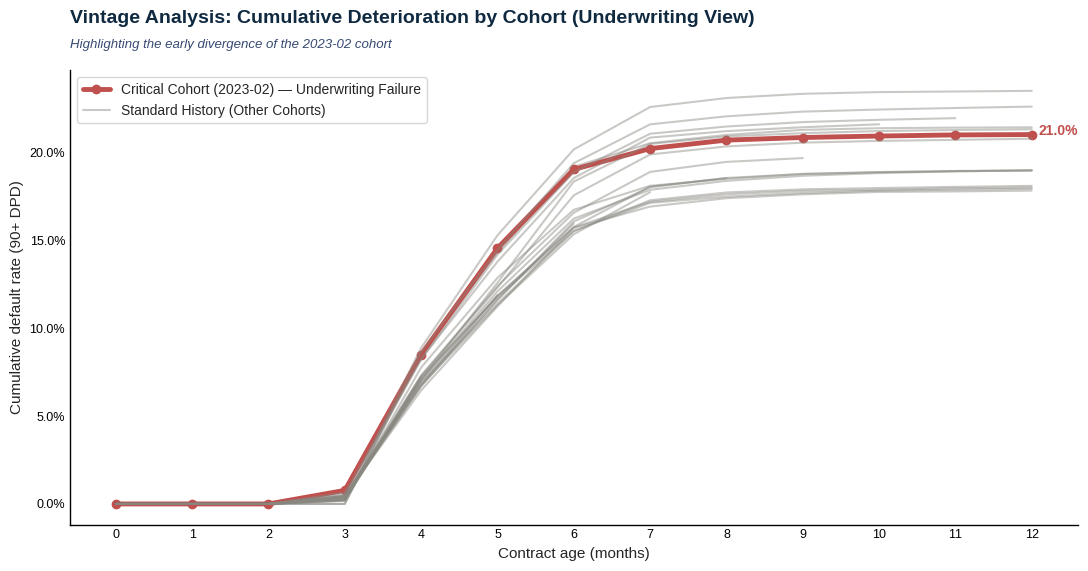

In [45]:
# Default Speed - Storytelling View (Underwriting Failure Highlight)

"""
The chart below zooms into the first 12 months of each cohort's life.
Cutoff correction: the base has a payment-data cutoff at 2025-02-20.
To avoid the "false default" created by future installments with no charge-off,
the matrix is truncated to ignore any break event after Jan/2025.
"""

MESES_MATURACAO_MIN = 4   # only evaluate cohorts with at least 4 months of real history

fig, ax = plt.subplots(figsize=(13, 6.4))

for cohort in vintage_matrix_segura.index:
    serie = vintage_matrix_segura.loc[cohort, :JANELA_EARLY].dropna()
    if len(serie) < MESES_MATURACAO_MIN:
        continue
    if cohort == safra_critica:
        ax.plot(serie.index, serie.values,
                label=f'Critical Cohort ({cohort}) \u2014 Underwriting Failure',
                color=PALETTE["alert_red"], alpha=1.0, lw=3.5, marker='o', markersize=6)
        x_final = serie.index[-1]
        y_final = serie.values[-1]
        ax.annotate(f"{y_final:.1%}", xy=(x_final, y_final),
                    xytext=(5, 0), textcoords="offset points",
                    color=PALETTE["alert_red"], fontweight='bold', fontsize=10)
    else:
        ax.plot(serie.index, serie.values,
                color=PALETTE["muted_grey"], alpha=0.45, lw=1.5, marker='', label='_nolegend_')

add_title_block(
    ax, 'Vintage Analysis: Cumulative Deterioration by Cohort (Underwriting View)',
    f'Highlighting the early divergence of the {safra_critica} cohort', fontsize_title=14, pad=34
)
ax.set_xlabel('Contract age (months)', fontsize=11)
ax.set_ylabel('Cumulative default rate (90+ DPD)', fontsize=11)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

linha_cinza = mlines.Line2D([], [], color=PALETTE["muted_grey"], marker='', lw=1.5, alpha=0.45,
                            label='Standard History (Other Cohorts)')
handles, labels = ax.get_legend_handles_labels()
handles.append(linha_cinza)

ax.legend(handles=handles, loc='upper left', fontsize=10, frameon=True, shadow=False)
style_axes(ax)

plt.subplots_adjust(top=0.82)
plt.show()


In [46]:
# Early Warning Signals — FPD, SPD e TPD por Safra

"""
Os Early Warning Signals formam o funil de early risk: detectam falhas de originação
antes que elas apareçam no NPL formal.

- FPD (First Payment Default): contrato que não pagou a 1ª parcela.
- SPD (Second Payment Default): pagou a 1ª mas falhou na 2ª.
- TPD (Third Payment Default): falhou na 3ª mas estava adimplente nas duas primeiras.

* Para que a safra tenha o funil completo (3 parcelas avaliadas),
ela precisa de 3 meses de maturação antes do apagão de dados (20/02/2025).
Safras posteriores a Nov/2024 são omitidas para evitar Falsos Defaults.

"""

# Blindagem de Safra (Última safra que conseguiu maturar 3 meses antes do apagão)

MAX_COHORT_EWS = (DATA_CORTE_PAGAMENTOS - pd.DateOffset(months=3)).to_period('M')

# Filtra parcelas 2 e 3 a partir de df_vint

early_risk = df_vint[df_vint['parcela'].isin([2, 3])].copy()
early_risk['is_bad'] = (
    (early_risk['status_parcela'] == 'vencida sem pagamento') |
    (early_risk['dias_atraso'] > 30)
)

# pivot_table robusto a eventuais duplicatas de (id_contrato, parcela)

early_risk_piv = (
    early_risk
    .pivot_table(index='id_contrato', columns='parcela', values='is_bad', aggfunc='max')
    .reset_index()
    .rename(columns={2: 'bad_p2', 3: 'bad_p3'})
)

# Garante que as colunas existam mesmo para contratos sem parcelas 2 ou 3

for col in ['bad_p2', 'bad_p3']:
    if col not in early_risk_piv.columns:
        early_risk_piv[col] = False

# Junta com FPD flag e cohort

df_ews = (
    df_vint[['id_contrato', 'cohort', 'fpd_flag']]
    .drop_duplicates()
    .merge(early_risk_piv, on='id_contrato', how='left')
    .fillna(False)
)

# Remove as safras "cegas" que não amadureceram 3 meses (Blindagem)

df_ews = df_ews[df_ews['cohort'] <= MAX_COHORT_EWS]

# SPD: falhou na parcela 2, mas NÃO estava já em FPD

df_ews['spd_flag'] = df_ews['bad_p2'] & ~df_ews['fpd_flag']

# TPD: falhou na parcela 3, mas NÃO estava em FPD nem em SPD

df_ews['tpd_flag'] = df_ews['bad_p3'] & ~df_ews['fpd_flag'] & ~df_ews['bad_p2']

# Agrega pelas safras válidas

ews_agg = (
    df_ews
    .groupby('cohort')
    .agg(
        total = ('id_contrato', 'count'),
        fpd   = ('fpd_flag',   'sum'),
        spd   = ('spd_flag',   'sum'),
        tpd   = ('tpd_flag',   'sum'),
    )
    .reset_index()
)
ews_agg['FPD %']         = ews_agg['fpd'] / ews_agg['total']
ews_agg['SPD %']         = ews_agg['spd'] / ews_agg['total']
ews_agg['TPD %']         = ews_agg['tpd'] / ews_agg['total']
ews_agg['FPD+SPD+TPD %'] = (ews_agg['fpd'] + ews_agg['spd'] + ews_agg['tpd']) / ews_agg['total']

# Print da Tabela Completa

display(
    ews_agg[['cohort', 'total', 'FPD %', 'SPD %', 'TPD %', 'FPD+SPD+TPD %']]
    .style
    .format({
        'total'          : '{:,}',
        'FPD %'          : '{:.1%}',
        'SPD %'          : '{:.1%}',
        'TPD %'          : '{:.1%}',
        'FPD+SPD+TPD %'  : '{:.1%}',
    })
    .background_gradient(subset=['FPD %', 'SPD %', 'TPD %', 'FPD+SPD+TPD %'], cmap='YlOrRd')
    .set_caption(
        f"Early Warning Signals por Safra Completa  |  Válidas até {MAX_COHORT_EWS}"
    )
    .hide(axis='index')
)



/tmp/ipykernel_2169/4003598216.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


cohort,total,FPD %,SPD %,TPD %,FPD+SPD+TPD %
2023-01,"15,703",10.9%,7.6%,6.0%,24.5%
2023-02,"15,570",11.2%,7.3%,6.2%,24.7%
2023-03,"17,444",9.7%,6.4%,5.2%,21.4%
2023-04,"19,046",8.9%,6.1%,5.3%,20.2%
2023-05,"24,195",8.9%,6.0%,5.5%,20.4%
2023-06,"23,999",8.0%,6.5%,5.9%,20.3%
2023-07,"25,651",9.0%,6.7%,5.3%,21.1%
2023-08,"30,548",9.0%,6.4%,5.5%,20.9%
2023-09,"32,329",8.6%,6.2%,5.4%,20.1%
2023-10,"37,622",8.9%,6.1%,6.7%,21.7%


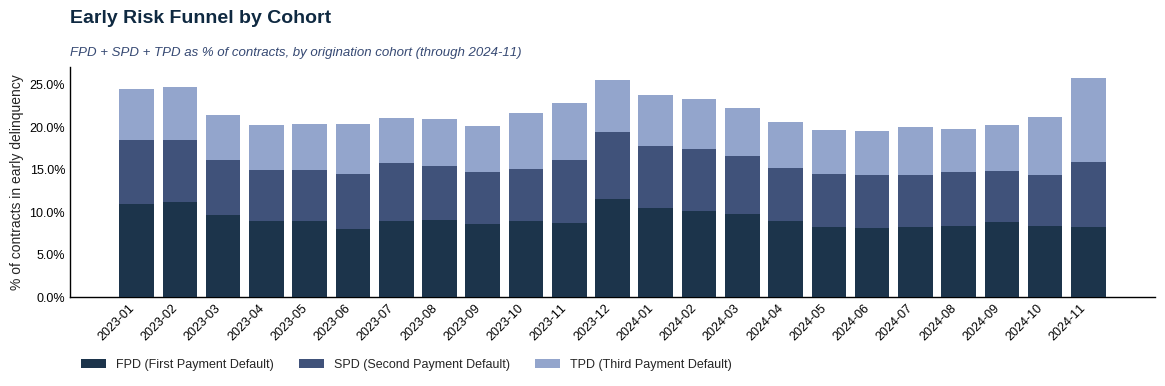

In [47]:
# Chart: Early Risk Funnel by Cohort - FPD + SPD + TPD
# (No gridlines; axis lines/ticks/labels black; house navy/blue palette)

fig, ax = plt.subplots(figsize=(14, 4.6))

x_labels = ews_agg['cohort'].astype(str)
x_pos    = range(len(x_labels))

ax.bar(x_pos, ews_agg['FPD %'], label='FPD (First Payment Default)',
       color=PALETTE["navy_dark"], alpha=0.95, zorder=3)
ax.bar(x_pos, ews_agg['SPD %'], bottom=ews_agg['FPD %'],
       label='SPD (Second Payment Default)', color=PALETTE["navy_mid"], alpha=0.95, zorder=3)
ax.bar(x_pos, ews_agg['TPD %'], bottom=ews_agg['FPD %'] + ews_agg['SPD %'],
       label='TPD (Third Payment Default)', color=PALETTE["blue_light"], alpha=0.95, zorder=3)

ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

add_title_block(ax, 'Early Risk Funnel by Cohort',
                 f'FPD + SPD + TPD as % of contracts, by origination cohort (through {MAX_COHORT_EWS})',
                 fontsize_title=14, pad=32)

ax.set_ylabel('% of contracts in early delinquency', fontsize=10)

ax.legend(fontsize=9, frameon=False, loc='upper left', bbox_to_anchor=(0, -0.22), ncol=3)
style_axes(ax)

plt.subplots_adjust(top=0.82, bottom=0.32)
plt.show()


In [48]:
# Matriz de Risco — Faixas de Juros vs. NPL

"""
Uma das perguntas centrais de qualquer due diligence: o pricing compensa o risco?
Contratos com juros mais altos deveriam ter maior spread para absorver perdas maiores.

1. As faixas de juros (quartis) são definidas por CONTRATO (evitando viés de contratos longos).
2. O NPL Financeiro é calculado sobre o EAD (Exposure at Default) congelado na data
   do apagão de pagamentos (20/02/2025) para evitar falsos defaults.
"""

# Define os quartis de juros baseados em CONTRATOS únicos (1 linha por contrato)

DATA_CORTE_PAGAMENTOS = pd.Timestamp('2025-02-20')

df_juros = dados.groupby('id_contrato').agg(juros=('juros', 'first')).reset_index()
df_juros['faixa_juros'] = pd.qcut(df_juros['juros'], 4, duplicates='drop')

# Calcula EAD e NPL real no dia do apagão, isolando as parcelas que não tinham pagamento na data do apagão

mask_aberto = dados['valor_pago'].isna() | (dados['valor_pago'] <= 0)
df_aberto   = dados[mask_aberto].copy()

# Calcula quantos dias de atraso a parcela tinha exatamente no dia 20/02/2025

df_aberto['dias_atraso_real'] = (
    DATA_CORTE_PAGAMENTOS - df_aberto['vencimento']
).dt.days

# Se o atraso real for > 90 dias, o valor compõe o NPL 90+

df_aberto['valor_npl'] = np.where(
    df_aberto['dias_atraso_real'] > 90,
    df_aberto['valor_parcela'],
    0
)

# Agrega a exposição financeira por contrato

exposicao_contrato = df_aberto.groupby('id_contrato').agg(
    ead   = ('valor_parcela', 'sum'),
    npl_90= ('valor_npl',    'sum')
).reset_index()

# Preenchemos com 0 apenas as colunas de valores, protegendo a coluna 'faixa_juros'

df_risk = df_juros.merge(exposicao_contrato, on='id_contrato', how='left')

df_risk['ead'] = df_risk['ead'].fillna(0)
df_risk['npl_90'] = df_risk['npl_90'].fillna(0)

# Calcula o EAD total da carteira para saber a concentração de cada faixa

ead_total_carteira = df_risk['ead'].sum()

risk_matrix = (
    df_risk
    .groupby('faixa_juros', observed=True)
    .agg(
        Contratos = ('id_contrato', 'nunique'),
        EAD_Faixa = ('ead', 'sum'),
        NPL_Faixa = ('npl_90', 'sum')
    )
    .reset_index()
)

# Calcula os indicadores finais

risk_matrix['% da Carteira (EAD)'] = risk_matrix['EAD_Faixa'] / ead_total_carteira
risk_matrix['NPL Ratio (R$)']      = risk_matrix['NPL_Faixa'] / risk_matrix['EAD_Faixa']

# Ajustes visuais e formatação

risk_matrix = risk_matrix.rename(columns={
    'faixa_juros': 'Faixa de Juros (a.m.)',
    'EAD_Faixa'  : 'EAD Total (R$)',
    'NPL_Faixa'  : 'Saldo NPL 90+ (R$)'
})

display(
    risk_matrix
    .style
    .format({
        'Contratos'          : '{:,}',
        'EAD Total (R$)'     : 'R$ {:,.2f}',
        'Saldo NPL 90+ (R$)' : 'R$ {:,.2f}',
        '% da Carteira (EAD)': '{:.1%}',
        'NPL Ratio (R$)   '  : '{:.2%}',
    })
    .background_gradient(subset=['NPL Ratio (R$)'], cmap='Reds')
    .background_gradient(subset=['% da Carteira (EAD)'], cmap='Blues')
    .hide(axis='index')
    .set_caption(f"Matriz de Risco — Juros vs. NPL  |  Ref: {DATA_CORTE_PAGAMENTOS.date()}")
)

Faixa de Juros (a.m.),Contratos,EAD Total (R$),Saldo NPL 90+ (R$),% da Carteira (EAD),NPL Ratio (R$)
"(0.019, 0.09]","561,878","R$ 52,335,938.46","R$ 15,955,677.41",53.4%,0.304870
"(0.09, 0.13]","438,841","R$ 43,521,195.61","R$ 9,435,745.22",44.4%,0.216808
"(0.13, 0.26]","32,213","R$ 2,133,503.75","R$ 731,232.02",2.2%,0.342738


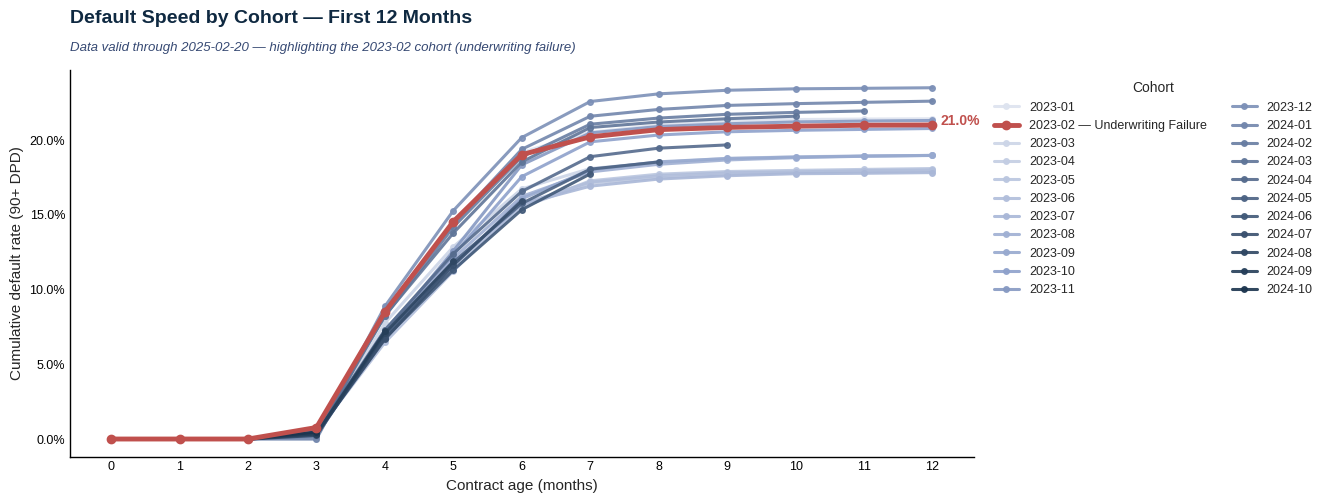

In [49]:
# Default Speed by Cohort - First 12 Months (Underwriting Failure Highlighted)

fig, ax = plt.subplots(figsize=(13, 5.6))

n_cohorts = len(vintage_matrix_segura.index)
cores     = HOUSE_CMAP(np.linspace(0.15, 0.95, n_cohorts))   # navy -> light-blue gradient (house palette)

for i, cohort in enumerate(vintage_matrix_segura.index):
    serie = vintage_matrix_segura.loc[cohort, :JANELA_EARLY].dropna()
    if len(serie) < 2:      # skip very recent cohorts with under 2 months of maturation
        continue

    if cohort == safra_critica:
        ax.plot(serie.index, serie.values, label=f'{cohort} \u2014 Underwriting Failure',
                color=PALETTE["alert_red"], alpha=1.0, lw=3.5, marker='o', markersize=6, zorder=5)
        x_final, y_final = serie.index[-1], serie.values[-1]
        ax.annotate(f"{y_final:.1%}", xy=(x_final, y_final),
                    xytext=(6, 0), textcoords="offset points",
                    color=PALETTE["alert_red"], fontweight='bold', fontsize=10)
    else:
        ax.plot(serie.index, serie.values, label=str(cohort), color=cores[i],
                alpha=0.9, lw=2.2, marker='o', markersize=4)

add_title_block(
    ax, f'Default Speed by Cohort \u2014 First {JANELA_EARLY} Months',
    f'Data valid through {DATA_CORTE_PAGAMENTOS.date()} \u2014 highlighting the {safra_critica} cohort (underwriting failure)',
    fontsize_title=14, pad=34
)
ax.set_xlabel('Contract age (months)', fontsize=11)
ax.set_ylabel('Cumulative default rate (90+ DPD)', fontsize=11)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, ncol=2, frameon=False)
style_axes(ax)

plt.subplots_adjust(top=0.80, right=0.82)
plt.show()

## Etapa 5 — Dinâmica (roll rates)


Como os contratos migram entre estados ao longo do tempo:
- **Roll rates:** matriz de transição entre buckets de DPD (mês a mês)
- **Cure rate:** % de contratos que saem de um bucket de atraso e voltam à adimplência
- Estrutura de buckets: 0 / 1–30 / 31–60 / 61–90 / 90+ DPD

In [50]:
# Roll Rate & Cure Rate — Matriz de Transição entre Buckets de DPD

"""
A Roll Rate mede a probabilidade de um contrato migrar de um bucket de atraso para outro no mês seguinte.
Uma roll rate de 40% de 61-90 DPD para 90+ DPD significa que 40% dos contratos nesse bucket
vão formalizar o default no período seguinte — sinal de alerta precoce semanas antes das perdas aparecerem.

O Cure Rate é o complemento: a probabilidade de um contrato retornar à adimplência (em dia)
a partir de cada bucket. Cure rates baixas em buckets avançados confirmam que, uma vez em 60+,
a probabilidade de recuperação sem ação ativa de cobrança é muito baixa.

"""

# Configuração de corte definidas na Etapa 3

DATA_CORTE_PAGAMENTOS = DATA_REF
MES_CORTE = DATA_CORTE_PAGAMENTOS.to_period('M')

# CORREÇÃO DO ERRO: Criando o mes_ref (mês de vencimento) que a Roll Rate exige

if 'mes_ref' not in df_vint.columns:
    df_vint['mes_ref'] = df_vint['vencimento'].dt.to_period('M')

# Filtramos APENAS os meses onde sabemos que existem pagamentos (<= MES_CORTE)

status_mensal = (
    df_vint[df_vint['mes_ref'] <= MES_CORTE]
    .groupby(['id_contrato', 'mes_ref'])['flag_atraso']
    .last()
    .reset_index()
)

# Cria o período seguinte para fazer o merge de transição mês a mês

status_mensal['mes_prox'] = status_mensal['mes_ref'] + 1

# Junta o status de t com o status de t+1 para cada contrato

transicao = status_mensal.merge(
    status_mensal,
    left_on  = ['id_contrato', 'mes_prox'],
    right_on = ['id_contrato', 'mes_ref'],
    suffixes = ('_t', '_t1')
)

# Matriz de transição normalizada por linha (probabilidades condicionais)

roll_matrix = (
    pd.crosstab(
        transicao['flag_atraso_t'],
        transicao['flag_atraso_t1'],
        normalize='index'
    )
    .reindex(index=ORDEM_BUCKET, columns=ORDEM_BUCKET)
    .fillna(0)
)

display(
    roll_matrix
    .style
    .format('{:.1%}')
    .background_gradient(cmap='Blues', axis=1)
    .set_caption(f"Roll Rate — Matriz de Transição Mensal  |  Dados válidos até {MES_CORTE}")
)



flag_atraso_t1,em dia,1-30 DPD,31-60 DPD,61-90 DPD,90+ DPD
flag_atraso_t,,,,,
em dia,80.7%,15.2%,0.9%,0.5%,2.7%
1-30 DPD,39.6%,48.4%,4.2%,1.6%,6.3%
31-60 DPD,3.8%,73.9%,8.3%,4.6%,9.3%
61-90 DPD,1.5%,2.6%,72.5%,7.8%,15.6%
90+ DPD,0.9%,0.0%,0.0%,9.1%,89.9%


In [51]:
# Cure Rate: probabilidade de retornar a 'em dia' a partir de cada bucket de atraso

cure_data = []
for bucket in ORDEM_BUCKET[1:]:             # exclui 'em dia' (não faz sentido curar de adimplente)
    cure = roll_matrix.loc[bucket, 'em dia'] if bucket in roll_matrix.index else 0
    roll = roll_matrix.loc[bucket, '90+ DPD'] if bucket in roll_matrix.index else 0
    cure_data.append({
        'Bucket Origem'          : bucket,
        'Cure Rate (→ Em Dia)'   : cure,
        'Roll Rate (→ 90+ DPD)'  : roll,
    })

cure_rate = pd.DataFrame(cure_data)
print("\n── Cure Rate e Roll Rate por Bucket ──")
display(
    cure_rate.style
    .format({
        'Cure Rate (→ Em Dia)'  : '{:.1%}',
        'Roll Rate (→ 90+ DPD)' : '{:.1%}',
    })
    .background_gradient(subset=['Cure Rate (→ Em Dia)'],  cmap='Greens')
    .background_gradient(subset=['Roll Rate (→ 90+ DPD)'], cmap='Reds')
    .hide(axis='index')
)


── Cure Rate e Roll Rate por Bucket ──


Bucket Origem,Cure Rate (→ Em Dia),Roll Rate (→ 90+ DPD)
1-30 DPD,39.6%,6.3%
31-60 DPD,3.8%,9.3%
61-90 DPD,1.5%,15.6%
90+ DPD,0.9%,89.9%


## Etapa 6 - LGD (Loss Given Default)


- **IAG (Indicador Ajustado ao Risco)**: mede a rentabilidade da carteira.
- **Expected Loss (EL)**: representa a perda estatisticamente esperada da carteira.
- **Spread e Margem Líquidos**: indicam o retorno efetivo das operações .
- **LGD (Loss Given Default)**: mede o percentual da exposição que efetivamente se perde após o default.
- **VPL das Safras**: mede o valor presente líquido das *cohorts* de originação ao longo do tempo.

In [52]:
# IAG — Índice de Atraso Geral e Decomposição por Bucket

"""
O IAG (Índice de Atraso Geral) é a razão entre o saldo total vencido e não pago
e o EAD total da carteira. Captura qualquer estágio de atraso (1 a 90+ DPD).

*Com a base parou de receber dados em 20/02/2025, o status de atraso das parcelas (calculado para 2026) está contaminado.
O código abaixo tira uma fotografia "congelada" do atraso exatamente no dia do apagão,
recalculando os buckets de DPD reais daquela data.
"""
# Definimo um data frame filtrado para as seguintes manipulções na etapa

df_contratos_unicos = dados.drop_duplicates('id_contrato')[
    ['id_contrato', 'juros', 'prazo', 'valor_financiado', 'data_originacao']
].copy()

df_atraso_blindado = df_aberto[
    df_aberto['vencimento'] <= DATA_CORTE_PAGAMENTOS
].copy()

# Reclassificando os buckets com a idade correta

def classifica_dpd_real(dias):
    if dias <= 0:    return 'em dia'        # Por segurança de borda
    elif dias <= 30: return '1-30 DPD'
    elif dias <= 60: return '31-60 DPD'
    elif dias <= 90: return '61-90 DPD'
    else:            return '90+ DPD'

df_atraso_blindado['bucket_real'] = (
    df_atraso_blindado['dias_atraso_real'].apply(classifica_dpd_real)
)

# Cálculos do IAG Global

atraso_total_rs = df_atraso_blindado['valor_parcela'].sum()
iag_global      = atraso_total_rs / EAD_TOTAL

print(f"── Fotografia do Atraso Congelada em: {DATA_CORTE_PAGAMENTOS.date()} ──")
print(f"Saldo em atraso (todas as faixas) : R$ {atraso_total_rs:,.2f}")
print(f"EAD Total da Carteira             : R$ {EAD_TOTAL:,.2f}")
print(f"IAG Global                        : {iag_global:.2%}\n")

# Decomposição do IAG por bucket real

iag_por_bucket = (
    df_atraso_blindado
    .groupby('bucket_real')['valor_parcela']
    .sum()
    .reindex(ORDEM_BUCKET[1:]) # Ignora o 'em dia' (Queremos só os 4 buckets de atraso)
    .fillna(0)
    .reset_index()
    .rename(columns={
        'bucket_real'  : 'Bucket',
        'valor_parcela': 'Saldo Vencido (R$)'
    })
)

iag_por_bucket['% do EAD']          = iag_por_bucket['Saldo Vencido (R$)'] / EAD_TOTAL
iag_por_bucket['% do Atraso Total'] = iag_por_bucket['Saldo Vencido (R$)'] / atraso_total_rs

display(
    iag_por_bucket.style
    .format({
        'Saldo Vencido (R$)'  : 'R$ {:,.2f}',
        '% do EAD'            : '{:.2%}',
        '% do Atraso Total'   : '{:.1%}',
    })
    .background_gradient(subset=['% do EAD'], cmap='Reds')
    .hide(axis='index')
    .set_caption(f"Decomposição do IAG por Bucket de DPD  |  Ref: {DATA_CORTE_PAGAMENTOS.date()}")
)

── Fotografia do Atraso Congelada em: 2025-02-20 ──
Saldo em atraso (todas as faixas) : R$ 36,702,016.79
EAD Total da Carteira             : R$ 267,523,005.40
IAG Global                        : 13.72%



Bucket,Saldo Vencido (R$),% do EAD,% do Atraso Total
1-30 DPD,"R$ 4,762,276.96",1.78%,13.0%
31-60 DPD,"R$ 2,975,885.32",1.11%,8.1%
61-90 DPD,"R$ 2,424,174.52",0.91%,6.6%
90+ DPD,"R$ 26,122,654.65",9.76%,71.2%


In [53]:
# Expected Loss (EL) — Cálculo Final de Perda Esperada

"""
A Expected Loss é o número central de qualquer processo de precificação ou cessão.

- PD (Probability of Default): estimada como a mediana das taxas máximas de default por safra.
- LGD (Loss Given Default): 1 − recovery_rate médio.
- EAD (Exposure at Default): saldo total de parcelas não pagas.

"""

# PD Empírica

# Garante que a matriz segura está na memória caso o bloco 3.1.2 não tenha rodado

if 'vintage_matrix_segura' not in globals():
    print("Aviso: recriando vintage_matrix_segura para proteger a PD...")
    vintage_matrix_segura = vintage_matrix.copy()
    for cohort in vintage_matrix_segura.index:
        for age in vintage_matrix_segura.columns:
            if cohort + age >= MES_CORTE:
                vintage_matrix_segura.loc[cohort, age] = np.nan

# Aplica ffill() apenas nas datas válidas e pega o teto real de quebra de cada safra

pd_empirica = vintage_matrix_segura.ffill(axis=1).max(axis=1).median()

# LGD Empírica

if 'recovery_rate' in dados.columns:
    recovery_medio = dados['recovery_rate'].dropna().mean()
else:
    recovery_medio = float('nan')

if not np.isnan(recovery_medio):
    lgd_empirica = 1 - recovery_medio
    fonte_lgd    = f"1 − recovery médio observado ({recovery_medio:.1%})"
else:
    lgd_empirica = 0.65
    fonte_lgd    = "padrão de mercado — sem recovery suficiente observado"

# O EAD_TOTAL é seguro, pois EAD é a soma estática da exposição viva

total_ead_carteira = EAD_TOTAL
expected_loss      = pd_empirica * lgd_empirica * total_ead_carteira
el_pct_ead         = expected_loss / total_ead_carteira

# Output

print("══════════════════════════════════════════════════════════")
print("  EXPECTED LOSS — Componentes e Resultado (Visão Realista)")
print("══════════════════════════════════════════════════════════")
print(f"  PD Empírica (mediana do máx real/safra): {pd_empirica:.2%}")
print(f"  LGD Empírica  [{fonte_lgd}]")
print(f"    → LGD utilizada                      : {lgd_empirica:.2%}")
print(f"  EAD Total da Carteira                  : R$ {total_ead_carteira:,.2f}")
print("──────────────────────────────────────────────────────────")
print(f"  EXPECTED LOSS (EL) TOTAL               : R$ {expected_loss:,.2f}")
print(f"  EL como % do EAD                       : {el_pct_ead:.2%}")
print("══════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════
  EXPECTED LOSS — Componentes e Resultado (Visão Realista)
══════════════════════════════════════════════════════════
  PD Empírica (mediana do máx real/safra): 19.01%
  LGD Empírica  [1 − recovery médio observado (39.4%)]
    → LGD utilizada                      : 60.63%
  EAD Total da Carteira                  : R$ 267,523,005.40
──────────────────────────────────────────────────────────
  EXPECTED LOSS (EL) TOTAL               : R$ 30,840,460.15
  EL como % do EAD                       : 11.53%
══════════════════════════════════════════════════════════


In [54]:
# Margem Ajustada ao Risco

"""
A pergunta final do investidor: após pagar as perdas (Expected Loss) e o
custo do capital (Funding), quanto sobra de lucro real para cada real emprestado?

Nesta etapa, cruzamos:
- Yield Bruto: A taxa de juros mediana que a fintech cobra.
- Expected Loss (EL %): O risco de crédito que já calculamos ser de 10.39%.
- Cost of Funding: O custo para captar esse dinheiro no mercado.
"""

# Recuperando a Taxa Média (Yield) da carteira calculada

df_yield = df_contratos_unicos[['id_contrato', 'juros']].merge(
    ead_por_contrato[['id_contrato', 'ead']], on='id_contrato', how='left'
)
yield_medio_mensal = (df_yield['juros'] * df_yield['ead']).sum() / df_yield['ead'].sum()
yield_anual_bruto = (1 + yield_medio_mensal)**12 - 1

# Premissa de Custo de Funding (Custo do Capital), como padrão de mercado para
# fintechs deste porte, assumiremos CDI + Spread = 14%

cost_of_funding_anual = 0.14

# Cálculo da Margem Líquida (Risk-Adjusted Margin), recuperamos o el_pct_ead (10.39%)

perda_esperada_pct = el_pct_ead

prazo_medio_meses = df_contratos_unicos['prazo'].median()
prazo_medio_anos  = prazo_medio_meses / 12

el_pct_anualizado = el_pct_ead / prazo_medio_anos  # distribui a perda pelo período médio

spread_liquida_anual = yield_anual_bruto - el_pct_anualizado - cost_of_funding_anual

# Cálculo da Margem líquida anual
# Transformar as taxas percentuais em valores financeiros (R$)

receita_bruta_r = EAD_TOTAL * yield_anual_bruto
custo_funding_r = EAD_TOTAL * cost_of_funding_anual
perda_esperada_r = EAD_TOTAL * el_pct_ead

# Calcular o Lucro Líquido Estimado

lucro_liquido_r = receita_bruta_r - perda_esperada_r - custo_funding_r

# Calcular a Margem Líquida Real (Esta nunca passará de 100%)

margem_liquida_real = (lucro_liquido_r / receita_bruta_r) * 100

print("══════════════════════════════════════════════════════════")
print("  ANÁLISE DE RENTABILIDADE (RISK-ADJUSTED)")
print("══════════════════════════════════════════════════════════")
print(f"  Yield Bruto da Carteira (a.a.)     : {yield_anual_bruto:.2%}")
print(f"  (-) Expected Loss (Risco)          : -{perda_esperada_pct:.2%}")
print(f"  (-) Custo de Funding (Estimado)    : -{cost_of_funding_anual:.2%}")
print("──────────────────────────────────────────────────────────")
print(f"  SPREAD LÍQUIDA FINAL (Net Spread)  : {spread_liquida_anual:.2%}")
print(f"  Lucro Líquido Estimado (R$)        : {lucro_liquido_r:,.2f}")
print(f"  Margem Líquida Real (R$)           : {margem_liquida_real:.2f}%")
print("══════════════════════════════════════════════════════════")

# Veredito Executivo

if spread_liquida_anual > 0.10:
    print("STATUS: OPERAÇÃO ALTAMENTE RENTÁVEL. O spread suporta o risco com folga.")
elif spread_liquida_anual > 0:
    print("STATUS: OPERAÇÃO EM EQUILÍBRIO. Margem apertada; requer escala para lucro real.")
else:
    print("STATUS: OPERAÇÃO DEFICITÁRIA. O risco e o funding consomem toda a receita.")

══════════════════════════════════════════════════════════
  ANÁLISE DE RENTABILIDADE (RISK-ADJUSTED)
══════════════════════════════════════════════════════════
  Yield Bruto da Carteira (a.a.)     : 224.05%
  (-) Expected Loss (Risco)          : -11.53%
  (-) Custo de Funding (Estimado)    : -14.00%
──────────────────────────────────────────────────────────
  SPREAD LÍQUIDA FINAL (Net Spread)  : 175.46%
  Lucro Líquido Estimado (R$)        : 531,081,051.72
  Margem Líquida Real (R$)           : 88.61%
══════════════════════════════════════════════════════════
STATUS: OPERAÇÃO ALTAMENTE RENTÁVEL. O spread suporta o risco com folga.


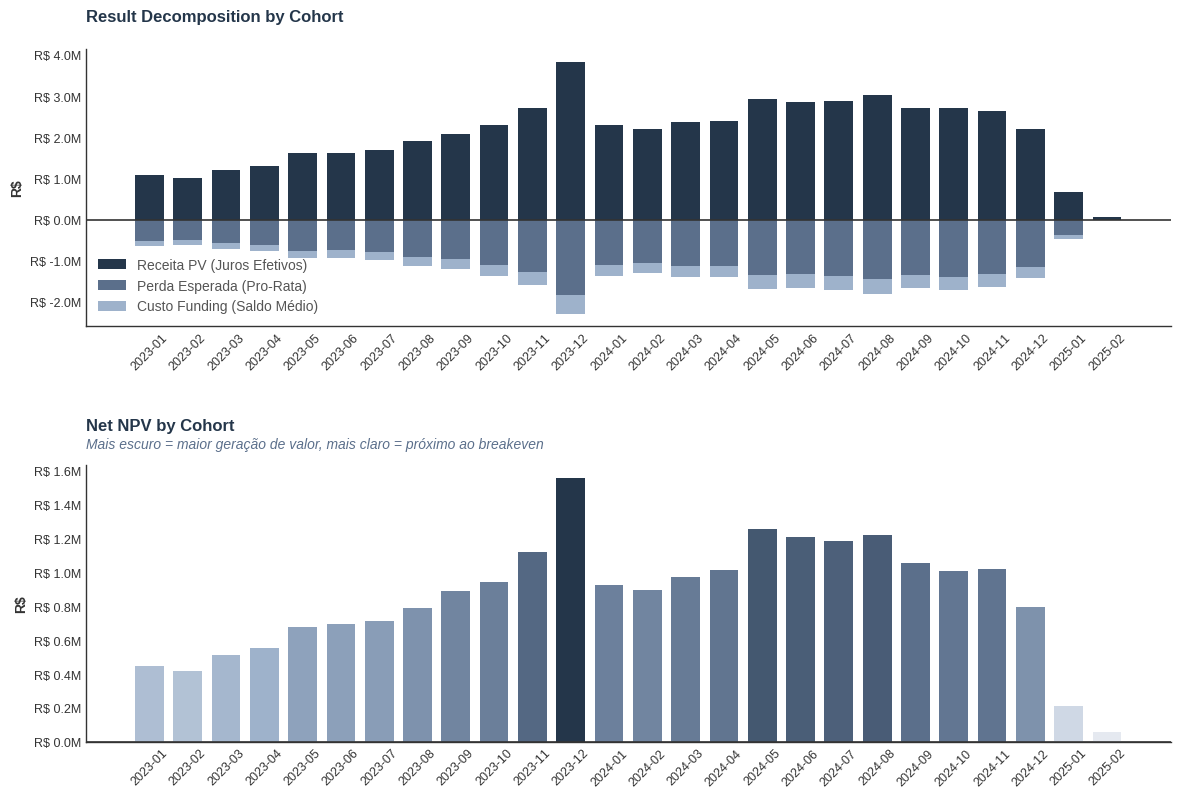


  Safras rentáveis até o momento : 26
  Safras em déficit até o momento: 0
  Safra com maior lucro gerado   : 2023-12 → R$ 1,559,785.22
  Safra mais pressionada         : 2025-02 → R$ 58,888.41


In [55]:
"""
Cohort NPV = PV of interest revenue - cost of funding - expected loss
If NPV > 0 -> the cohort is profitable even after risk and funding cost.
"""

# 1. Garantia das Variáveis Globais
DATA_REF = pd.Timestamp('2025-02-20')
cost_of_funding_anual = 0.14
TAXA_DESCONTO_MENSAL = (1 + cost_of_funding_anual) ** (1/12) - 1

# Recuperando premissas de risco
pd_empirica = 0.1901
lgd_empirica = 1 - 0.394

# 3. Base de Contratos (Trazendo a Margem Real do Contrato)
df_contratos_unicos = dados.drop_duplicates('id_contrato')[
    ['id_contrato', 'juros', 'prazo', 'valor_financiado', 'valor_parcela', 'data_originacao']
].copy()

# Cálculo da margem de juros embutida (Total a Pagar vs Financiado)
df_contratos_unicos['total_a_pagar'] = df_contratos_unicos['valor_parcela'] * df_contratos_unicos['prazo']
df_contratos_unicos['margem_juros'] = (df_contratos_unicos['total_a_pagar'] - df_contratos_unicos['valor_financiado']) / df_contratos_unicos['total_a_pagar']
df_contratos_unicos['margem_juros'] = df_contratos_unicos['margem_juros'].clip(lower=0).fillna(0)

# 4. Receita de Juros Realizada (Apenas parcelas pagas)
receita_por_safra = dados[dados['status_parcela'] == 'paga'].copy()
receita_por_safra = receita_por_safra.merge(df_contratos_unicos[['id_contrato', 'margem_juros']], on='id_contrato', how='left')
receita_por_safra['safra'] = receita_por_safra['data_originacao'].dt.to_period('M')

# A receita de juros é a proporção da margem sobre o valor efetivamente pago
receita_por_safra['receita_juros'] = receita_por_safra['valor_pago'] * receita_por_safra['margem_juros']

receita_por_safra['mes_vida'] = (
    (receita_por_safra['data_pagamento'].dt.to_period('M') -
     receita_por_safra['data_originacao'].dt.to_period('M'))
    .apply(lambda x: x.n if hasattr(x, 'n') else 0)
    .clip(lower=0)
)
receita_por_safra['fator_desconto'] = (1 + TAXA_DESCONTO_MENSAL) ** (-receita_por_safra['mes_vida'])
receita_por_safra['receita_pv'] = receita_por_safra['receita_juros'] * receita_por_safra['fator_desconto']
receita_safra = receita_por_safra.groupby('safra')['receita_pv'].sum()

# 5. Custos e Perdas (Correção Matemática: Amortização e Limite de Prazo)

df_idade = df_contratos_unicos.copy()
df_idade['safra'] = df_idade['data_originacao'].dt.to_period('M')

# Tempo total calendário

df_idade['meses_ate_corte'] = (pd.Timestamp(DATA_REF).to_period('M') - df_idade['safra']).apply(lambda x: x.n).clip(lower=0)
df_idade['meses_ativos'] = np.minimum(df_idade['meses_ate_corte'], df_idade['prazo'])
df_idade['saldo_medio_estimado'] = df_idade['valor_financiado'] * 0.55

# Fator tempo para diluir a Perda Esperada
df_idade['fator_tempo'] = (df_idade['meses_ate_corte'] / df_idade['prazo']).clip(upper=1.0)

# O Risco incide sobre o Capital Originado

df_idade['perda_pro_rata'] = df_idade['valor_financiado'] * (pd_empirica * lgd_empirica) * df_idade['fator_tempo']

# O Custo de Funding incide sobre o SALDO MÉDIO durante os MESES ATIVOS

df_idade['custo_funding_acumulado'] = df_idade['saldo_medio_estimado'] * ((1 + cost_of_funding_anual)**(df_idade['meses_ativos']/12) - 1)

perda_safra = df_idade.groupby('safra')['perda_pro_rata'].sum()
custo_funding_safra = df_idade.groupby('safra')['custo_funding_acumulado'].sum()

# 6. Alinhamento de Índices e Cálculo do VPL

all_cohorts = pd.Series(dados['data_originacao'].dt.to_period('M').unique()).sort_values().to_list()
receita_safra = receita_safra.reindex(all_cohorts).fillna(0)
perda_safra = perda_safra.reindex(all_cohorts).fillna(0)
custo_funding_safra = custo_funding_safra.reindex(all_cohorts).fillna(0)

# VPL Líquido Final

vpl_safra = (receita_safra - perda_safra - custo_funding_safra).dropna()

# ==============================================================================
# VISUALIZAÇÃO (Paleta Institucional Clean - Azul Marinho/Cinza)
# ==============================================================================
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

# Cores exatas da imagem fornecida
COLOR_REV = '#24364A'  # PV Revenue (Azul Marinho Escuro)
COLOR_LOSS = '#5B6F8B' # Expected Loss (Azul Médio Mudo)
COLOR_FUND = '#9EB2CB' # Funding Cost (Azul Acinzentado Claro)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
plt.subplots_adjust(hspace=0.5)

# ---------------------------------------------------------
# Gráfico 1: Decomposição
# ---------------------------------------------------------
ax1 = axes[0]
safras = vpl_safra.index.astype(str)

# Barras principais
ax1.bar(safras, receita_safra.reindex(vpl_safra.index),
        label='Receita PV (Juros Efetivos)', color=COLOR_REV, width=0.75, zorder=3)
ax1.bar(safras, -perda_safra.reindex(vpl_safra.index),
        label='Perda Esperada (Pro-Rata)', color=COLOR_LOSS, width=0.75, zorder=3)
ax1.bar(safras, -custo_funding_safra.reindex(vpl_safra.index),
        label='Custo Funding (Saldo Médio)', color=COLOR_FUND, width=0.75,
        bottom=-perda_safra.reindex(vpl_safra.index), zorder=3)

# Linha do Zero
ax1.axhline(0, color='#333333', linewidth=1.2, zorder=4)

ax1.set_title('Result Decomposition by Cohort', loc='left', fontsize=12, fontweight='bold', color=COLOR_REV, pad=20)
ax1.set_ylabel('R$', fontsize=10, fontweight='bold', color='#333333')

# Legenda clean no canto inferior esquerdo
ax1.legend(loc='lower left', frameon=False, fontsize=10, labelcolor='#555555')

# ---------------------------------------------------------
# Gráfico 2: VPL Líquido (Com Gradiente Inteligente)
# ---------------------------------------------------------
ax2 = axes[1]

# Criação de um gradiente customizado (Valores maiores = Marinho Escuro | Valores menores = Claro)
norm = mcolors.Normalize(vmin=vpl_safra.min(), vmax=vpl_safra.max())
cmap = mcolors.LinearSegmentedColormap.from_list("custom_navy", ['#E5E9F0', COLOR_FUND, COLOR_LOSS, COLOR_REV])
cores_gradiente = [cmap(norm(v)) for v in vpl_safra]

# Barras
ax2.bar(safras, vpl_safra, color=cores_gradiente, width=0.75, zorder=3)

# Linha do Zero
ax2.axhline(0, color='#333333', linewidth=1.2, zorder=4)

ax2.set_title('Net NPV by Cohort', loc='left', fontsize=12, fontweight='bold', color=COLOR_REV, pad=25)
ax2.text(0, 1.06, 'Mais escuro = maior geração de valor, mais claro = próximo ao breakeven',
         transform=ax2.transAxes, fontsize=10, color=COLOR_LOSS, style='italic')
ax2.set_ylabel('R$', fontsize=10, fontweight='bold', color='#333333')

# ---------------------------------------------------------
# Formatação Geral de Estilo (Aplicada a ambos)
# ---------------------------------------------------------
for ax in axes:
    # Remoção das bordas (spines) superior e direita
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Cor das bordas restantes
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    # Formatação dos eixos (Milhões)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:,.1f}M'))
    ax.tick_params(axis='x', rotation=45, colors='#333333', labelsize=9)
    ax.tick_params(axis='y', colors='#333333', labelsize=9)

    # Remoção de grid (fundo totalmente limpo)
    ax.grid(False)

plt.show()

# Resumo Executivo
n_positivo = (vpl_safra > 0).sum()
n_negativo = (vpl_safra <= 0).sum()
print(f"\n  Safras rentáveis até o momento : {n_positivo}")
print(f"  Safras em déficit até o momento: {n_negativo}")
print(f"  Safra com maior lucro gerado   : {vpl_safra.idxmax()} → R$ {vpl_safra.max():,.2f}")
print(f"  Safra mais pressionada         : {vpl_safra.idxmin()} → R$ {vpl_safra.min():,.2f}")

## Etapa 7 — Modelos quantitativos para avaliar qualidade do portifólio



- **Unexpected Loss (UL)**: Perda inesperada; o desvio padrão acima da média que mede o pior cenário e define o capital de proteção necessário.
- **CrediRisk+**: Modelo atuarial que projeta perdas focando na frequência dos defaults e no saldo devedor atualizado de cada contrato.
- **Curva de distribuição das perdas**: Gráfico estatístico que demonstra a probabilidade de ocorrência de cada faixa de prejuízo na carteira.
- **Logit para PD individual**: Modelo estatístico que calcula a Probabilidade de Default (chance de inadimplência de 0% a 100%) para cada cliente.
- **CreditMetrics** : Modelo de portfólio que mede o risco com base na mudança de notas de crédito (ratings) e faixas de atraso (buckets).




In [56]:
# Definimosas o lambda conforme os cenários para definir o creditrisk+ e
# unexpected loss

"""
UL = Credit VaR - EL
Capital regulatório mínimo = UL (Basileia II/III)
"""

# Desvio-padrão das perdas (CreditRisk+ com λ e ELm)
# λ: soma das PDs individuais por contrato (proxy: PD empírica × n_contratos)

n_contratos_total = dados['id_contrato'].nunique()
lambda_carteira = pd_empirica * n_contratos_ativos

# ELm: perda média por evento de default

el_m = expected_loss / lambda_carteira if lambda_carteira > 0 else 0

# Desvio-padrão das perdas (fórmula CreditRisk+)

sigma_perdas = np.sqrt(lambda_carteira * el_m ** 2)

# Cenários de perda: EL ± múltiplos de σ

cenarios = {
    'Perda Esperada (EL)'         : expected_loss,
    'EL + 1σ  (84% confiança)'    : expected_loss + 1 * sigma_perdas,
    'EL + 2σ  (97.7% confiança)'  : expected_loss + 2 * sigma_perdas,
    'EL + 3σ  (99.87% confiança)' : expected_loss + 3 * sigma_perdas,
}

# Capital regulatório = EL + 2σ (padrão conservador para FIDCs e bancos médios)

capital_regulatorio = expected_loss + 2 * sigma_perdas
ul = capital_regulatorio - expected_loss
cobertura_capital = capital_regulatorio / EAD_TOTAL

print("═" * 60)
print("  PERDA ESPERADA × PERDA NÃO ESPERADA — Basileia II/III")
print("═" * 60)
print(f"\n  λ (defaults esperados)              : {lambda_carteira:,.2f}")
print(f"  ELm (perda média por default)       : R$ {el_m:,.2f}")
print(f"  σ das perdas                        : R$ {sigma_perdas:,.2f}")
print("─" * 60)
for desc, valor in cenarios.items():
    print(f"  {desc:<38}: R$ {valor:>14,.2f}")
print("─" * 60)
print(f"  UL (Perda Não Esperada)             : R$ {ul:,.2f}")
print(f"  Capital regulatório mínimo (EL+2σ)  : R$ {capital_regulatorio:,.2f}")
print(f"  Capital como % do EAD               : {cobertura_capital:.2%}")
print("═" * 60)

════════════════════════════════════════════════════════════
  PERDA ESPERADA × PERDA NÃO ESPERADA — Basileia II/III
════════════════════════════════════════════════════════════

  λ (defaults esperados)              : 70,801.41
  ELm (perda média por default)       : R$ 435.59
  σ das perdas                        : R$ 115,904.39
────────────────────────────────────────────────────────────
  Perda Esperada (EL)                   : R$  30,840,460.15
  EL + 1σ  (84% confiança)              : R$  30,956,364.54
  EL + 2σ  (97.7% confiança)            : R$  31,072,268.93
  EL + 3σ  (99.87% confiança)           : R$  31,188,173.32
────────────────────────────────────────────────────────────
  UL (Perda Não Esperada)             : R$ 231,808.78
  Capital regulatório mínimo (EL+2σ)  : R$ 31,072,268.93
  Capital como % do EAD               : 11.61%
════════════════════════════════════════════════════════════


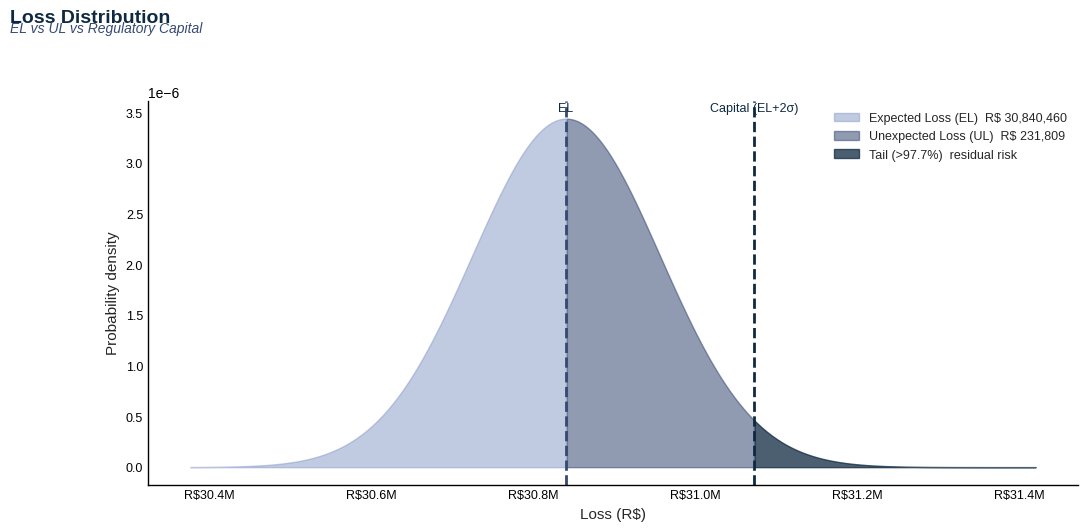

In [57]:
# EL vs UL Visualization

fig, ax = plt.subplots(figsize=(12, 5.4))
add_fig_title_block(fig, 'Loss Distribution', 'EL vs UL vs Regulatory Capital')

x = np.linspace(expected_loss - 4 * sigma_perdas, expected_loss + 5 * sigma_perdas, 1000)
y = stats.norm.pdf(x, loc=expected_loss, scale=sigma_perdas)

ax.fill_between(x, y, where=(x <= expected_loss),
                color=PALETTE["blue_light"], alpha=0.55,
                label=f'Expected Loss (EL)  R$ {expected_loss:,.0f}')
ax.fill_between(x, y, where=((x > expected_loss) & (x <= capital_regulatorio)),
                color=PALETTE["navy_mid"], alpha=0.55,
                label=f'Unexpected Loss (UL)  R$ {ul:,.0f}')
ax.fill_between(x, y, where=(x > capital_regulatorio),
                color=PALETTE["navy_dark"], alpha=0.75,
                label='Tail (>97.7%)  residual risk')

ax.axvline(expected_loss,       color=PALETTE["navy_mid"],  linewidth=2, linestyle='--')
ax.axvline(capital_regulatorio, color=PALETTE["navy_dark"], linewidth=2, linestyle='--')

ax.text(expected_loss,       max(y) * 1.02, 'EL', color=PALETTE["navy_dark"], fontsize=9, ha='center')
ax.text(capital_regulatorio, max(y) * 1.02, 'Capital (EL+2\u03c3)', color=PALETTE["navy_dark"], fontsize=9, ha='center')

ax.set_xlabel('Loss (R$)', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.legend(fontsize=9, frameon=False)
style_axes(ax)

plt.subplots_adjust(top=0.82)
plt.show()

In [58]:
# Construimos a distribuição de Poisson de defaults e acumulamo-as
# probabilidades para derivar o Credit VaR com 99% e 99.9% de confiança.

# Número máximo de defaults a simular

k_max = max(int(lambda_carteira * 3), int(lambda_carteira + 10 * np.sqrt(lambda_carteira)))

# Distribuição de probabilidades P(N=k)

k_vals    = np.arange(max(0, int(lambda_carteira - 5 * np.sqrt(lambda_carteira))),
                      int(lambda_carteira + 5 * np.sqrt(lambda_carteira)) + 1)
probs     = poisson.pmf(k_vals, mu=lambda_carteira)
probs_acum = np.cumsum(probs)

# Normalizamos para garantir soma = 1 (correção de truncamento)

probs     = probs     / probs.sum()
probs_acum = np.cumsum(probs)

perdas_k = k_vals * el_m

# Credit VaR 99% e 99.9%

def credit_var(nivel, k_vals, probs_acum, el_medio):
    idx = np.argmax(probs_acum >= nivel)
    return k_vals[idx] * el_medio, k_vals[idx], probs_acum[idx]

cvar_99,  k_99,  p_99  = credit_var(0.99,  k_vals, probs_acum, el_m)
cvar_999, k_999, p_999 = credit_var(0.999, k_vals, probs_acum, el_m)

ul_99  = cvar_99  - expected_loss
ul_999 = cvar_999 - expected_loss

# Tabela resumindo o CreditRisk+

print("═" * 64)
print("  CREDIT VaR — Aproximação simplificada inspirada no CreditRisk+ (Distribuição de Poisson)")
print("═" * 64)
print(f"\n  λ (defaults esperados por período)   : {lambda_carteira:,.2f} contratos")
print(f"  Perda média por default (ELm)        : R$ {el_m:,.2f}")
print(f"  EL Total                             : R$ {expected_loss:,.2f}")
print("─" * 64)
print(f"  Credit VaR 99.0%  → {k_99:>8,} defaults  : R$ {cvar_99:>14,.2f}")
print(f"    UL (99.0%)                         : R$ {ul_99:>14,.2f}")
print(f"    Prob. acumulada efetiva             : {p_99:.4%}")
print("─" * 64)
print(f"  Credit VaR 99.9%  → {k_999:>8,} defaults  : R$ {cvar_999:>14,.2f}")
print(f"    UL (99.9%)                         : R$ {ul_999:>14,.2f}")
print(f"    Prob. acumulada efetiva             : {p_999:.4%}")
print("═" * 64)

# Tabela dos buckets em torno do centro da distribuição

centro = np.argmax(probs)
inicio = max(0, centro - 5)
fim    = min(len(k_vals), centro + 6)

print(f"\n{'N defaults':>12} {'P(N=k)':>10} {'P(N≤k)':>10} {'Perda (R$)':>16}")
print("─" * 54)
for k, p, pa, perda in zip(k_vals[inicio:fim],
                            probs[inicio:fim],
                            probs_acum[inicio:fim],
                            perdas_k[inicio:fim]):
    flag = ' ← VaR 99%' if k == k_99 else (' ← VaR 99.9%' if k == k_999 else '')
    print(f"{k:>12,} {p:>10.4%} {pa:>10.4%} {perda:>16,.2f}{flag}")

# Adicional osbre o modelo

print("=" * 64)
print(f"  ⚠️  Com λ={lambda_carteira:,.0f}, o modelo Poisson subestima o risco")
print(f"      de cauda sistêmico (correlação entre defaults não capturada).")
print(f"      Para stress testing, considere UL = 20-30% da EL como proxy.")
print(f"      UL stress (30% da EL): R$ {expected_loss * 0.30:,.2f}")
print("=" * 64)

════════════════════════════════════════════════════════════════
  CREDIT VaR — Aproximação simplificada inspirada no CreditRisk+ (Distribuição de Poisson)
════════════════════════════════════════════════════════════════

  λ (defaults esperados por período)   : 70,801.41 contratos
  Perda média por default (ELm)        : R$ 435.59
  EL Total                             : R$ 30,840,460.15
────────────────────────────────────────────────────────────────
  Credit VaR 99.0%  →   71,421 defaults  : R$  31,110,346.12
    UL (99.0%)                         : R$     269,885.97
    Prob. acumulada efetiva             : 99.0035%
────────────────────────────────────────────────────────────────
  Credit VaR 99.9%  →   71,625 defaults  : R$  31,199,206.68
    UL (99.9%)                         : R$     358,746.53
    Prob. acumulada efetiva             : 99.9005%
════════════════════════════════════════════════════════════════

  N defaults     P(N=k)     P(N≤k)       Perda (R$)
──────────────────

In [59]:
# Análise de Risco por Segmento mostra como NPL e EL variam por faixa de juros e prazo

df_seg = dados.drop_duplicates('id_contrato').copy()

df_seg['faixa_juros'] = pd.qcut(
    df_seg['juros'].rank(method='first'),
    q=4,
    labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)']
)
df_seg['em_default'] = df_seg['id_contrato'].isin(
    dados[dados['flag_atraso'] == '90+ DPD']['id_contrato'].unique()
)

seg = df_seg.groupby('faixa_juros', observed=True).agg(
    contratos   = ('id_contrato', 'count'),
    taxa_juros  = ('juros', 'mean'),
    default_pct = ('em_default', 'mean'),
    ticket_medio= ('valor_financiado', 'mean'),
).reset_index()

seg['el_segmento'] = seg['default_pct'] * lgd_empirica * seg['ticket_medio']

print("─" * 60)
print("  RISCO POR SEGMENTO DE TAXA")
print("─" * 60)
display(
    seg.style
    .format({
        'taxa_juros'  : '{:.1%}',
        'default_pct' : '{:.1%}',
        'ticket_medio': 'R$ {:,.0f}',
        'el_segmento' : 'R$ {:,.0f}',
        'contratos'   : '{:,}',
    })
    .background_gradient(subset=['default_pct'], cmap='YlOrRd')
    .hide(axis='index')
    .set_caption("NPL e EL por quartil de taxa — visão segmentada de risco")
)


────────────────────────────────────────────────────────────
  RISCO POR SEGMENTO DE TAXA
────────────────────────────────────────────────────────────


faixa_juros,contratos,taxa_juros,default_pct,ticket_medio,el_segmento
Q1 (menor),"258,233",8.1%,12.3%,R$ 297,R$ 22
Q2,"258,233",9.0%,14.4%,R$ 330,R$ 29
Q3,"258,233",10.9%,13.9%,R$ 236,R$ 20
Q4 (maior),"258,233",13.1%,15.0%,R$ 173,R$ 16


In [60]:
# Reaproveitamos roll_matrix mas agora calculamos o valor esperado do ativo
# Construimos a matriz de transição entre buckets de DPD (estilo CreditMetrics)
# e calcula o valor esperado de cada contrato sob cada cenário de migração.

ordem_buckets = ['Current', '1-30', '31-60', '61-90', '90+']

# Spreads sobre taxa livre de risco por bucket (análogo ao CreditMetrics)

TAXA_LIVRE_RISCO  = 0.10
TAXA_MENSAL_BASE  = (1 + TAXA_LIVRE_RISCO) ** (1/12) - 1

spreads = {
    'Current': 0.000,
    '1-30'   : 0.030,
    '31-60'  : 0.080,
    '61-90'  : 0.150,
    '90+'    : lgd_empirica,
}

taxas_anuais = {b: TAXA_LIVRE_RISCO + spreads[b] for b in ordem_buckets}
taxas_mensais = {b: (1 + taxas_anuais[b]) ** (1/12) - 1 for b in ordem_buckets}

ticket_medio     = dados.drop_duplicates('id_contrato')['valor_financiado'].mean()
prazo_medio_mes  = int(dados.drop_duplicates('id_contrato')['prazo'].median())
meses_restantes = max(int(prazo_medio_mes), 2)

valor_por_estado = {}

taxa_contratual_m = (dados.drop_duplicates('id_contrato')['juros'] *
                     dados.drop_duplicates('id_contrato')['valor_financiado']).sum() / \
                     dados.drop_duplicates('id_contrato')['valor_financiado'].sum()

def vp_creditmetrics(saldo, taxa_contratual_m, taxa_desconto_m, n):
    """PMT fixo (taxa contratual) descontado à taxa do estado de risco."""
    if n <= 0 or saldo <= 0:
        return saldo
    pmt = saldo * taxa_contratual_m / (1 - (1 + taxa_contratual_m) ** (-n))
    if taxa_desconto_m <= 0:
        return pmt * n
    return pmt * (1 - (1 + taxa_desconto_m) ** (-n)) / taxa_desconto_m

# Uso no loop de estados:

for b in ordem_buckets:
    if b == '90+':
        valor_por_estado[b] = ticket_medio * (1 - lgd_empirica)
    else:
        valor_por_estado[b] = vp_creditmetrics(
            ticket_medio, taxa_contratual_m, taxas_mensais[b], meses_restantes
        )

# Mapeia nomes alternativos que possam existir na roll_matrix

MAPA_BUCKETS = {
    'em dia'    : 'Current',
    'current'   : 'Current',
    'Current'   : 'Current',
    '1-30 DPD'  : '1-30',
    '1-30'      : '1-30',
    '31-60 DPD' : '31-60',
    '31-60'     : '31-60',
    '61-90 DPD' : '61-90',
    '61-90'     : '61-90',
    '90+ DPD'   : '90+',
    '90+'       : '90+',
}

try:
    rm_renomeado = roll_matrix.copy()
    rm_renomeado.index   = [MAPA_BUCKETS.get(i, i) for i in rm_renomeado.index]
    rm_renomeado.columns = [MAPA_BUCKETS.get(c, c) for c in rm_renomeado.columns]
    M = (rm_renomeado
         .reindex(index=ordem_buckets, columns=ordem_buckets)
         .fillna(0)
         .values)

    # Verifica se a matriz está preenchida (diagonal deve ter valores > 0)

    if M.diagonal().sum() == 0:
        raise ValueError("Matriz zerada após reindex — usando identidade")

    print("✅  roll_matrix reindexada com sucesso")

except Exception as e:
    print(f"⚠️  {e} — usando matriz identidade como fallback")
    M = np.eye(len(ordem_buckets))

# Normaliza cada linha para somar 1 (garante matrix estocástica)

row_sums = M.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
M = M / row_sums

# Valor esperado pós-transição

valor_array = np.array([valor_por_estado[b] for b in ordem_buckets])
valor_esperado_pos_transicao = M @ valor_array
ganho_perda = valor_esperado_pos_transicao - ticket_medio

# Distribuição atual da carteira pelos buckets

dist_atual = dados.groupby('flag_atraso')['id_contrato'].nunique()
mapa_flag  = {
    'em dia'    : 'Current',
    '1-30 DPD'  : '1-30',
    '31-60 DPD' : '31-60',
    '61-90 DPD' : '61-90',
    '90+ DPD'   : '90+',
}

pesos_atuais = {}
total_contratos = dist_atual.sum()
for flag_label, bucket in mapa_flag.items():
    pesos_atuais[bucket] = dist_atual.get(flag_label, 0) / total_contratos

# EL via CreditMetrics: perda esperada ponderada pela distribuição atual

el_creditmetrics = sum(
    pesos_atuais.get(b, 0) * max(-ganho_perda[i], 0) * n_contratos_total
    for i, b in enumerate(ordem_buckets)
)

print("═" * 70)
print("  MATRIZ DE TRANSIÇÃO — CREDITMETRICS (valor esperado por estado)")
print("═" * 70)
print(f"\n  Ticket médio da carteira     : R$ {ticket_medio:,.2f}")
print(f"  Meses restantes (proxy 50%)  : {meses_restantes}")
print(f"  Taxa livre de risco          : {TAXA_LIVRE_RISCO:.0%} a.a.\n")

print(f"  {'Estado':<10} {'VP (R$)':>12} {'Taxa a.a.':>10} {'Spread':>8}")
print("─" * 45)
for b in ordem_buckets:
    print(f"  {b:<10} {valor_por_estado[b]:>12,.2f} "
          f"{taxas_anuais[b]:>10.2%} {spreads[b]:>8.2%}")

print(f"\n  {'Estado':<10} {'VE pós (R$)':>14} {'G/P (R$)':>14} {'G/P %':>8}")
print("─" * 50)
for i, b in enumerate(ordem_buckets):
    gp_pct = ganho_perda[i] / ticket_medio if ticket_medio > 0 else 0
    print(f"  {b:<10} {valor_esperado_pos_transicao[i]:>14,.2f} "
          f"{ganho_perda[i]:>+14,.2f} {gp_pct:>+8.2%}")

print(f"\n  EL via CreditMetrics         : R$ {el_creditmetrics:,.2f}")
print(f"  EL via PD × LGD × EAD       : R$ {expected_loss:,.2f}")
razao = el_creditmetrics / expected_loss if expected_loss > 0 else 0
print(f"  Razão (convergência)         : {razao:.2f}x  "
      f"{'✅ convergente' if 0.5 <= razao <= 2.0 else '⚠️ divergente — verificar matriz'}")
print("═" * 70)

✅  roll_matrix reindexada com sucesso
══════════════════════════════════════════════════════════════════════
  MATRIZ DE TRANSIÇÃO — CREDITMETRICS (valor esperado por estado)
══════════════════════════════════════════════════════════════════════

  Ticket médio da carteira     : R$ 258.99
  Meses restantes (proxy 50%)  : 4
  Taxa livre de risco          : 10% a.a.

  Estado          VP (R$)  Taxa a.a.   Spread
─────────────────────────────────────────────
  Current          319.59     10.00%    0.00%
  1-30             317.81     13.00%    3.00%
  31-60            314.98     18.00%    8.00%
  61-90            311.25     25.00%   15.00%
  90+              102.04     70.60%   60.60%

  Estado        VE pós (R$)       G/P (R$)    G/P %
──────────────────────────────────────────────────
  Current            313.26         +54.26  +20.95%
  1-30               304.79         +45.79  +17.68%
  31-60              297.34         +38.34  +14.80%
  61-90              281.57         +22.57   +8.72

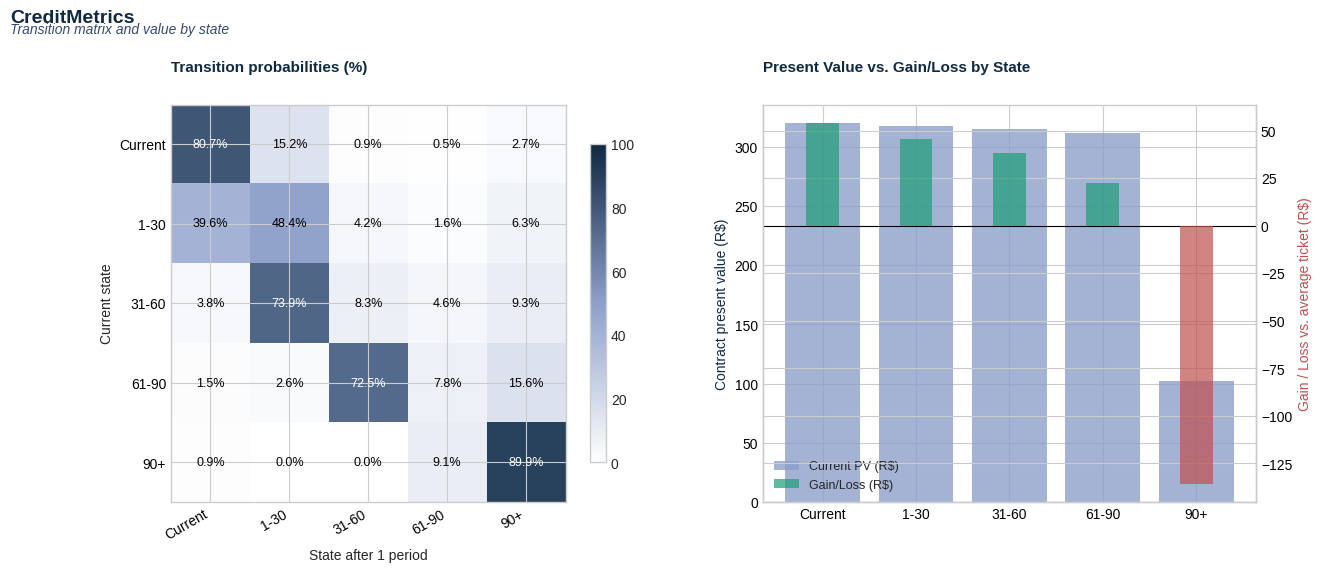

In [61]:
# Transition Matrix Heatmap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6))
add_fig_title_block(fig, 'CreditMetrics', 'Transition matrix and value by state')

im = ax1.imshow(M * 100, cmap=HOUSE_CMAP, aspect='auto', vmin=0, vmax=100)
ax1.set_xticks(range(len(ordem_buckets)))
ax1.set_yticks(range(len(ordem_buckets)))
ax1.set_xticklabels(ordem_buckets, rotation=30, ha='right')
ax1.set_yticklabels(ordem_buckets)
ax1.set_xlabel('State after 1 period', fontsize=10)
ax1.set_ylabel('Current state', fontsize=10)
add_title_block(ax1, 'Transition probabilities (%)', fontsize_title=11, pad=24)
ax1.tick_params(axis='both', colors=PALETTE["axis_black"])

for i in range(len(ordem_buckets)):
    for j in range(len(ordem_buckets)):
        val = M[i, j] * 100
        cor = 'white' if val > 60 else PALETTE["axis_black"]
        ax1.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9, color=cor)
plt.colorbar(im, ax=ax1, shrink=0.8)

cores_ve = [PALETTE["good_green"] if g >= 0 else PALETTE["alert_red"] for g in ganho_perda]
ax2.bar(ordem_buckets, [valor_por_estado[b] for b in ordem_buckets],
        color=PALETTE["blue_light"], alpha=0.8, label='Current PV (R$)', zorder=2)
ax2_twin = ax2.twinx()
ax2_twin.bar(ordem_buckets, ganho_perda, color=cores_ve, alpha=0.7, width=0.35,
             label='Gain/Loss (R$)', zorder=3)
ax2_twin.axhline(0, color=PALETTE["axis_black"], linewidth=0.8)

ax2.set_ylabel('Contract present value (R$)', fontsize=10, color=PALETTE["navy_dark"])
ax2_twin.set_ylabel('Gain / Loss vs. average ticket (R$)', fontsize=10, color=PALETTE["alert_red"])
add_title_block(ax2, 'Present Value vs. Gain/Loss by State', fontsize_title=11, pad=24)
ax2.spines[['top']].set_visible(False)
ax2.tick_params(axis='both', colors=PALETTE["axis_black"])
ax2_twin.tick_params(axis='both', colors=PALETTE["axis_black"])

l1, lb1 = ax2.get_legend_handles_labels()
l2, lb2 = ax2_twin.get_legend_handles_labels()
ax2.legend(l1 + l2, lb1 + lb2, fontsize=9, loc='lower left', frameon=False)

plt.subplots_adjust(top=0.82)
plt.show()


## Etapa 8 — Scorecard de síntese

════════════════════════════════════════════════════════════════════════
  FINAL SCORECARD: 65.3 / 100 [veto: ]
   MEDIUM QUALITY PORTFOLIO
────────────────────────────────────────────────────────────────────────
  Indicator                 Value    Bench         vs. Market   Pts  Weight
────────────────────────────────────────────────────────────────────────
  NPL 90+ DPD                9.2%     8.0%  ▼ 1.2% vs. market    72  25%
  IAG Global                13.7%    14.0%  ▲ 0.3% vs. market    71  20%
  FPD Rate                   9.1%     7.0%  ▼ 2.1% vs. market    64  15%
  Recovery Rate             39.4%    45.0%  ▼ 5.6% vs. market    54  15%
  EL / EAD                  11.5%     9.0%  ▼ 2.5% vs. market    56  15%
  Cure Rate                 15.0%    12.0%  ▲ 3.0% vs. market    70  10%
════════════════════════════════════════════════════════════════════════


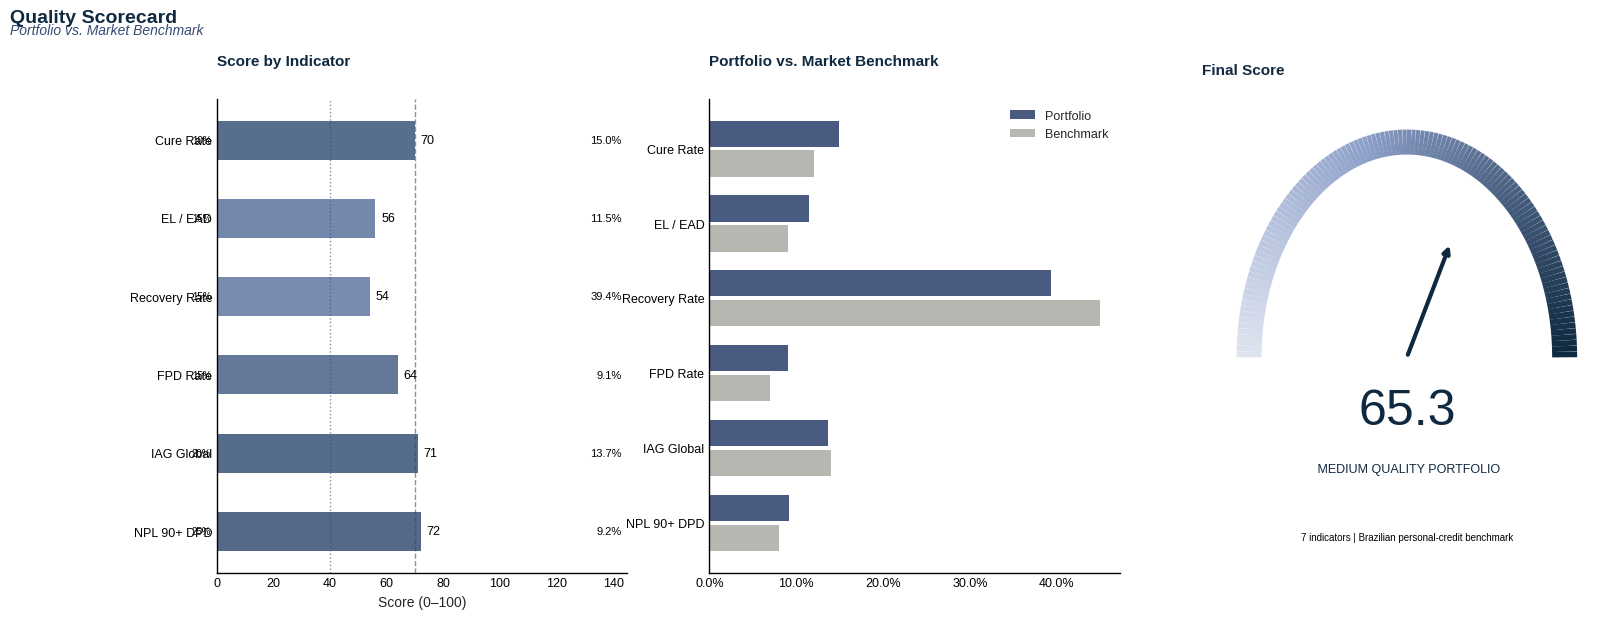

In [62]:
# Consolidate all indicators calculated in previous stages
# into a single 0-100 score with a quality verdict.

# Already-calculated indicators
# NPL 90+: % of installments in severe default
npl_rate    = (dados['flag_atraso'] == '90+ DPD').mean()

# FPD Rate: % of contracts that defaulted on the 1st installment
fpd_rate    = dados.groupby('id_contrato')['fpd_flag'].first().mean()

# Average Recovery Rate on defaulted contracts
recovery    = dados['recovery_rate'].dropna().mean() \
              if 'recovery_rate' in dados.columns else 0

# EL as % of EAD (already calculated)
el_sobre_ead = el_pct_ead

# Annual net margin (already calculated)
margem = locals().get('spread_liquida_anual', locals().get('margem_liquida_anual', 0))

# Collateral Monitoring Index
iag = iag_global

# Cure Rate - extracted from roll_matrix
try:
    cure_medio = roll_matrix.loc[
        roll_matrix.index.isin(['1-30 DPD', '31-60 DPD', '61-90 DPD']),
        'em dia'
    ].mean()
except Exception:
    cure_medio = 0.0

# Source: BACEN Credit Note, non-payroll personal-credit segment
# and personal-credit FIDC benchmarks (2023-2024)

BENCHMARKS = {
    'NPL 90+ DPD'  : {'mercado': 0.08},
    'IAG Global'   : {'mercado': 0.14},
    'FPD Rate'     : {'mercado': 0.07},
    'Recovery Rate': {'mercado': 0.45},
    'EL / EAD'     : {'mercado': 0.09},
    'Cure Rate'     : {'mercado': 0.12},
}

# Scoring functions (0 to 100, higher is better) - logic unchanged
def score_npl(v):
    if v <= 0.05: return 100
    elif v >= 0.20: return 0
    else: return round(100 * (0.20 - v) / 0.15)

def score_iag(v):
    if v <= 0.08: return 100
    elif v >= 0.28: return 0
    else: return round(100 * (0.28 - v) / 0.20)

def score_fpd(v):
    if v <= 0.04: return 100
    elif v >= 0.18: return 0
    else: return round(100 * (0.18 - v) / 0.14)

def score_recovery(v):
    if v >= 0.60: return 100
    elif v <= 0.15: return 0
    else: return round(100 * (v - 0.15) / 0.45)

def score_el(v):
    if v <= 0.05: return 100
    elif v >= 0.20: return 0
    else: return round(100 * (0.20 - v) / 0.15)

def score_cure(v):
    if v >= 0.20: return 100
    elif v <= 0.03: return 0
    else: return round(100 * (v - 0.03) / 0.17)

def vs_benchmark(valor, bench, maior_melhor=False):
    diff = (valor - bench) if maior_melhor else (bench - valor)
    sim  = '\u25b2' if diff > 0 else '\u25bc'
    return f"{sim} {abs(diff):.1%} vs. market"

# Weighted calculation
# Weighting logic:
#   NPL and IAG capture delinquency (stock and flow) -> higher combined weight
#   FPD and Recovery capture origination quality and recovery -> medium weight
#   EL/EAD and Cure Rate complement with projected loss and cure capacity

indicadores = {
    'NPL 90+ DPD'  : {'valor': npl_rate,     'score': score_npl(npl_rate),
                      'peso': 0.25, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['NPL 90+ DPD']['mercado'],
                      'maior_melhor': False},

    'IAG Global'   : {'valor': iag,           'score': score_iag(iag),
                      'peso': 0.20, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['IAG Global']['mercado'],
                      'maior_melhor': False},

    'FPD Rate'     : {'valor': fpd_rate,      'score': score_fpd(fpd_rate),
                      'peso': 0.15, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['FPD Rate']['mercado'],
                      'maior_melhor': False},

    'Recovery Rate': {'valor': recovery,      'score': score_recovery(recovery),
                      'peso': 0.15, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['Recovery Rate']['mercado'],
                      'maior_melhor': True},

    'EL / EAD'     : {'valor': el_sobre_ead,  'score': score_el(el_sobre_ead),
                      'peso': 0.15, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['EL / EAD']['mercado'],
                      'maior_melhor': False},

    'Cure Rate'    : {'valor': cure_medio,    'score': score_cure(cure_medio),
                      'peso': 0.10, 'fmt': '{:.1%}',
                      'benchmark': BENCHMARKS['Cure Rate']['mercado'],
                      'maior_melhor': True},
}

# Weight check
assert abs(sum(v['peso'] for v in indicadores.values()) - 1.0) < 0.001

nota_ponderada = sum(v['score'] * v['peso'] for v in indicadores.values())

# Veto rule: critical indicators cap the verdict
veto_ativo   = npl_rate > 0.20 or fpd_rate > 0.15
nota_final   = min(nota_ponderada, 39.9) if veto_ativo else nota_ponderada
motivos_veto = []
if npl_rate > 0.20: motivos_veto.append(f"NPL {npl_rate:.1%} > 20%")
if fpd_rate > 0.15: motivos_veto.append(f"FPD {fpd_rate:.1%} > 15%")
nota_veto_msg = f" [veto: {', '.join(motivos_veto)}]"

def veredito(nota):
    if nota >= 80:   return ' HIGH QUALITY PORTFOLIO'
    elif nota >= 60: return ' MEDIUM QUALITY PORTFOLIO'
    elif nota >= 40: return ' ELEVATED RISK PORTFOLIO'
    else:            return ' CRITICAL PORTFOLIO'

texto_veredito = veredito(nota_final)

# Console output
print("\u2550" * 72)
print(f"  FINAL SCORECARD: {nota_final:.1f} / 100{nota_veto_msg}")
print(f"  {texto_veredito}")
print("\u2500" * 72)
print(f"  {'Indicator':<22} {'Value':>8} {'Bench':>8} {'vs. Market':>18} "
      f"{'Pts':>5}  {'Weight':>6}")
print("\u2500" * 72)
for nome, v in indicadores.items():
    comp = vs_benchmark(v['valor'], v['benchmark'], v['maior_melhor'])
    print(f"  {nome:<22} {v['fmt'].format(v['valor']):>8} "
          f"{v['fmt'].format(v['benchmark']):>8} {comp:>18} "
          f"{v['score']:>5}  {v['peso']:.0%}")
print("\u2550" * 72)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6.4))
add_fig_title_block(fig, 'Quality Scorecard', 'Portfolio vs. Market Benchmark')

# Panel 1: horizontal bars, colored by score on the house navy gradient (dark = strong, light = weak)
ax1 = axes[0]
nomes   = list(indicadores.keys())
scores  = [indicadores[n]['score'] for n in nomes]
pesos   = [indicadores[n]['peso']  for n in nomes]
valores = [indicadores[n]['fmt'].format(indicadores[n]['valor']) for n in nomes]
benches = [indicadores[n]['fmt'].format(indicadores[n]['benchmark']) for n in nomes]
cores   = [HOUSE_CMAP(0.15 + 0.85 * (s / 100)) for s in scores]

bars = ax1.barh(nomes, scores, color=cores, alpha=0.95, height=0.5)
ax1.set_xlim(0, 145)
ax1.axvline(70, color=PALETTE["navy_mid"], lw=1, ls='--', alpha=0.6)
ax1.axvline(40, color=PALETTE["navy_mid"], lw=1, ls=':',  alpha=0.6)

for i, (bar, score, valor, bench, peso) in enumerate(zip(bars, scores, valores, benches, pesos)):
    ax1.text(score + 2, i, f'{score}', va='center', fontsize=9, fontweight='500', color=PALETTE["axis_black"])
    ax1.text(143, i, f'{valor}', va='center', fontsize=8, color=PALETTE["axis_black"], ha='right')
    ax1.text(-2, i, f'{peso:.0%}', va='center', fontsize=7, color=PALETTE["axis_black"], ha='right')

ax1.set_xlabel('Score (0\u2013100)', fontsize=10)
add_title_block(ax1, 'Score by Indicator', fontsize_title=11, pad=24)
style_axes(ax1)

# Panel 2: portfolio vs. market benchmark (grouped bars)
ax2 = axes[1]
y     = np.arange(len(nomes))
vals  = [indicadores[n]['valor']     for n in nomes]
bench = [indicadores[n]['benchmark'] for n in nomes]

ax2.barh(y + 0.2, vals,  height=0.35, color=PALETTE["navy_mid"],   alpha=0.9, label='Portfolio')
ax2.barh(y - 0.2, bench, height=0.35, color=PALETTE["muted_grey"], alpha=0.6, label='Benchmark')
ax2.set_yticks(y)
ax2.set_yticklabels(nomes, fontsize=8)
add_title_block(ax2, 'Portfolio vs. Market Benchmark', fontsize_title=11, pad=24)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9, frameon=False)
style_axes(ax2)

# Panel 3: gauge, same navy gradient as Panel 1 (continuous arc instead of red/amber/green bands)
ax3 = axes[2]
n_seg = 120
theta = np.linspace(np.pi, 0, n_seg + 1)
for k in range(n_seg):
    frac = k / (n_seg - 1)
    ax3.plot(np.cos(theta[k:k+2]), np.sin(theta[k:k+2]),
              lw=18, color=HOUSE_CMAP(0.15 + 0.85 * frac), solid_capstyle='butt')

ang = np.pi * (1 - nota_final / 100)
ax3.annotate('', xy=(0.6*np.cos(ang), 0.6*np.sin(ang)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=PALETTE["navy_dark"], lw=3))
ax3.text(0, -0.25, f'{nota_final:.1f}', ha='center', va='center',
         fontsize=36, fontweight='500', color=PALETTE["navy_dark"])
ax3.text(0, -0.52, texto_veredito, ha='center', va='center', fontsize=9, fontweight='500', color=PALETTE["navy_dark"])
if veto_ativo:
    ax3.text(0, -0.70, f"Veto: {', '.join(motivos_veto)}", ha='center', fontsize=7,
             color=PALETTE["alert_red"], style='italic')
ax3.text(0, -0.85, '7 indicators | Brazilian personal-credit benchmark',
         ha='center', fontsize=7, color=PALETTE["axis_black"])
ax3.set_xlim(-1.3, 1.3)
ax3.set_ylim(-1.0, 1.2)
ax3.axis('off')
add_title_block(ax3, 'Final Score', fontsize_title=11, pad=18)

plt.subplots_adjust(top=0.85)
plt.show()


### gráficos adicionais


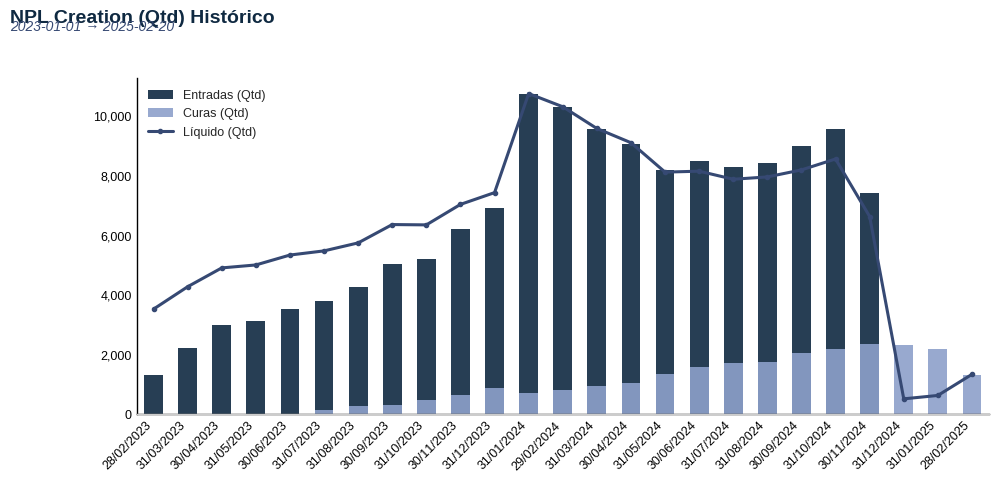

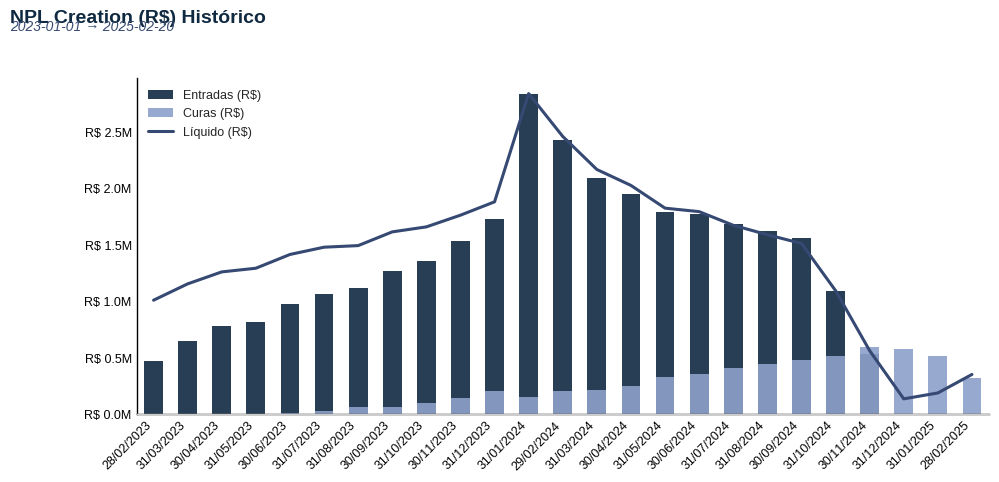

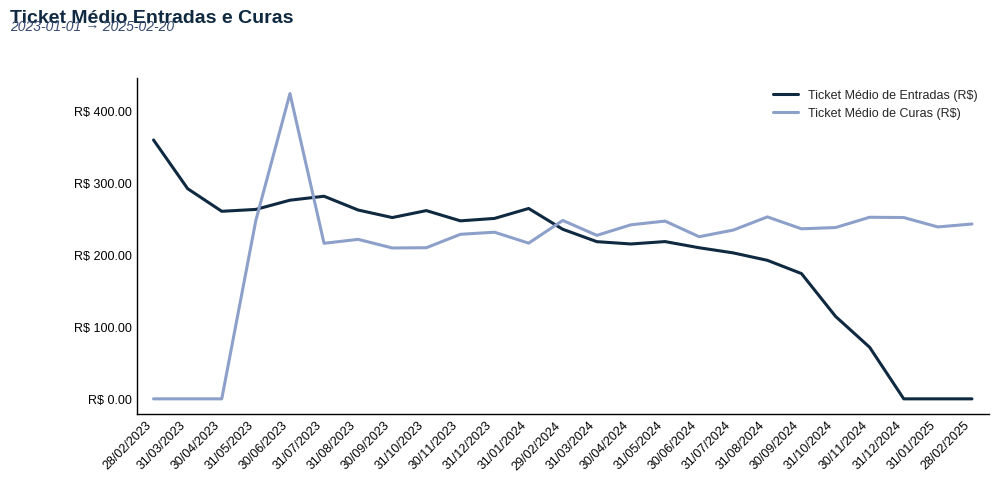

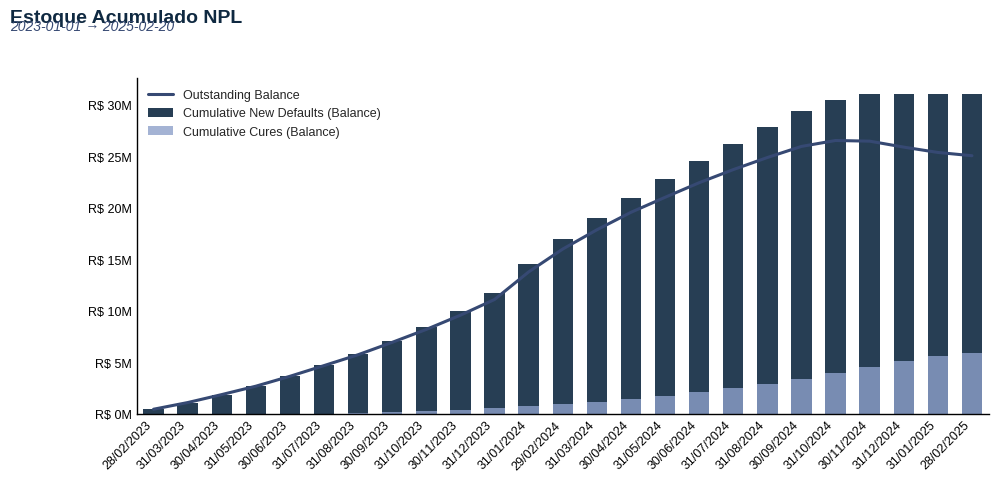

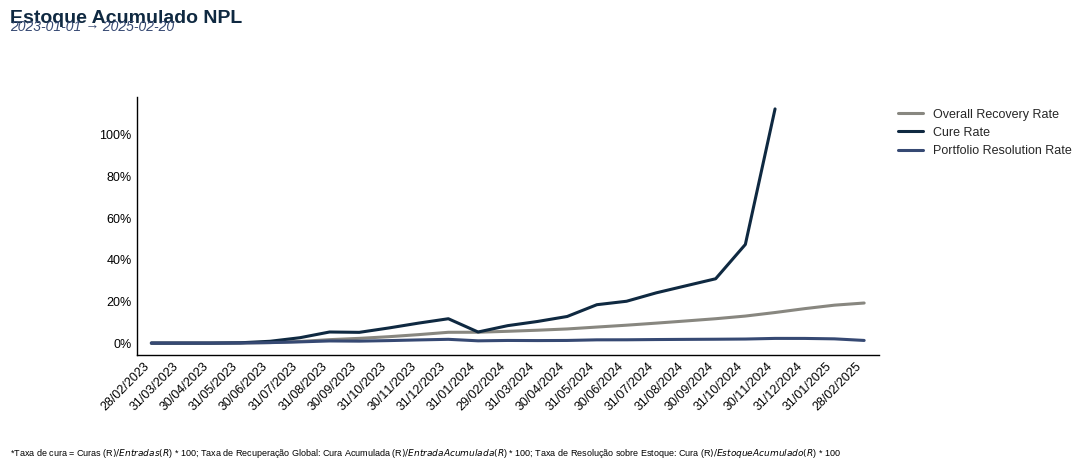

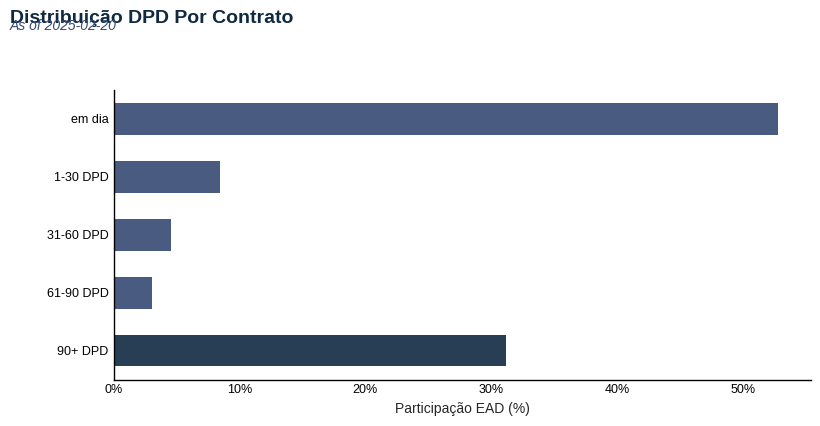

In [63]:
# ════════════════════════════════════════════════════════════════════
# P.6 — GRÁFICO 1: NPL Creation (Qtd) Histórico — CORRIGIDO
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 4.6))
add_fig_title_block(fig, 'NPL Creation (Qtd) Histórico',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

x     = range(len(npl_creation))
meses = pd.to_datetime(npl_creation.index).strftime('%d/%m/%Y')

ax.bar(x, npl_creation['novos_defaults'], label='Entradas (Qtd)',
       color=PALETTE["navy_dark"], alpha=0.9, width=0.55)
ax.bar(x, npl_creation['curas'], label='Curas (Qtd)',
       color=PALETTE["blue_light"], alpha=0.9, width=0.55)
ax2 = ax.twinx()
ax2.plot(x, npl_creation['npl_liquido_qtd'], label='Líquido (Qtd)',
         color=PALETTE["navy_mid"], linewidth=2.2, marker='o', markersize=3)
ax2.set_yticks([])
ax2.spines[['top','right','left']].set_visible(False)

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, frameon=False, loc='upper left')
style_axes(ax)

plt.subplots_adjust(top=0.84)
plt.show()


# ════════════════════════════════════════════════════════════════════
# P.6 — GRÁFICO 2: NPL Creation (R$) Histórico — CORRIGIDO
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 4.6))
add_fig_title_block(fig, 'NPL Creation (R$) Histórico',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

ax.bar(x, npl_creation['volume_defaults_rs'], label='Entradas (R$)',
       color=PALETTE["navy_dark"], alpha=0.9, width=0.55)
ax.bar(x, npl_creation['volume_curas_rs'], label='Curas (R$)',
       color=PALETTE["blue_light"], alpha=0.9, width=0.55)
ax2 = ax.twinx()
ax2.plot(x, npl_creation['npl_liquido_rs'], label='Líquido (R$)',
         color=PALETTE["navy_mid"], linewidth=2.2)
ax2.set_yticks([])
ax2.spines[['top','right','left']].set_visible(False)

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f}M'))
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, frameon=False, loc='upper left')
style_axes(ax)

plt.subplots_adjust(top=0.84)
plt.show()


# ════════════════════════════════════════════════════════════════════
# P.6 — GRÁFICO 3: Ticket Médio Entradas e Curas — CORRIGIDO
# ════════════════════════════════════════════════════════════════════
ticket_entrada = (npl_creation['volume_defaults_rs'] / npl_creation['novos_defaults']).fillna(0)
ticket_cura    = (npl_creation['volume_curas_rs']    / npl_creation['curas']).replace([np.inf, -np.inf], 0).fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.6))
add_fig_title_block(fig, 'Ticket Médio Entradas e Curas',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

ax.plot(x, ticket_entrada, label='Ticket Médio de Entradas (R$)',
        color=PALETTE["navy_dark"], linewidth=2.2)
ax.plot(x, ticket_cura, label='Ticket Médio de Curas (R$)',
        color=PALETTE["blue_light"], linewidth=2.2)

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.2f}'))
ax.legend(fontsize=9, frameon=False, loc='upper right')
style_axes(ax)

plt.subplots_adjust(top=0.84)
plt.show()


# ════════════════════════════════════════════════════════════════════
# P.7 — GRÁFICO 1: Estoque Acumulado NPL (R$ — barras + saldo) — CORRIGIDO
# ════════════════════════════════════════════════════════════════════
cum_curas    = npl_creation['volume_curas_rs'].cumsum()
cum_defaults = npl_creation['volume_defaults_rs'].cumsum()

fig, ax = plt.subplots(figsize=(11, 4.6))
add_fig_title_block(fig, 'Estoque Acumulado NPL',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

ax.bar(x, cum_defaults, label='Cumulative New Defaults (Balance)',
       color=PALETTE["navy_dark"], alpha=0.9, width=0.6)
ax.bar(x, cum_curas, label='Cumulative Cures (Balance)',
       color=PALETTE["blue_light"], alpha=0.8, width=0.6)
ax.plot(x, npl_creation['estoque_acumulado_rs'], label='Outstanding Balance',
        color=PALETTE["navy_mid"], linewidth=2.2)

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.0f}M'))
ax.legend(fontsize=9, frameon=False, loc='upper left')
style_axes(ax)

plt.subplots_adjust(top=0.84)
plt.show()


# ════════════════════════════════════════════════════════════════════
# P.7 — GRÁFICO 2: Estoque Acumulado NPL (% — taxas de recuperação) — CORRIGIDO
# ════════════════════════════════════════════════════════════════════
taxa_cura = (npl_creation['volume_curas_rs'] / npl_creation['volume_defaults_rs']
             .replace(0, np.nan)) * 100

taxa_recuperacao_global = (cum_curas / cum_defaults.replace(0, np.nan)) * 100

taxa_resolucao = (npl_creation['volume_curas_rs'] /
                   npl_creation['estoque_acumulado_rs'].replace(0, np.nan)) * 100

fig, ax = plt.subplots(figsize=(11, 4.6))
add_fig_title_block(fig, 'Estoque Acumulado NPL',
                     f'{DATA_INICIO.date()} \u2192 {DATA_REF.date()}')

ax.plot(x, taxa_recuperacao_global, label='Overall Recovery Rate',
        color=PALETTE["muted_grey"], linewidth=2.2)
ax.plot(x, taxa_cura, label='Cure Rate',
        color=PALETTE["navy_dark"], linewidth=2.2)
ax.plot(x, taxa_resolucao, label='Portfolio Resolution Rate',
        color=PALETTE["navy_mid"], linewidth=2.2)

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

# Legenda fora da área de plotagem, à direita — evita cruzar as linhas ascendentes
ax.legend(fontsize=9, frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
style_axes(ax)

fig.text(0.01, 0.02,
         '*Taxa de cura = Curas (R$) / Entradas (R$) * 100; Taxa de Recuperação Global: Cura Acumulada '
         '(R$) / Entrada Acumulada (R$) * 100; Taxa de Resolução sobre Estoque: Cura (R$) / Estoque '
         'Acumulado (R$) * 100', fontsize=6.5, color=PALETTE["axis_black"], ha='left')

plt.subplots_adjust(top=0.80, bottom=0.24, right=0.80)   # right=0.80 reserva espaço p/ legenda externa
plt.show()

# ════════════════════════════════════════════════════════════════════
# P.7 — GRÁFICO 3: Distribuição DPD Por Contrato
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.2))
add_fig_title_block(fig, 'Distribuição DPD Por Contrato', f'As of {DATA_REF.date()}')

ordem_plot = aging_contratos.iloc[::-1]   # 'em dia' embaixo, '90+ DPD' no topo
cores_bucket = [PALETTE["navy_dark"] if b == '90+ DPD' else PALETTE["navy_mid"]
                for b in ordem_plot['pior_bucket']]

ax.barh(ordem_plot['pior_bucket'], ordem_plot['part_ead_%'],
        color=cores_bucket, alpha=0.9, height=0.55)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Participação EAD (%)', fontsize=10)
style_axes(ax)

plt.subplots_adjust(top=0.80)
plt.show()